In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving predictive_maintenance_v3.csv to predictive_maintenance_v3.csv


In [ ]:
import io

filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("File:", filename)
print("Shape:", df.shape)

File: predictive_maintenance_v3.csv
Shape: (24042, 15)


In [ ]:
df.head()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [ ]:
df.tail()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
24037,2024-01-14 22:17:56,20,Robotic Arm,0.98,37.18,5.27,45.0,361.8,normal,163.43,10.2,0.5,0,none,0
24038,2024-01-14 22:41:56,20,Robotic Arm,0.45,33.90,2.21,18.9,159.5,idle,163.83,11.0,0.5,0,none,0
24039,2024-01-14 22:58:56,20,Robotic Arm,0.40,29.15,2.29,19.0,159.5,idle,164.12,16.2,0.5,0,none,0
24040,2024-01-14 23:23:56,20,Robotic Arm,0.45,31.47,2.45,18.0,151.4,idle,164.53,16.7,0.5,0,none,0
24041,2024-01-14 23:52:56,20,Robotic Arm,0.44,33.73,2.25,14.8,153.4,idle,165.02,9.2,0.5,0,none,0


In [ ]:
df.sample(10, random_state=42)

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
21245,2024-01-09 12:53:00,18,Robotic Arm,3.81,53.38,8.35,60.4,493.6,peak,411.61,12.1,0.50,0,none,0
13933,2024-01-09 14:32:09,12,Compressor,3.07,56.11,15.06,103.5,1666.5,normal,122.75,12.3,37.16,0,none,0
10261,2024-01-07 20:49:00,9,Pump,NaN,60.95,11.78,81.6,1220.5,normal,374.08,13.1,0.50,0,none,0
15414,2024-01-13 00:53:03,13,Compressor,2.33,63.16,14.11,107.7,1793.2,normal,51.85,16.9,21.78,0,none,0
14628,2024-01-03 12:52:00,13,Compressor,2.46,65.75,14.93,98.5,1805.8,normal,324.09,9.7,33.24,0,none,0
6562,2024-01-07 21:38:02,6,Pump,1.73,57.81,12.22,NaN,1322.9,normal,86.40,11.4,0.50,0,none,0
11480,2024-01-08 00:58:20,10,Pump,2.22,NaN,15.20,83.8,1256.2,normal,96.62,9.4,30.76,0,none,0
22280,2024-01-07 21:33:19,19,Robotic Arm,0.41,30.15,2.50,14.6,146.3,idle,87.68,14.4,6.37,0,none,0
12591,2024-01-06 21:30:00,11,Compressor,2.83,91.79,20.99,112.3,1445.1,normal,534.05,15.0,5.00,1,motor_overheat,5638
1201,2024-01-01 02:31:00,2,CNC,0.99,45.18,4.11,23.8,867.7,idle,367.03,9.0,77.95,0,none,0


In [ ]:
df.columns.tolist()

['timestamp',
 'machine_id',
 'machine_type',
 'vibration_rms',
 'temperature_motor',
 'current_phase_avg',
 'pressure_level',
 'rpm',
 'operating_mode',
 'hours_since_maintenance',
 'ambient_temp',
 'rul_hours',
 'failure_within_24h',
 'failure_type',
 'estimated_repair_cost']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                24042 non-null  object 
 1   machine_id               24042 non-null  int64  
 2   machine_type             24042 non-null  object 
 3   vibration_rms            23042 non-null  float64
 4   temperature_motor        23208 non-null  float64
 5   current_phase_avg        23311 non-null  float64
 6   pressure_level           23118 non-null  float64
 7   rpm                      23509 non-null  float64
 8   operating_mode           24042 non-null  object 
 9   hours_since_maintenance  24042 non-null  float64
 10  ambient_temp             24042 non-null  float64
 11  rul_hours                24042 non-null  float64
 12  failure_within_24h       24042 non-null  int64  
 13  failure_type             24042 non-null  object 
 14  estimated_repair_cost 

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,24042,21176,2024-01-01 00:00:00,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
machine_id,24042.0,NaN,NaN,NaN,10.505033,5.746455,1.0,6.0,10.0,15.0,20.0
machine_type,24042,4,Pump,6114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vibration_rms,23042.0,NaN,NaN,NaN,1.623667,1.081061,0.35,0.82,1.27,2.27,10.0
temperature_motor,23208.0,NaN,NaN,NaN,51.404295,12.519279,28.0,42.61,50.06,59.9625,95.0
current_phase_avg,23311.0,NaN,NaN,NaN,8.823829,5.366391,2.2,4.63,6.43,13.12,35.0
pressure_level,23118.0,NaN,NaN,NaN,59.012233,38.723271,10.1,22.7,46.3,94.7,206.5
rpm,23509.0,NaN,NaN,NaN,1144.849317,912.670971,124.1,489.4,856.0,1676.0,4098.8
operating_mode,24042,3,normal,11632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hours_since_maintenance,24042.0,NaN,NaN,NaN,172.630624,150.722469,0.0,42.87,121.61,295.575,575.63


In [ ]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing.sort_values("Missing_Percentage", ascending=False)

,Missing_Count,Missing_Percentage
vibration_rms,1000,4.159388
pressure_level,924,3.843274
temperature_motor,834,3.468929
current_phase_avg,731,3.040512
rpm,533,2.216954
timestamp,0,0.000000
machine_type,0,0.000000
machine_id,0,0.000000
operating_mode,0,0.000000
hours_since_maintenance,0,0.000000


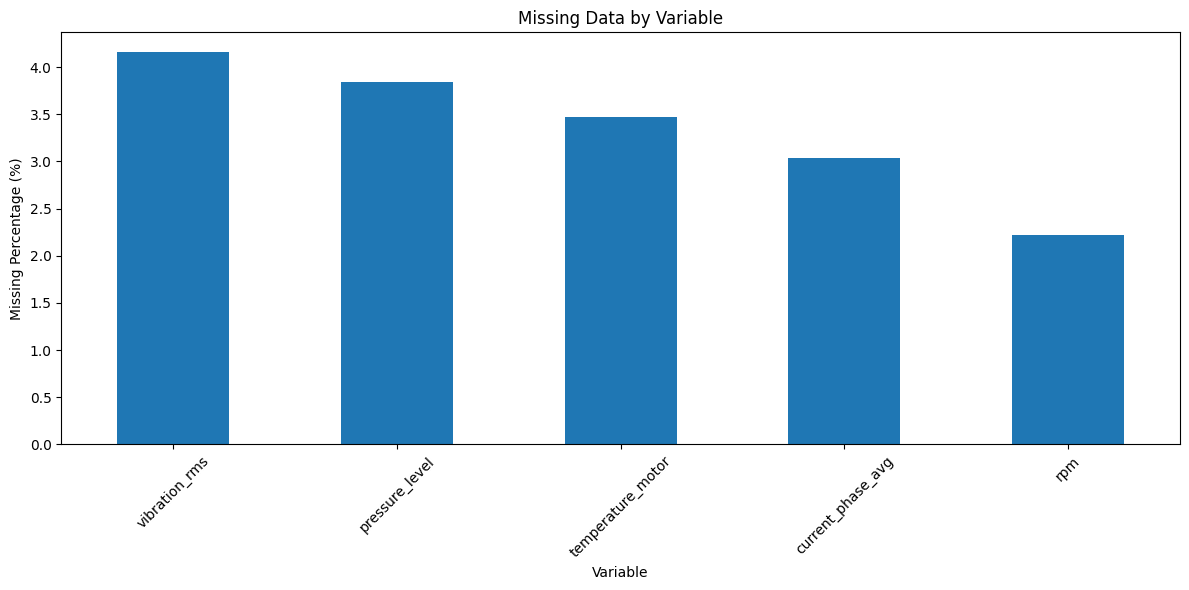

In [ ]:
plt.figure(figsize=(12, 6))

missing_pct = (
    df.isnull().mean()
    .sort_values(ascending=False) * 100
)

missing_pct = missing_pct[missing_pct > 0]

missing_pct.plot(kind="bar")

plt.title("Missing Data by Variable")
plt.ylabel("Missing Percentage (%)")
plt.xlabel("Variable")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", duplicate_count / len(df) * 100)

Duplicate rows: 0
Duplicate percentage: 0.0


In [ ]:
print("Number of unique machines:", df["machine_id"].nunique())

print("\nMachines:")
print(df["machine_id"].unique())

Number of unique machines: 20

Machines:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [ ]:
df["machine_type"].value_counts()

,count
machine_type,
Pump,6114
Robotic Arm,6003
Compressor,5988
CNC,5937


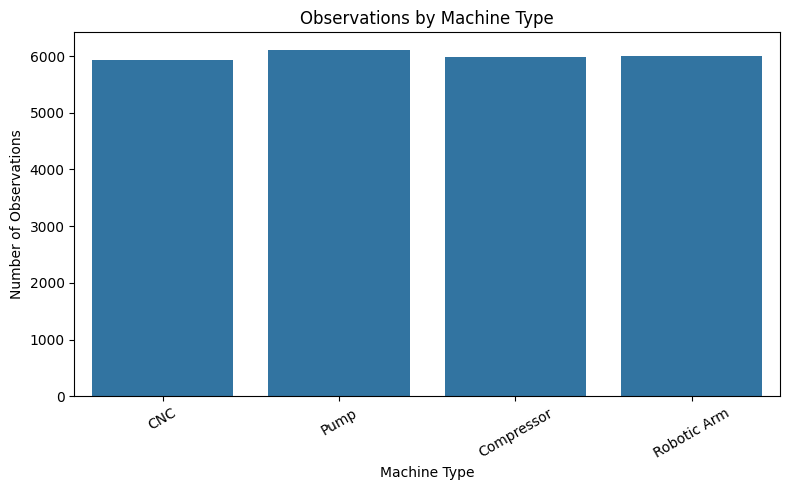

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="machine_type"
)

plt.title("Observations by Machine Type")
plt.xlabel("Machine Type")
plt.ylabel("Number of Observations")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

machine_counts = (
    df.groupby(["machine_id", "machine_type"])
      .size()
      .reset_index(name="observations")
)

machine_counts

In [ ]:
machine_counts = (
    df.groupby(["machine_id", "machine_type"])
      .size()
      .reset_index(name="observations")
)

machine_counts

,machine_id,machine_type,observations
0,1,CNC,1192
1,2,CNC,1146
2,3,CNC,1218
3,4,CNC,1141
4,5,CNC,1240
5,6,Pump,1298
6,7,Pump,1180
7,8,Pump,1213
8,9,Pump,1251
9,10,Pump,1172


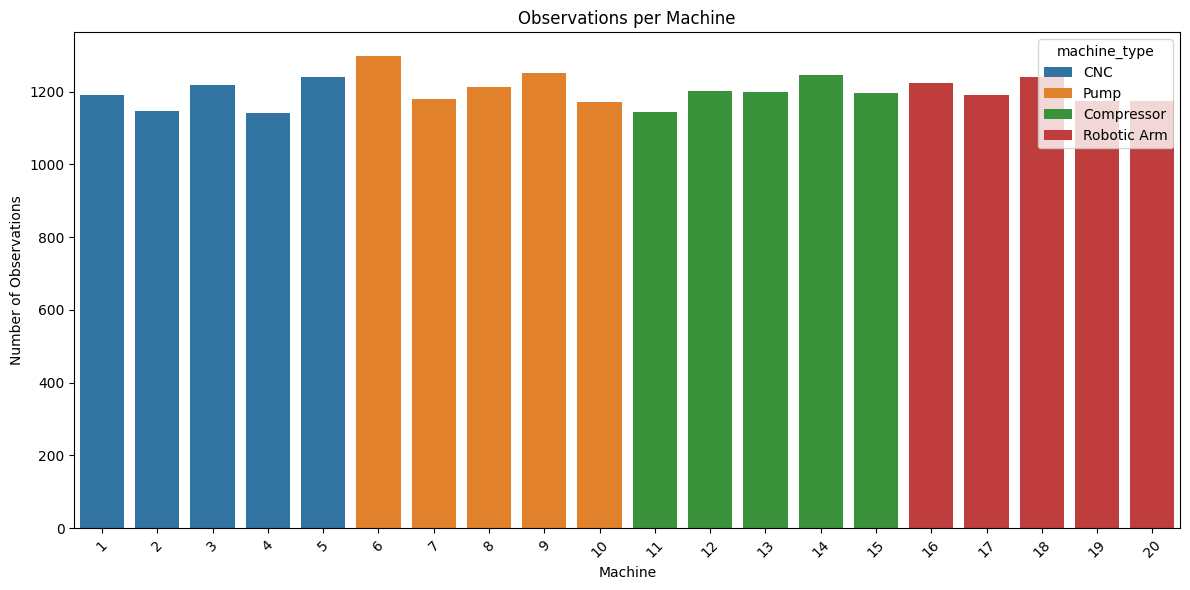

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=machine_counts,
    x="machine_id",
    y="observations",
    hue="machine_type"
)

plt.title("Observations per Machine")
plt.xlabel("Machine")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['timestamp', 'machine_id', 'machine_type', 'vibration_rms',
       'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm',
       'operating_mode', 'hours_since_maintenance', 'ambient_temp',
       'rul_hours', 'failure_within_24h', 'failure_type',
       'estimated_repair_cost'],
      dtype='object')

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

print(
    "Duration:",
    df["timestamp"].max() - df["timestamp"].min()
)

Start: 2024-01-01 00:00:00
End: 2024-01-14 23:59:38
Duration: 13 days 23:59:38


In [ ]:
df["timestamp"].describe()

,timestamp
count,24042
mean,2024-01-08 00:06:30.111721216
min,2024-01-01 00:00:00
25%,2024-01-04 12:24:13.750000128
50%,2024-01-08 00:11:30
75%,2024-01-11 13:24:32.500000
max,2024-01-14 23:59:38


In [ ]:
df = df.sort_values(
    ["machine_id", "timestamp"]
).reset_index(drop=True)

In [ ]:
df.head(20)

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0
5,2024-01-01 01:23:00,1,CNC,0.94,42.00,4.77,23.6,853.2,idle,275.18,16.1,59.62,0,none,0
6,2024-01-01 01:47:00,1,CNC,0.88,41.71,4.10,25.7,917.6,idle,275.58,10.8,59.22,0,none,0
7,2024-01-01 01:55:00,1,CNC,2.93,54.57,10.13,78.0,2932.1,normal,275.72,11.4,59.08,0,none,0
8,2024-01-01 01:59:00,1,CNC,0.74,44.95,4.05,25.5,868.1,idle,275.78,11.6,59.02,0,none,0
9,2024-01-01 02:12:00,1,CNC,0.90,43.12,4.78,23.3,862.9,idle,276.00,16.1,58.80,0,none,0


In [ ]:
time_check = (
    df.groupby("machine_id")["timestamp"]
      .diff()
      .describe()
)

time_check

,timestamp
count,24022
mean,0 days 00:16:46.576971109
std,0 days 00:23:17.544198282
min,0 days 00:02:00
25%,0 days 00:09:00
50%,0 days 00:16:00
75%,0 days 00:23:00
max,0 days 19:23:26


In [ ]:
df["failure_within_24h"].value_counts()

,count
failure_within_24h,
0,20482
1,3560


In [ ]:
failure_distribution = (
    df["failure_within_24h"]
    .value_counts(normalize=True)
    .mul(100)
)

failure_distribution

,proportion
failure_within_24h,
0,85.19258
1,14.80742


In [ ]:
failure_by_machine = (
    df.groupby(["machine_id", "machine_type"])
      ["failure_within_24h"]
      .agg(["sum", "count", "mean"])
      .reset_index()
)

failure_by_machine

,machine_id,machine_type,sum,count,mean
0,1,CNC,187,1192,0.156879
1,2,CNC,108,1146,0.094241
2,3,CNC,183,1218,0.150246
3,4,CNC,263,1141,0.230500
4,5,CNC,93,1240,0.075000
5,6,Pump,98,1298,0.075501
6,7,Pump,275,1180,0.233051
7,8,Pump,175,1213,0.144270
8,9,Pump,90,1251,0.071942
9,10,Pump,275,1172,0.234642


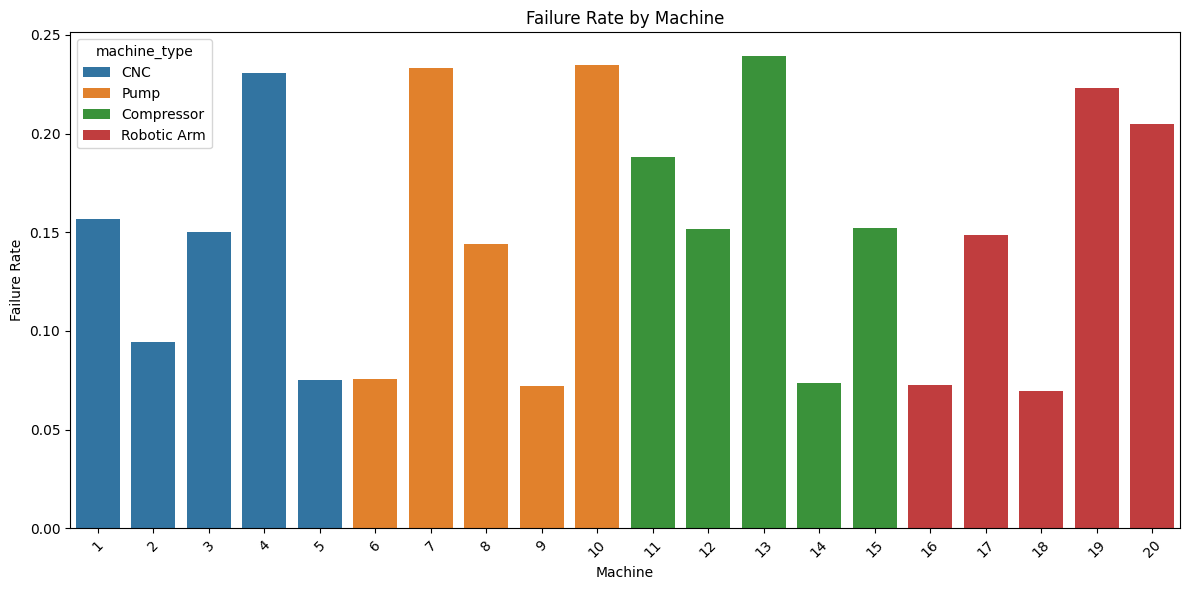

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=failure_by_machine,
    x="machine_id",
    y="mean",
    hue="machine_type"
)

plt.title("Failure Rate by Machine")
plt.xlabel("Machine")
plt.ylabel("Failure Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df["failure_start"] = (
    df.groupby("machine_id")["failure_within_24h"]
      .diff()
      .fillna(0)
      .eq(1)
)

In [ ]:
df["failure_start"] = (
    df.groupby("machine_id")["failure_within_24h"]
      .diff()
      .fillna(0)
      .eq(1)
)

In [ ]:
df["failure_episode"] = (
    df.groupby("machine_id")["failure_start"]
      .cumsum()
)

In [ ]:
failure_episodes = (
    df[df["failure_within_24h"] == 1]
    .groupby(["machine_id", "failure_episode"])
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        observations=("failure_within_24h", "size"),
        min_rul=("rul_hours", "min"),
        max_rul=("rul_hours", "max")
    )
    .reset_index()
)

In [ ]:
failure_episodes.head(20)

,machine_id,failure_episode,start_time,end_time,observations,min_rul,max_rul
0,1,1,2024-01-03 03:19:00,2024-01-04 03:03:00,85,0.5,23.74
1,1,2,2024-01-04 16:42:31,2024-01-05 16:28:31,102,0.5,23.94
2,2,1,2024-01-03 04:18:00,2024-01-05 04:39:26,108,0.5,23.75
3,3,1,2024-01-07 21:21:00,2024-01-08 21:07:00,91,0.5,23.87
4,3,2,2024-01-11 22:28:22,2024-01-12 22:23:22,92,0.5,23.96
5,4,1,2024-01-02 12:11:00,2024-01-03 11:45:00,88,0.5,23.68
6,4,2,2024-01-08 19:01:41,2024-01-09 18:41:41,93,0.5,23.99
7,4,3,2024-01-12 12:16:11,2024-01-13 12:10:11,82,0.5,23.90
8,5,1,2024-01-04 07:27:00,2024-01-05 06:58:00,93,0.5,23.68
9,6,1,2024-01-03 01:48:00,2024-01-04 01:17:00,98,0.5,23.78


In [ ]:
print(
    "Number of failure episodes:",
    len(failure_episodes)
)

Number of failure episodes: 38


In [ ]:
df["rul_hours"].describe()

,rul_hours
count,24042.000000
mean,27.812510
std,26.393801
min,0.500000
25%,0.500000
50%,22.570000
75%,46.410000
max,98.340000


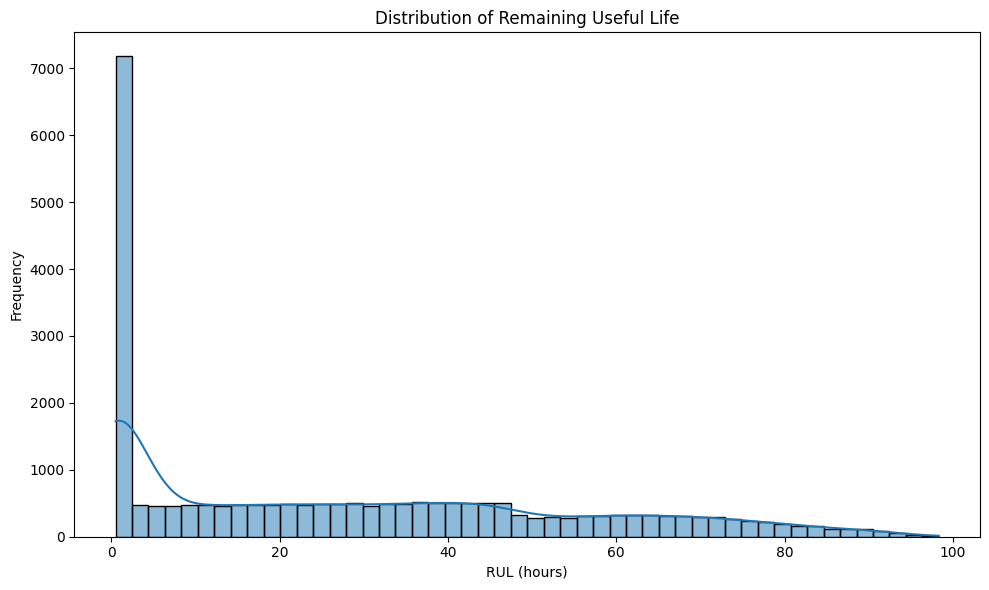

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="rul_hours",
    bins=50,
    kde=True
)

plt.title("Distribution of Remaining Useful Life")
plt.xlabel("RUL (hours)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

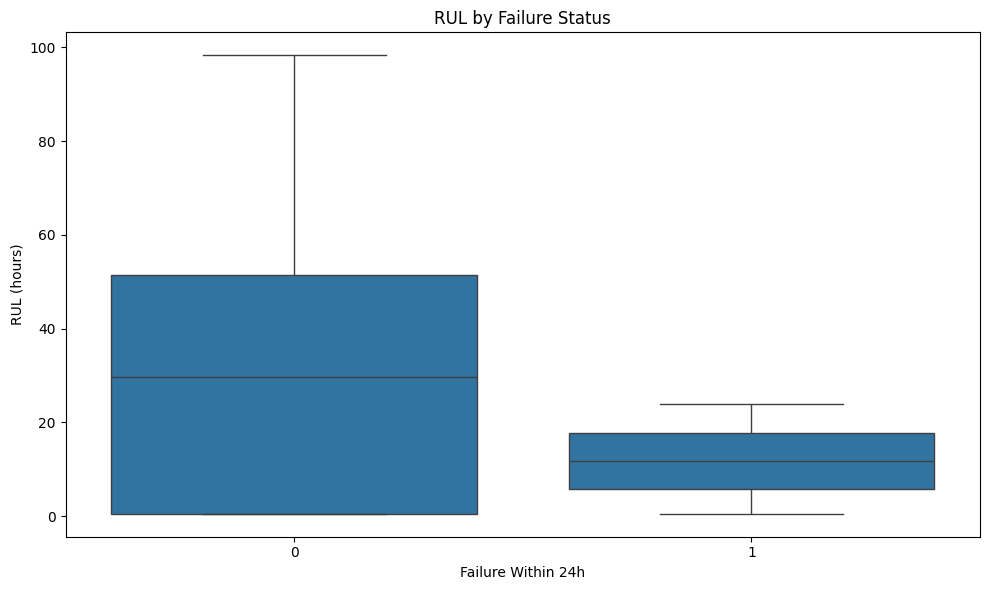

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="failure_within_24h",
    y="rul_hours"
)

plt.title("RUL by Failure Status")
plt.xlabel("Failure Within 24h")
plt.ylabel("RUL (hours)")
plt.tight_layout()
plt.show()

In [ ]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_columns

['machine_id',
 'vibration_rms',
 'temperature_motor',
 'current_phase_avg',
 'pressure_level',
 'rpm',
 'hours_since_maintenance',
 'ambient_temp',
 'rul_hours',
 'failure_within_24h',
 'estimated_repair_cost',
 'failure_episode']

In [ ]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
machine_id,24042.0,10.505033,5.746455,1.00,6.00,10.00,15.0000,20.00
vibration_rms,23042.0,1.623667,1.081061,0.35,0.82,1.27,2.2700,10.00
temperature_motor,23208.0,51.404295,12.519279,28.00,42.61,50.06,59.9625,95.00
current_phase_avg,23311.0,8.823829,5.366391,2.20,4.63,6.43,13.1200,35.00
pressure_level,23118.0,59.012233,38.723271,10.10,22.70,46.30,94.7000,206.50
rpm,23509.0,1144.849317,912.670971,124.10,489.40,856.00,1676.0000,4098.80
hours_since_maintenance,24042.0,172.630624,150.722469,0.00,42.87,121.61,295.5750,575.63
ambient_temp,24042.0,12.996398,2.883994,8.00,10.50,13.00,15.5000,18.00
rul_hours,24042.0,27.812510,26.393801,0.50,0.50,22.57,46.4100,98.34
failure_within_24h,24042.0,0.148074,0.355181,0.00,0.00,0.00,0.0000,1.00


In [ ]:
sensor_columns = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm",
    "hours_since_maintenance",
    "ambient_temp"
]

In [ ]:
df[sensor_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
vibration_rms,23042.0,1.623667,1.081061,0.35,0.82,1.27,2.2700,10.00
temperature_motor,23208.0,51.404295,12.519279,28.00,42.61,50.06,59.9625,95.00
current_phase_avg,23311.0,8.823829,5.366391,2.20,4.63,6.43,13.1200,35.00
pressure_level,23118.0,59.012233,38.723271,10.10,22.70,46.30,94.7000,206.50
rpm,23509.0,1144.849317,912.670971,124.10,489.40,856.00,1676.0000,4098.80
hours_since_maintenance,24042.0,172.630624,150.722469,0.00,42.87,121.61,295.5750,575.63
ambient_temp,24042.0,12.996398,2.883994,8.00,10.50,13.00,15.5000,18.00


In [ ]:
df.groupby(
    "failure_within_24h"
)[sensor_columns].median().T

failure_within_24h,0,1
vibration_rms,1.14,1.95
temperature_motor,48.22,62.16
current_phase_avg,6.14,7.84
pressure_level,46.20,46.90
rpm,861.60,799.40
hours_since_maintenance,114.26,152.50
ambient_temp,13.00,13.00


In [ ]:
df.groupby(
    "failure_within_24h"
)[sensor_columns].mean().T

failure_within_24h,0,1
vibration_rms,1.504538,2.306453
temperature_motor,49.390972,62.989694
current_phase_avg,8.473755,10.843944
pressure_level,58.808050,60.184631
rpm,1154.049303,1092.006139
hours_since_maintenance,166.377279,208.608438
ambient_temp,12.991700,13.023427


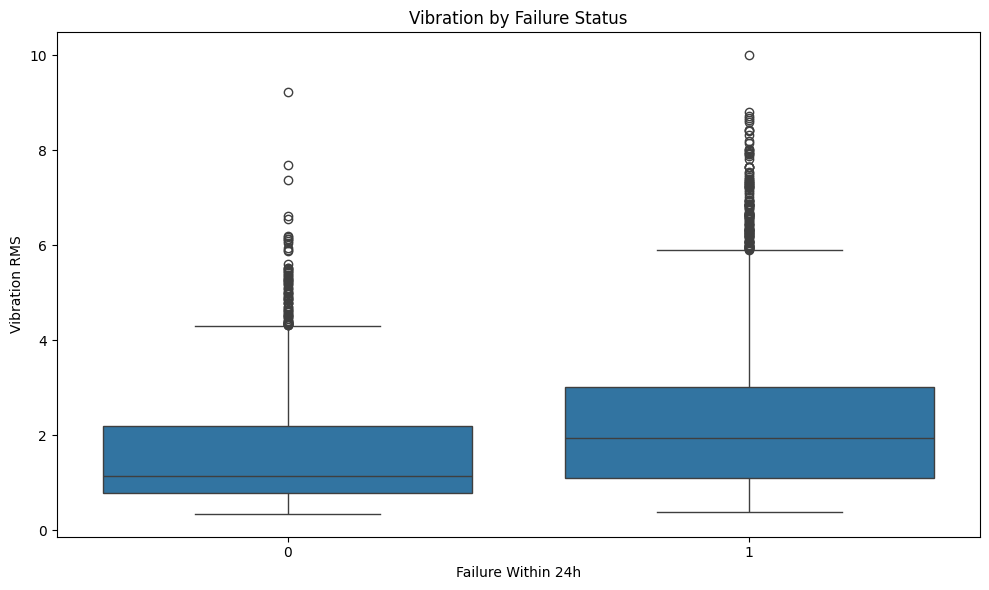

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="failure_within_24h",
    y="vibration_rms"
)

plt.title("Vibration by Failure Status")
plt.xlabel("Failure Within 24h")
plt.ylabel("Vibration RMS")
plt.tight_layout()
plt.show()

In [ ]:
correlation = df[numeric_columns].corr()

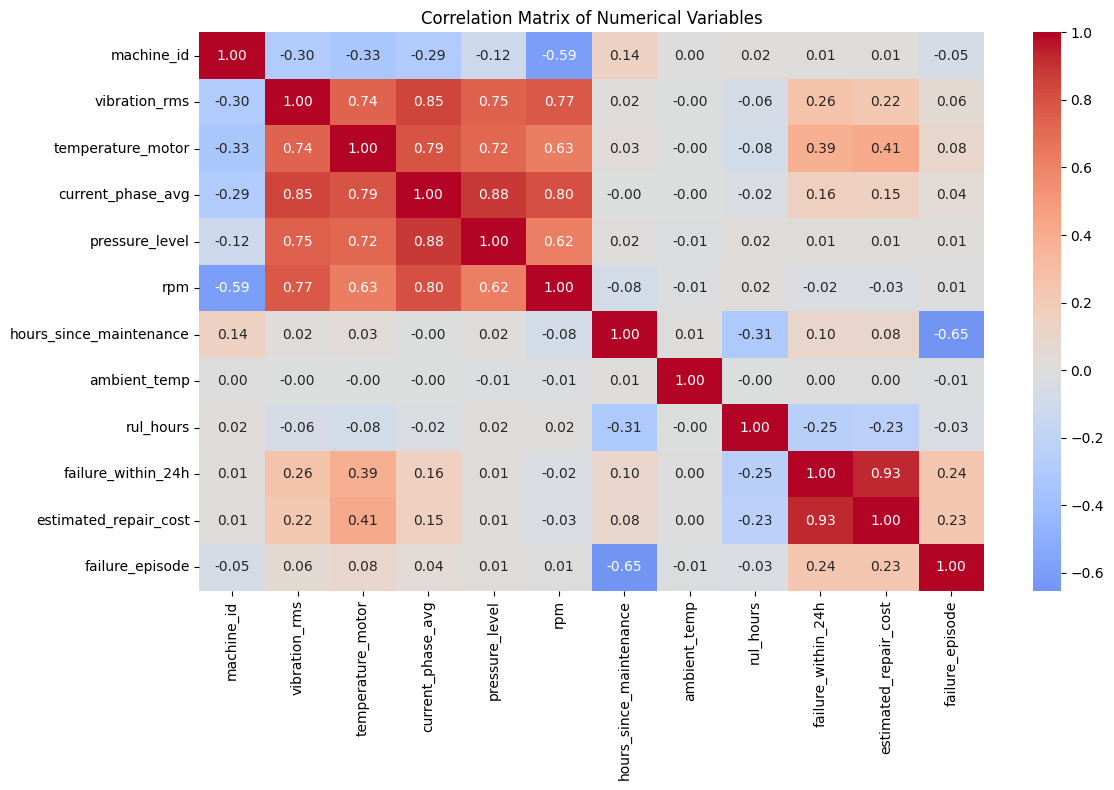

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

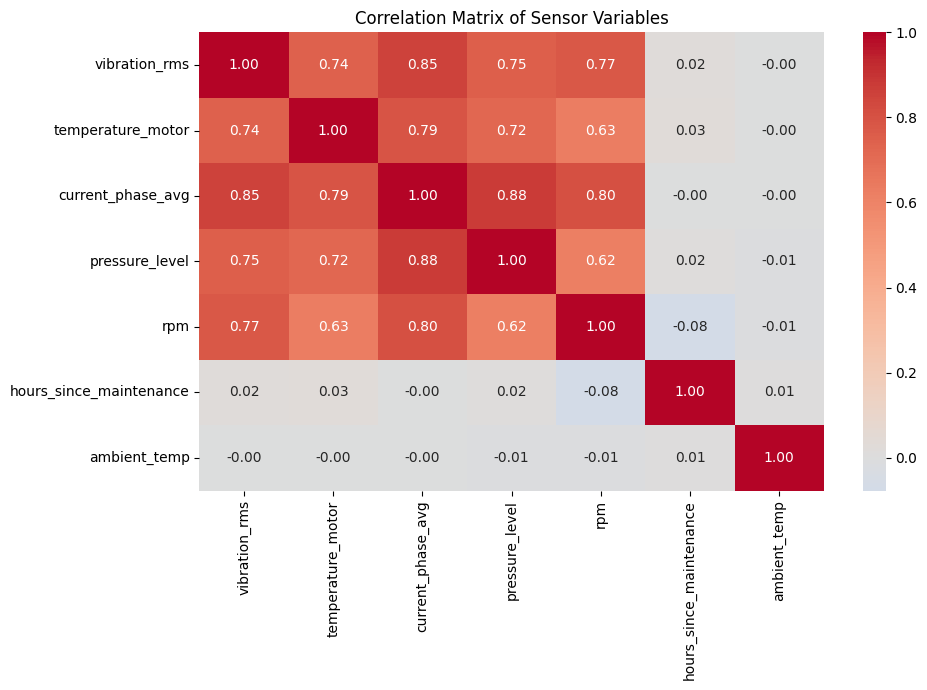

In [ ]:
sensor_correlation = df[sensor_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    sensor_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Sensor Variables")
plt.tight_layout()
plt.show()

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = (
    df.sort_values(["machine_id", "timestamp"])
      .reset_index(drop=True)
)

In [ ]:
df["time_diff"] = (
    df.groupby("machine_id")["timestamp"]
      .diff()
)

In [ ]:
df["time_diff"].describe()

,time_diff
count,24022
mean,0 days 00:16:46.576971109
std,0 days 00:23:17.544198282
min,0 days 00:02:00
25%,0 days 00:09:00
50%,0 days 00:16:00
75%,0 days 00:23:00
max,0 days 19:23:26


In [ ]:
df["time_diff"].value_counts().head(20)

,count
time_diff,
0 days 00:17:00,883
0 days 00:14:00,872
0 days 00:03:00,870
0 days 00:13:00,855
0 days 00:16:00,847
0 days 00:05:00,843
0 days 00:06:00,840
0 days 00:12:00,839
0 days 00:07:00,839


In [ ]:
sampling_by_machine = (
    df.groupby("machine_id")["time_diff"]
      .agg(["count", "min", "median", "mean", "max"])
      .reset_index()
)

sampling_by_machine

,machine_id,count,min,median,mean,max
0,1,1191,0 days 00:02:00,0 days 00:16:00,0 days 00:16:54.748110831,0 days 10:48:31
1,2,1145,0 days 00:02:00,0 days 00:16:00,0 days 00:17:35.802620087,0 days 19:23:26
2,3,1217,0 days 00:02:00,0 days 00:16:00,0 days 00:16:33.689400164,0 days 09:10:22
3,4,1140,0 days 00:02:00,0 days 00:16:00,0 days 00:17:40.412280701,0 days 11:27:30
4,5,1239,0 days 00:02:00,0 days 00:16:00,0 days 00:16:15.744955609,0 days 06:52:08
5,6,1297,0 days 00:02:00,0 days 00:15:00,0 days 00:15:32.383962991,0 days 05:57:02
6,7,1179,0 days 00:02:00,0 days 00:16:00,0 days 00:17:05.454622561,0 days 10:18:51
7,8,1212,0 days 00:02:00,0 days 00:16:00,0 days 00:16:37.069306930,0 days 06:42:53
8,9,1250,0 days 00:02:00,0 days 00:16:00,0 days 00:16:07.504800,0 days 05:40:21
9,10,1171,0 days 00:02:00,0 days 00:16:00,0 days 00:17:12.645602049,0 days 10:03:05


In [ ]:
duplicate_timestamps = (
    df.groupby(["machine_id", "timestamp"])
      .size()
      .reset_index(name="count")
)

duplicate_timestamps[
    duplicate_timestamps["count"] > 1
].head(20)

,machine_id,timestamp,count


In [ ]:
typical_interval = df["time_diff"].median()

print("Typical sampling interval:", typical_interval)

Typical sampling interval: 0 days 00:16:00


In [ ]:
large_gaps = df[
    df["time_diff"] > typical_interval * 2
]

print("Number of unusually large gaps:", len(large_gaps))

large_gaps[
    ["machine_id", "timestamp", "time_diff"]
].head(20)

Number of unusually large gaps: 41


,machine_id,timestamp,time_diff
276,1,2024-01-04 13:51:31,0 days 10:48:31
391,1,2024-01-06 03:00:45,0 days 10:32:14
1466,2,2024-01-04 23:26:26,0 days 19:23:26
1486,2,2024-01-05 12:56:14,0 days 08:16:48
3062,3,2024-01-09 06:17:22,0 days 09:10:22
3396,3,2024-01-13 05:26:20,0 days 07:02:58
3782,4,2024-01-03 22:16:41,0 days 10:31:41
4309,4,2024-01-10 06:09:11,0 days 11:27:30
4590,4,2024-01-13 20:42:50,0 days 08:32:39
5075,5,2024-01-05 13:50:08,0 days 06:52:08


In [ ]:
df["failure_within_24h"].value_counts(dropna=False)

,count
failure_within_24h,
0,20482
1,3560


In [ ]:
df["failure_start"] = (
    df.groupby("machine_id")["failure_within_24h"]
      .diff()
      .eq(1)
)

In [ ]:
df["failure_episode"] = (
    df.groupby("machine_id")["failure_start"]
      .cumsum()
)

In [ ]:
failure_episodes = (
    df[df["failure_within_24h"] == 1]
    .groupby(["machine_id", "failure_episode"])
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        observations=("failure_within_24h", "size"),
        min_rul=("rul_hours", "min"),
        max_rul=("rul_hours", "max")
    )
    .reset_index()
)

failure_episodes

,machine_id,failure_episode,start_time,end_time,observations,min_rul,max_rul
0,1,1,2024-01-03 03:19:00,2024-01-04 03:03:00,85,0.5,23.74
1,1,2,2024-01-04 16:42:31,2024-01-05 16:28:31,102,0.5,23.94
2,2,1,2024-01-03 04:18:00,2024-01-05 04:39:26,108,0.5,23.75
3,3,1,2024-01-07 21:21:00,2024-01-08 21:07:00,91,0.5,23.87
4,3,2,2024-01-11 22:28:22,2024-01-12 22:23:22,92,0.5,23.96
5,4,1,2024-01-02 12:11:00,2024-01-03 11:45:00,88,0.5,23.68
6,4,2,2024-01-08 19:01:41,2024-01-09 18:41:41,93,0.5,23.99
7,4,3,2024-01-12 12:16:11,2024-01-13 12:10:11,82,0.5,23.90
8,5,1,2024-01-04 07:27:00,2024-01-05 06:58:00,93,0.5,23.68
9,6,1,2024-01-03 01:48:00,2024-01-04 01:17:00,98,0.5,23.78


In [ ]:
print("Independent failure episodes:",
      len(failure_episodes))

Independent failure episodes: 38


In [ ]:
print("Independent failure episodes:",
      len(failure_episodes))

Independent failure episodes: 38


In [ ]:
pd.crosstab(
    df["failure_within_24h"],
    df["failure_type"],
    normalize="index"
)

failure_type,bearing,electrical,hydraulic,motor_overheat,none
failure_within_24h,,,,,
0,0.000000,0.000000,0.000000,0.000000,1.0
1,0.313764,0.183989,0.204494,0.297753,0.0


In [ ]:
df["estimated_repair_cost"].describe()

,estimated_repair_cost
count,24042.000000
mean,608.870144
std,1566.793887
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,7995.000000


In [ ]:
df[
    ["failure_within_24h", "estimated_repair_cost"]
].groupby("failure_within_24h").describe()

estimated_repair_cost                                    \
                                   count         mean          std     min   
failure_within_24h                                                           
0                                20482.0     0.000000     0.000000     0.0   
1                                 3560.0  4111.925843  1474.476669  1502.0   

                                                    
                       25%     50%     75%     max  
failure_within_24h                                  
0                      0.0     0.0     0.0     0.0  
1                   3049.0  3842.0  4897.5  7995.0

In [ ]:
pd.crosstab(
    df["failure_within_24h"],
    pd.cut(
        df["rul_hours"],
        bins=[-1, 6, 12, 24, 48, 72, 168, np.inf]
    )
)

rul_hours,"(-1.0, 6.0]","(6.0, 12.0]","(12.0, 24.0]","(24.0, 48.0]","(48.0, 72.0]","(72.0, 168.0]"
failure_within_24h,,,,,,
0,7082,514,1204,6094,3710,1878
1,934,907,1719,0,0,0


In [ ]:
df.groupby("failure_within_24h")["rul_hours"].describe()

,count,mean,std,min,25%,50%,75%,max
failure_within_24h,,,,,,,,
0,20482.0,30.598986,27.511557,0.5,0.50,29.76,51.36,98.34
1,3560.0,11.780882,6.951295,0.5,5.69,11.68,17.82,23.99


In [ ]:
df["failure_6h"] = (df["rul_hours"] <= 6).astype(int)
df["failure_12h"] = (df["rul_hours"] <= 12).astype(int)
df["failure_24h"] = (df["rul_hours"] <= 24).astype(int)
df["failure_48h"] = (df["rul_hours"] <= 48).astype(int)
df["failure_72h"] = (df["rul_hours"] <= 72).astype(int)

In [ ]:
horizon_distribution = pd.DataFrame({
    "6h": df["failure_6h"].value_counts(normalize=True),
    "12h": df["failure_12h"].value_counts(normalize=True),
    "24h": df["failure_24h"].value_counts(normalize=True),
    "48h": df["failure_48h"].value_counts(normalize=True),
    "72h": df["failure_72h"].value_counts(normalize=True)
})

horizon_distribution

,6h,12h,24h,48h,72h
0,0.666583,0.607479,0.4859,0.232427,0.078113
1,0.333417,0.392521,0.5141,0.767573,0.921887


In [ ]:
machine_id = df["machine_id"].iloc[0]

machine_data = df[
    df["machine_id"] == machine_id
].copy()

machine_data[
    [
        "timestamp",
        "rul_hours",
        "vibration_rms",
        "temperature_motor",
        "current_phase_avg",
        "pressure_level",
        "rpm"
    ]
].head(20)

,timestamp,rul_hours,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm
0,2024-01-01 00:00:00,61.00,0.81,49.51,5.10,23.6,860.9
1,2024-01-01 00:03:00,60.95,0.75,40.58,5.30,23.6,899.6
2,2024-01-01 00:21:00,60.65,0.71,49.70,NaN,21.3,862.7
3,2024-01-01 00:45:00,60.25,0.76,43.04,4.79,22.6,870.4
4,2024-01-01 00:54:00,60.10,0.88,41.39,4.44,22.2,881.9
5,2024-01-01 01:23:00,59.62,0.94,42.00,4.77,23.6,853.2
6,2024-01-01 01:47:00,59.22,0.88,41.71,4.10,25.7,917.6
7,2024-01-01 01:55:00,59.08,2.93,54.57,10.13,78.0,2932.1
8,2024-01-01 01:59:00,59.02,0.74,44.95,4.05,25.5,868.1
9,2024-01-01 02:12:00,58.80,0.90,43.12,4.78,23.3,862.9


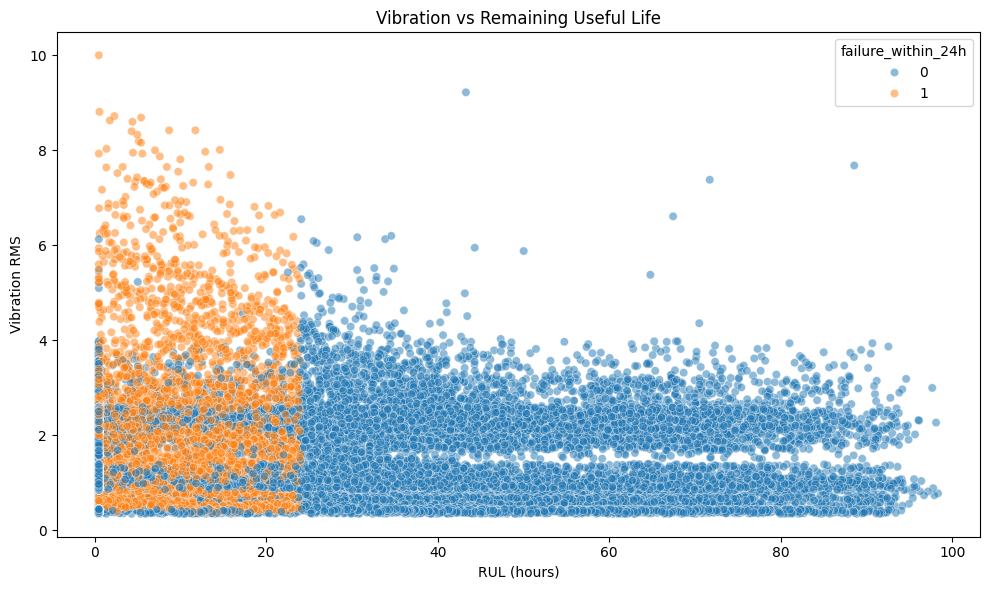

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="rul_hours",
    y="vibration_rms",
    hue="failure_within_24h",
    alpha=0.5
)

plt.title("Vibration vs Remaining Useful Life")
plt.xlabel("RUL (hours)")
plt.ylabel("Vibration RMS")
plt.tight_layout()
plt.show()

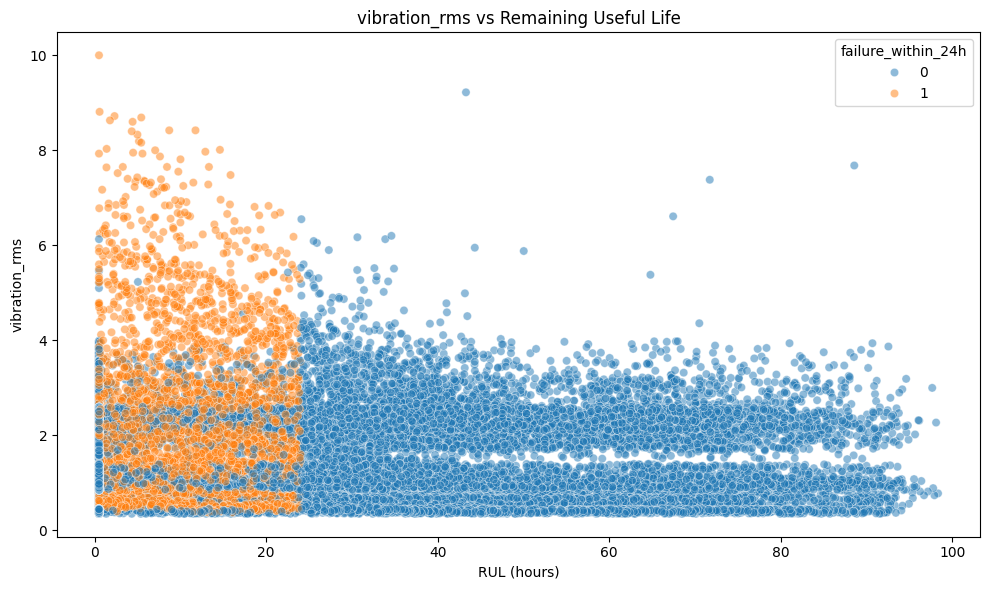

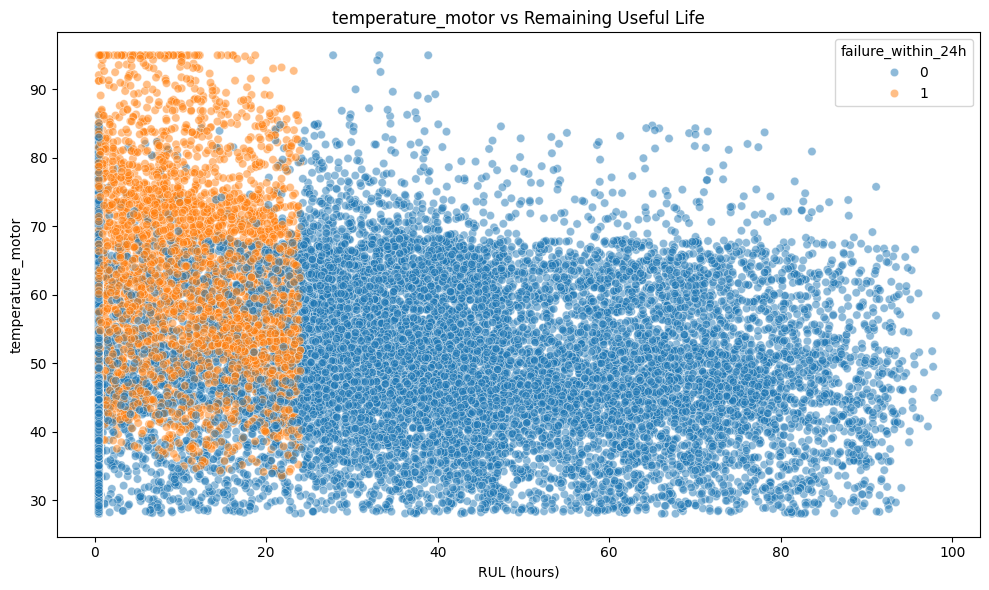

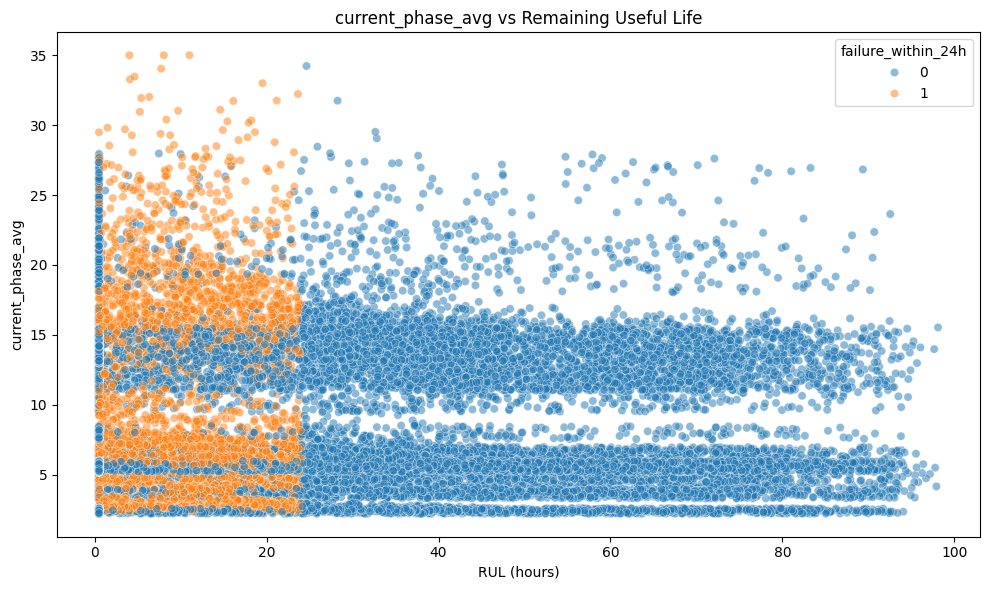

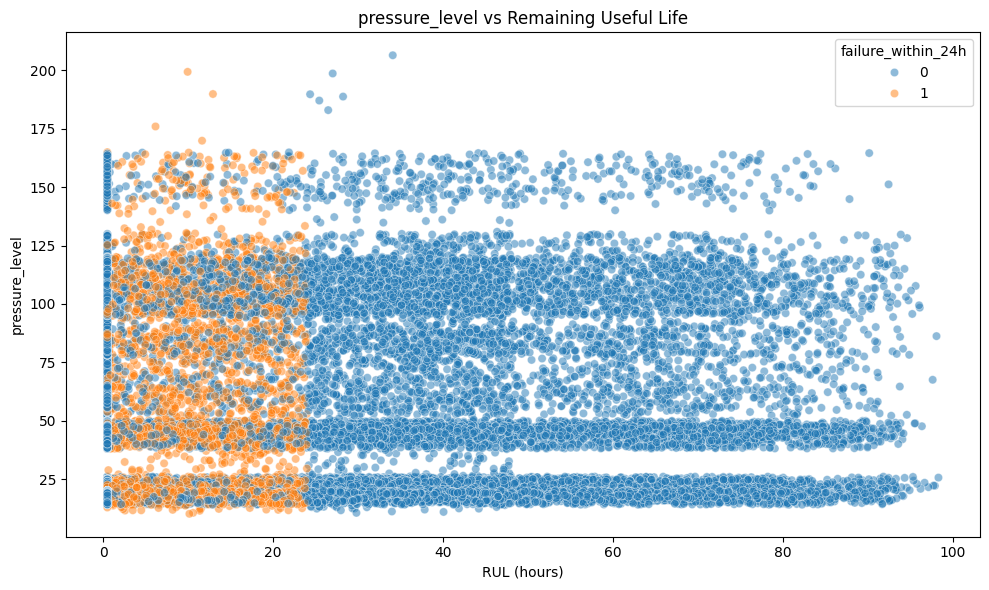

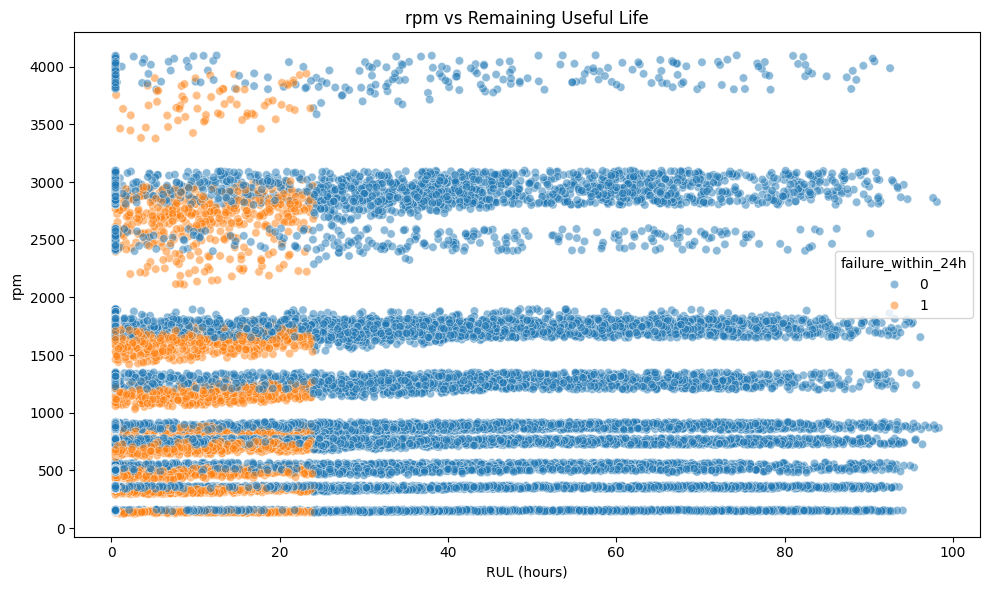

In [ ]:
sensor_columns = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm"
]

for sensor in sensor_columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="rul_hours",
        y=sensor,
        hue="failure_within_24h",
        alpha=0.5
    )

    plt.title(f"{sensor} vs Remaining Useful Life")
    plt.xlabel("RUL (hours)")
    plt.ylabel(sensor)
    plt.tight_layout()
    plt.show()

In [ ]:
df["vibration_rolling_mean"] = (
    df.groupby("machine_id")["vibration_rms"]
      .transform(lambda x: x.rolling(12, min_periods=1).mean())
)

In [ ]:
df["vibration_rolling_std"] = (
    df.groupby("machine_id")["vibration_rms"]
      .transform(lambda x: x.rolling(12, min_periods=1).std())
)

In [ ]:
df["vibration_rolling_max"] = (
    df.groupby("machine_id")["vibration_rms"]
      .transform(lambda x: x.rolling(12, min_periods=1).max())
)

In [ ]:
df["temperature_change"] = (
    df.groupby("machine_id")["temperature_motor"]
      .diff()
)

In [ ]:
df["current_change"] = (
    df.groupby("machine_id")["current_phase_avg"]
      .diff()
)

In [ ]:
df["pressure_change"] = (
    df.groupby("machine_id")["pressure_level"]
      .diff()
)

In [ ]:
df["rpm_change"] = (
    df.groupby("machine_id")["rpm"]
      .diff()
)

In [ ]:
print("Number of machines:", df["machine_id"].nunique())
print(df["machine_id"].unique())

Number of machines: 20
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [ ]:
df.groupby("machine_id").size()

,0
machine_id,
1,1192
2,1146
3,1218
4,1141
5,1240
6,1298
7,1180
8,1213
9,1251


In [ ]:
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

Start: 2024-01-01 00:00:00
End: 2024-01-14 23:59:38


In [ ]:
train_end = df["timestamp"].quantile(0.70)
val_end = df["timestamp"].quantile(0.85)

print("Training ends:", train_end)
print("Validation ends:", val_end)

Training ends: 2024-01-10 20:25:18.100000
Validation ends: 2024-01-12 22:39:29


In [ ]:
train_end = df["timestamp"].quantile(0.70)
val_end = df["timestamp"].quantile(0.85)

print("Training ends:", train_end)
print("Validation ends:", val_end)

Training ends: 2024-01-10 20:25:18.100000
Validation ends: 2024-01-12 22:39:29


In [ ]:
train_df = df[df["timestamp"] <= train_end].copy()

val_df = df[
    (df["timestamp"] > train_end) &
    (df["timestamp"] <= val_end)
].copy()

test_df = df[df["timestamp"] > val_end].copy()

In [ ]:
print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

Training: (16829, 30)
Validation: (3606, 30)
Testing: (3607, 30)


In [ ]:
print("\nTRAIN")
print(train_df["timestamp"].min(), "→", train_df["timestamp"].max())

print("\nVALIDATION")
print(val_df["timestamp"].min(), "→", val_df["timestamp"].max())

print("\nTEST")
print(test_df["timestamp"].min(), "→", test_df["timestamp"].max())


TRAIN
2024-01-01 00:00:00 → 2024-01-10 20:25:02

VALIDATION
2024-01-10 20:25:25 → 2024-01-12 22:38:38

TEST
2024-01-12 22:39:38 → 2024-01-14 23:59:38


In [ ]:
print("Machines in training:")
print(sorted(train_df["machine_id"].unique()))

print("\nMachines in validation:")
print(sorted(val_df["machine_id"].unique()))

print("\nMachines in testing:")
print(sorted(test_df["machine_id"].unique()))

Machines in training:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

Machines in validation:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

Machines in testing:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


In [ ]:
sensor_columns = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm"
]

In [ ]:
df["vibration_lag1"] = (
    df.groupby("machine_id")["vibration_rms"]
      .shift(1)
)

In [ ]:
df["temperature_lag1"] = (
    df.groupby("machine_id")["temperature_motor"]
      .shift(1)
)

In [ ]:
for col in sensor_columns:
    df[f"{col}_lag1"] = (
        df.groupby("machine_id")[col]
          .shift(1)
    )

In [ ]:
for col in sensor_columns:
    df[f"{col}_lag6"] = (
        df.groupby("machine_id")[col]
          .shift(6)
    )

In [ ]:
df["vibration_rolling_mean"] = (
    df.groupby("machine_id")["vibration_rms"]
      .transform(
          lambda x: x.rolling(
              window=12,
              min_periods=1
          ).mean()
      )
)

In [ ]:
df["vibration_rolling_std"] = (
    df.groupby("machine_id")["vibration_rms"]
      .transform(
          lambda x: x.rolling(
              window=12,
              min_periods=2
          ).std()
      )
)

In [ ]:
df["vibration_rolling_max"] = (
    df.groupby("machine_id")["vibration_rms"]
      .transform(
          lambda x: x.rolling(
              window=12,
              min_periods=1
          ).max()
      )
)

In [ ]:
for col in sensor_columns:

    df[f"{col}_rolling_mean_1h"] = (
        df.groupby("machine_id")[col]
          .transform(
              lambda x: x.rolling(
                  window=12,
                  min_periods=1
              ).mean()
          )
    )

    df[f"{col}_rolling_std_1h"] = (
        df.groupby("machine_id")[col]
          .transform(
              lambda x: x.rolling(
                  window=12,
                  min_periods=2
              ).std()
          )
    )

    df[f"{col}_rolling_max_1h"] = (
        df.groupby("machine_id")[col]
          .transform(
              lambda x: x.rolling(
                  window=12,
                  min_periods=1
              ).max()
          )
    )

In [ ]:
for col in sensor_columns:
    df[f"{col}_change"] = (
        df.groupby("machine_id")[col]
          .diff()
    )

In [ ]:
for col in sensor_columns:
    df[f"{col}_pct_change"] = (
        df.groupby("machine_id")[col]
          .pct_change()
    )

In [ ]:
df["vibration_trend"] = (
    df.groupby("machine_id")["vibration_rms"]
      .transform(
          lambda x: x.rolling(12, min_periods=2)
                    .apply(
                        lambda y: np.polyfit(
                            np.arange(len(y)),
                            y,
                            1
                        )[0]
                    )
      )
)

In [ ]:
operating_columns = [
    "rpm",
    "ambient_temp",
    "hours_since_maintenance"
]

df[operating_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
rpm,23509.0,1144.849317,912.670971,124.1,489.40,856.00,1676.000,4098.80
ambient_temp,24042.0,12.996398,2.883994,8.0,10.50,13.00,15.500,18.00
hours_since_maintenance,24042.0,172.630624,150.722469,0.0,42.87,121.61,295.575,575.63


In [ ]:
df["machine_type"].value_counts()

,count
machine_type,
Pump,6114
Robotic Arm,6003
Compressor,5988
CNC,5937


In [ ]:
df = pd.get_dummies(
    df,
    columns=["machine_type"],
    drop_first=True
)

In [ ]:
target = "failure_within_24h"

excluded_columns = [
    "failure_within_24h",
    "rul_hours",
    "failure_type",
    "estimated_repair_cost",
    "failure_start",
    "failure_episode"
]

In [ ]:
feature_columns = [
    col for col in df.columns
    if col not in excluded_columns
    and col != "timestamp"
]

In [ ]:
print("Number of features:", len(feature_columns))
print(feature_columns)

Number of features: 62
['machine_id', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'time_diff', 'failure_6h', 'failure_12h', 'failure_24h', 'failure_48h', 'failure_72h', 'vibration_rolling_mean', 'vibration_rolling_std', 'vibration_rolling_max', 'temperature_change', 'current_change', 'pressure_change', 'rpm_change', 'vibration_lag1', 'temperature_lag1', 'vibration_rms_lag1', 'temperature_motor_lag1', 'current_phase_avg_lag1', 'pressure_level_lag1', 'rpm_lag1', 'vibration_rms_lag6', 'temperature_motor_lag6', 'current_phase_avg_lag6', 'pressure_level_lag6', 'rpm_lag6', 'vibration_rms_rolling_mean_1h', 'vibration_rms_rolling_std_1h', 'vibration_rms_rolling_max_1h', 'temperature_motor_rolling_mean_1h', 'temperature_motor_rolling_std_1h', 'temperature_motor_rolling_max_1h', 'current_phase_avg_rolling_mean_1h', 'current_phase_avg_rolling_std_1h', 'current_phase_avg_rolling_max_1h', 'pressure_

In [ ]:
feature_columns = [
    col for col in feature_columns
    if col != "machine_id"
]

In [ ]:
X = df[feature_columns].copy()

y = df[target].copy()

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (24042, 61)
y shape: (24042,)


In [ ]:
X.head()

,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,time_diff,failure_6h,failure_12h,failure_24h,failure_48h,failure_72h,vibration_rolling_mean,vibration_rolling_std,vibration_rolling_max,temperature_change,current_change,pressure_change,rpm_change,vibration_lag1,temperature_lag1,vibration_rms_lag1,temperature_motor_lag1,current_phase_avg_lag1,pressure_level_lag1,rpm_lag1,vibration_rms_lag6,temperature_motor_lag6,current_phase_avg_lag6,pressure_level_lag6,rpm_lag6,vibration_rms_rolling_mean_1h,vibration_rms_rolling_std_1h,vibration_rms_rolling_max_1h,temperature_motor_rolling_mean_1h,temperature_motor_rolling_std_1h,temperature_motor_rolling_max_1h,current_phase_avg_rolling_mean_1h,current_phase_avg_rolling_std_1h,current_phase_avg_rolling_max_1h,pressure_level_rolling_mean_1h,pressure_level_rolling_std_1h,pressure_level_rolling_max_1h,rpm_rolling_mean_1h,rpm_rolling_std_1h,rpm_rolling_max_1h,vibration_rms_change,temperature_motor_change,current_phase_avg_change,pressure_level_change,vibration_rms_pct_change,temperature_motor_pct_change,current_phase_avg_pct_change,pressure_level_pct_change,rpm_pct_change,vibration_trend,machine_type_Compressor,machine_type_Pump,machine_type_Robotic Arm
0,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,NaT,0,0,0,0,1,0.810000,NaN,0.81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.810000,NaN,0.81,49.510000,NaN,49.51,5.100000,NaN,5.1,23.600000,NaN,23.6,860.90,NaN,860.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
1,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,0 days 00:03:00,0,0,0,0,1,0.780000,0.042426,0.81,-8.93,0.20,0.0,38.7,0.81,49.51,0.81,49.51,5.10,23.6,860.9,NaN,NaN,NaN,NaN,NaN,0.780000,0.042426,0.81,45.045000,6.314464,49.51,5.200000,0.141421,5.3,23.600000,0.000000,23.6,880.25,27.365032,899.6,-0.06,-8.93,0.20,0.0,-0.074074,-0.180368,0.039216,0.000000,0.044953,-0.060,False,False,False
2,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,0 days 00:18:00,0,0,0,0,1,0.756667,0.050332,0.81,9.12,NaN,-2.3,-36.9,0.75,40.58,0.75,40.58,5.30,23.6,899.6,NaN,NaN,NaN,NaN,NaN,0.756667,0.050332,0.81,46.596667,5.211452,49.70,5.200000,0.141421,5.3,22.833333,1.327906,23.6,874.40,21.842390,899.6,-0.04,9.12,NaN,-2.3,-0.053333,0.224741,0.000000,-0.097458,-0.041018,-0.050,False,False,False
3,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,0 days 00:24:00,0,0,0,0,1,0.757500,0.041130,0.81,-6.66,NaN,1.3,7.7,0.71,49.70,0.71,49.70,NaN,21.3,862.7,NaN,NaN,NaN,NaN,NaN,0.757500,0.041130,0.81,45.707500,4.611792,49.70,5.063333,0.256970,5.3,22.775000,1.090489,23.6,873.40,17.946030,899.6,0.05,-6.66,NaN,1.3,0.070423,-0.134004,-0.096226,0.061033,0.008925,-0.019,False,False,False
4,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,0 days 00:09:00,0,0,0,0,1,0.782000,0.065345,0.88,-1.65,-0.35,-0.4,11.5,0.76,43.04,0.76,43.04,4.79,22.6,870.4,NaN,NaN,NaN,NaN,NaN,0.782000,0.065345,0.88,44.844000,4.436173,49.70,4.907500,0.375710,5.3,22.660000,0.978775,23.6,875.10,15.999844,899.6,0.12,-1.65,-0.35,-0.4,0.157895,-0.038336,-0.073069,-0.017699,0.013212,0.015,False,False,False


In [ ]:
feature_missing = (
    X.isnull()
     .sum()
     .sort_values(ascending=False)
)

feature_missing.head(20)

,0
vibration_trend,9586
vibration_rms_change,1980
pressure_level_change,1832
pressure_change,1832
temperature_change,1663
temperature_motor_change,1663
current_change,1458
current_phase_avg_change,1458
vibration_rms_lag6,1116
rpm_change,1073


In [ ]:
X = X.replace([np.inf, -np.inf], np.nan)

In [ ]:
train_df = df[df["timestamp"] <= train_end].copy()

val_df = df[
    (df["timestamp"] > train_end) &
    (df["timestamp"] <= val_end)
].copy()

test_df = df[df["timestamp"] > val_end].copy()

In [ ]:
X_train = train_df[feature_columns]
y_train = train_df[target]

X_val = val_df[feature_columns]
y_val = val_df[target]

X_test = test_df[feature_columns]
y_test = test_df[target]

In [ ]:
print("Training target:")
print(y_train.value_counts(normalize=True))

print("\nValidation target:")
print(y_val.value_counts(normalize=True))

print("\nTesting target:")
print(y_test.value_counts(normalize=True))

Training target:
failure_within_24h
0    0.83267
1    0.16733
Name: proportion, dtype: float64

Validation target:
failure_within_24h
0    0.818636
1    0.181364
Name: proportion, dtype: float64

Testing target:
failure_within_24h
0    0.975049
1    0.024951
Name: proportion, dtype: float64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Identify numeric and categorical columns
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns

print("Numeric features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numeric features:
['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'failure_6h', 'failure_12h', 'failure_24h', 'failure_48h', 'failure_72h', 'vibration_rolling_mean', 'vibration_rolling_std', 'vibration_rolling_max', 'temperature_change', 'current_change', 'pressure_change', 'rpm_change', 'vibration_lag1', 'temperature_lag1', 'vibration_rms_lag1', 'temperature_motor_lag1', 'current_phase_avg_lag1', 'pressure_level_lag1', 'rpm_lag1', 'vibration_rms_lag6', 'temperature_motor_lag6', 'current_phase_avg_lag6', 'pressure_level_lag6', 'rpm_lag6', 'vibration_rms_rolling_mean_1h', 'vibration_rms_rolling_std_1h', 'vibration_rms_rolling_max_1h', 'temperature_motor_rolling_mean_1h', 'temperature_motor_rolling_std_1h', 'temperature_motor_rolling_max_1h', 'current_phase_avg_rolling_mean_1h', 'current_phase_avg_rolling_std_1h', 'current_phase_avg_rolling_max_1h', 'pressure_level_rolling_mean_1h', 'pressure_level_rolling_st

In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [ ]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [ ]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['vibration_rms', 'temperature_motor', 'current_phase_avg',
       'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp',
       'failure_6h', 'failure_12h', 'failure_24h', 'failure_48h',
       'failu...
       'current_phase_avg_pct_change', 'pressure_level_pct_change',
       'rpm_pct_change', 'vibration_trend'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['operating_mode'], dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("PR-AUC:", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3517
           1       0.97      1.00      0.98        90

    accuracy                           1.00      3607
   macro avg       0.98      1.00      0.99      3607
weighted avg       1.00      1.00      1.00      3607

ROC-AUC: 1.0
PR-AUC: 0.9999999999999998

Confusion Matrix:
[[3514    3]
 [   0   90]]


In [ ]:
# ==========================================
# TARGET & LEAKAGE AUDIT
# ==========================================

print("Failure label distribution:")
print(df["failure_within_24h"].value_counts())

print("\nFailure label percentage:")
print(df["failure_within_24h"].value_counts(normalize=True) * 100)

print("\nFailure type vs target:")
print(
    pd.crosstab(
        df["failure_type"],
        df["failure_within_24h"],
        normalize="index"
    ).round(3)
)

print("\nRUL statistics by failure label:")
print(
    df.groupby("failure_within_24h")["rul_hours"]
      .describe()
      .round(2)
)

print("\nRepair cost statistics by failure label:")
print(
    df.groupby("failure_within_24h")["estimated_repair_cost"]
      .describe()
      .round(2)
)

Failure label distribution:
failure_within_24h
0    20482
1     3560
Name: count, dtype: int64

Failure label percentage:
failure_within_24h
0    85.19258
1    14.80742
Name: proportion, dtype: float64

Failure type vs target:
failure_within_24h    0    1
failure_type                
bearing             0.0  1.0
electrical          0.0  1.0
hydraulic           0.0  1.0
motor_overheat      0.0  1.0
none                1.0  0.0

RUL statistics by failure label:
                      count   mean    std  min   25%    50%    75%    max
failure_within_24h                                                       
0                   20482.0  30.60  27.51  0.5  0.50  29.76  51.36  98.34
1                    3560.0  11.78   6.95  0.5  5.69  11.68  17.82  23.99

Repair cost statistics by failure label:
                      count     mean      std     min     25%     50%     75%  \
failure_within_24h                                                              
0                   20482.0     0.00

In [ ]:
# ==========================================
# DIRECT LEAKAGE CHECKS
# ==========================================

print("Failure type determines failure label:")
print(
    (df["failure_type"].ne("none") == df["failure_within_24h"]).mean()
)

print("\nRepair cost vs failure label:")
print(
    pd.crosstab(
        df["estimated_repair_cost"] > 0,
        df["failure_within_24h"],
        normalize="index"
    ).round(3)
)

print("\nRUL <= 24h vs failure label:")
print(
    pd.crosstab(
        df["rul_hours"] <= 24,
        df["failure_within_24h"],
        normalize="index"
    ).round(3)
)

Failure type determines failure label:
1.0

Repair cost vs failure label:
failure_within_24h       0    1
estimated_repair_cost          
False                  1.0  0.0
True                   0.0  1.0

RUL <= 24h vs failure label:
failure_within_24h      0      1
rul_hours                       
False               1.000  0.000
True                0.712  0.288


In [ ]:
# ==========================================
# RUL TEMPORAL BEHAVIOUR AUDIT
# ==========================================

df["rul_change"] = (
    df.groupby("machine_id")["rul_hours"]
      .diff()
)

print("RUL change statistics:")
print(df["rul_change"].describe().round(2))

print("\nLargest RUL increases:")
print(
    df.loc[
        df["rul_change"].nlargest(20).index,
        [
            "machine_id",
            "timestamp",
            "rul_hours",
            "rul_change",
            "failure_within_24h",
            "failure_type"
        ]
    ]
    .sort_values("rul_change", ascending=False)
)

RUL change statistics:
count    24022.00
mean        -0.05
std          3.32
min        -35.57
25%         -0.34
50%         -0.17
75%          0.00
max         95.89
Name: rul_change, dtype: float64

Largest RUL increases:
       machine_id           timestamp  rul_hours  rul_change  \
16410          14 2024-01-10 06:07:24      96.39       95.89   
11600          10 2024-01-09 17:40:25      95.66       95.16   
3062            3 2024-01-09 06:17:22      94.62       94.12   
21955          19 2024-01-04 05:52:19      94.06       93.56   
14076          12 2024-01-11 09:54:36      93.50       93.00   
10647           9 2024-01-12 11:55:21      93.04       92.54   
391             1 2024-01-06 03:00:45      92.57       92.07   
21582          18 2024-01-13 16:25:09      91.75       91.25   
22658          19 2024-01-12 17:02:49      91.04       90.54   
14860          13 2024-01-06 08:49:15      85.20       84.70   
23162          20 2024-01-04 12:04:21      84.88       84.38   
23424   

In [ ]:
# ==========================================
# RUL RESET / MAINTENANCE INVESTIGATION
# ==========================================

rul_resets = df[df["rul_change"] > 10].copy()

print("Number of major RUL increases:", len(rul_resets))

print("\nRUL reset statistics:")
print(
    rul_resets["rul_change"]
    .describe()
    .round(2)
)

print("\nExamples of RUL resets:")
print(
    rul_resets[
        [
            "machine_id",
            "timestamp",
            "rul_hours",
            "rul_change",
            "failure_within_24h",
            "failure_type"
        ]
    ]
    .head(30)
)

Number of major RUL increases: 55

RUL reset statistics:
count    55.00
mean     64.25
std      23.63
min      13.84
25%      47.28
50%      73.13
75%      82.65
max      95.89
Name: rul_change, dtype: float64

Examples of RUL resets:
       machine_id           timestamp  rul_hours  rul_change  \
101             1 2024-01-02 03:04:00      47.99       13.84   
276             1 2024-01-04 13:51:31      26.79       26.29   
391             1 2024-01-06 03:00:45      92.57       92.07   
1486            2 2024-01-05 12:56:14      75.30       74.80   
2874            3 2024-01-06 21:27:00      47.77       47.27   
3062            3 2024-01-09 06:17:22      94.62       94.12   
3396            3 2024-01-13 05:26:20      73.15       72.65   
3782            4 2024-01-03 22:16:41      80.58       80.08   
4136            4 2024-01-07 19:01:41      47.99       47.49   
4309            4 2024-01-10 06:09:11      74.61       74.11   
4590            4 2024-01-13 20:42:50      83.28       82.78 

In [ ]:
# ==========================================
# RUL BY MACHINE
# ==========================================

rul_machine_summary = (
    df.groupby("machine_id")["rul_hours"]
      .agg(
          min="min",
          max="max",
          mean="mean",
          median="median",
          std="std"
      )
      .round(2)
)

rul_machine_summary

,min,max,mean,median,std
machine_id,,,,,
1,0.5,92.57,22.39,11.42,25.85
2,0.5,80.46,18.64,0.50,24.54
3,0.5,98.34,38.10,36.61,28.78
4,0.5,87.91,37.66,36.38,24.73
5,0.5,83.48,20.45,9.75,23.73
6,0.5,93.33,18.94,0.50,26.91
7,0.5,82.13,35.64,35.54,20.73
8,0.5,80.86,17.12,3.57,21.54
9,0.5,93.04,26.71,16.42,28.87


In [ ]:
# ==========================================
# RUL AROUND FAILURE EVENTS
# ==========================================

failure_rows = df[df["failure_within_24h"] == 1].copy()

print("RUL during failure-risk observations:")
print(
    failure_rows["rul_hours"]
    .describe()
    .round(2)
)

print("\nFailure observations by RUL range:")

rul_bins = [0, 6, 12, 18, 24, 36, 50, 100]

failure_rul_distribution = (
    pd.cut(
        df["rul_hours"],
        bins=rul_bins,
        include_lowest=True
    )
    .groupby(df["failure_within_24h"])
    .value_counts()
    .unstack(fill_value=0)
)

failure_rul_distribution

RUL during failure-risk observations:
count    3560.00
mean       11.78
std         6.95
min         0.50
25%         5.69
50%        11.68
75%        17.82
max        23.99
Name: rul_hours, dtype: float64

Failure observations by RUL range:


rul_hours,"(-0.001, 6.0]","(6.0, 12.0]","(12.0, 18.0]","(18.0, 24.0]","(24.0, 36.0]","(36.0, 50.0]","(50.0, 100.0]"
failure_within_24h,,,,,,,
0,7082,514,581,623,2968,3406,5308
1,934,907,860,859,0,0,0


In [ ]:
# ==========================================
# RUL AROUND FAILURE EVENTS
# ==========================================

# 1. RUL statistics for failure-risk observations
failure_rows = df[df["failure_within_24h"] == 1].copy()

print("RUL during failure-risk observations:")
print(
    failure_rows["rul_hours"]
    .describe()
    .round(2)
)

# 2. Failure rate by RUL range
rul_bins = [0, 6, 12, 18, 24, 36, 50, 100]
rul_labels = [
    "0-6",
    "6-12",
    "12-18",
    "18-24",
    "24-36",
    "36-50",
    "50-100"
]

df["rul_range"] = pd.cut(
    df["rul_hours"],
    bins=rul_bins,
    labels=rul_labels,
    include_lowest=True
)

rul_summary = (
    df.groupby("rul_range", observed=False)
      .agg(
          total_observations=("failure_within_24h", "size"),
          failure_observations=("failure_within_24h", "sum")
      )
)

rul_summary["failure_rate_%"] = (
    rul_summary["failure_observations"]
    / rul_summary["total_observations"]
    * 100
)

print("\nFailure rate by RUL range:")
display(rul_summary.round(2))

RUL during failure-risk observations:
count    3560.00
mean       11.78
std         6.95
min         0.50
25%         5.69
50%        11.68
75%        17.82
max        23.99
Name: rul_hours, dtype: float64

Failure rate by RUL range:


,total_observations,failure_observations,failure_rate_%
rul_range,,,
0-6,8016,934,11.65
6-12,1421,907,63.83
12-18,1441,860,59.68
18-24,1482,859,57.96
24-36,2968,0,0.00
36-50,3406,0,0.00
50-100,5308,0,0.00


In [ ]:
# ==========================================
# RUL VALIDITY AUDIT BY MACHINE
# ==========================================

# 1. How often does each machine have RUL > 24h
machine_rul = (
    df.groupby("machine_id")
      .agg(
          observations=("rul_hours", "size"),
          min_rul=("rul_hours", "min"),
          max_rul=("rul_hours", "max"),
          mean_rul=("rul_hours", "mean"),
          rul_above_24=("rul_hours", lambda x: (x > 24).sum()),
          failure_count=("failure_within_24h", "sum")
      )
)

machine_rul["pct_rul_above_24"] = (
    machine_rul["rul_above_24"]
    / machine_rul["observations"]
    * 100
)

print("Machine-level RUL summary:")
display(machine_rul.round(2))


# 2. Check whether failure observations occur only
#    within the RUL <= 24h region
print("\nTarget distribution by RUL > 24h:")
print(
    pd.crosstab(
        df["rul_hours"] > 24,
        df["failure_within_24h"],
        normalize="index"
    ).round(3)
)


# 3. Examine RUL transitions around failure events
df_sorted = df.sort_values(["machine_id", "timestamp"]).copy()

df_sorted["previous_rul"] = (
    df_sorted.groupby("machine_id")["rul_hours"].shift(1)
)

df_sorted["rul_change"] = (
    df_sorted["rul_hours"] - df_sorted["previous_rul"]
)

failure_transitions = df_sorted[
    df_sorted["failure_within_24h"] == 1
][
    [
        "machine_id",
        "timestamp",
        "rul_hours",
        "previous_rul",
        "rul_change",
        "failure_within_24h"
    ]
]

print("\nRUL immediately around failure-risk observations:")
display(failure_transitions.head(30))

Machine-level RUL summary:


,observations,min_rul,max_rul,mean_rul,rul_above_24,failure_count,pct_rul_above_24
machine_id,,,,,,,
1,1192,0.5,92.57,22.39,455,187,38.17
2,1146,0.5,80.46,18.64,376,108,32.81
3,1218,0.5,98.34,38.10,769,183,63.14
4,1141,0.5,87.91,37.66,746,263,65.38
5,1240,0.5,83.48,20.45,464,93,37.42
6,1298,0.5,93.33,18.94,400,98,30.82
7,1180,0.5,82.13,35.64,795,275,67.37
8,1213,0.5,80.86,17.12,388,175,31.99
9,1251,0.5,93.04,26.71,564,90,45.08



Target distribution by RUL > 24h:
failure_within_24h      0      1
rul_hours                       
False               0.712  0.288
True                1.000  0.000

RUL immediately around failure-risk observations:


,machine_id,timestamp,rul_hours,previous_rul,rul_change,failure_within_24h
191,1,2024-01-03 03:19:00,23.74,24.21,-0.47,1
192,1,2024-01-03 03:39:00,23.41,23.74,-0.33,1
193,1,2024-01-03 03:46:00,23.29,23.41,-0.12,1
194,1,2024-01-03 04:16:00,22.79,23.29,-0.50,1
195,1,2024-01-03 04:24:00,22.66,22.79,-0.13,1
196,1,2024-01-03 04:48:00,22.26,22.66,-0.40,1
197,1,2024-01-03 04:52:00,22.19,22.26,-0.07,1
198,1,2024-01-03 05:05:00,21.98,22.19,-0.21,1
199,1,2024-01-03 05:17:00,21.78,21.98,-0.20,1
200,1,2024-01-03 05:22:00,21.69,21.78,-0.09,1


In [ ]:
# ==========================================
# DEFINE LEAKAGE-SAFE FEATURE SET
# ==========================================

target = "failure_within_24h"

# Variables that should NOT be used as predictors
excluded_features = [
    target,
    "failure_type",
    "estimated_repair_cost",
    "rul_hours",
    "rul_range"
]

# Also exclude identifiers/time fields from the initial model
identifier_time_features = [
    "machine_id",
    "timestamp"
]

# Candidate predictors
candidate_features = [
    col for col in df.columns
    if col not in excluded_features + identifier_time_features
]

print("Candidate predictor variables:")
for i, col in enumerate(candidate_features, 1):
    print(f"{i}. {col}")

print("\nNumber of candidate predictors:", len(candidate_features))

Candidate predictor variables:
1. vibration_rms
2. temperature_motor
3. current_phase_avg
4. pressure_level
5. rpm
6. operating_mode
7. hours_since_maintenance
8. ambient_temp
9. failure_start
10. failure_episode
11. time_diff
12. failure_6h
13. failure_12h
14. failure_24h
15. failure_48h
16. failure_72h
17. vibration_rolling_mean
18. vibration_rolling_std
19. vibration_rolling_max
20. temperature_change
21. current_change
22. pressure_change
23. rpm_change
24. vibration_lag1
25. temperature_lag1
26. vibration_rms_lag1
27. temperature_motor_lag1
28. current_phase_avg_lag1
29. pressure_level_lag1
30. rpm_lag1
31. vibration_rms_lag6
32. temperature_motor_lag6
33. current_phase_avg_lag6
34. pressure_level_lag6
35. rpm_lag6
36. vibration_rms_rolling_mean_1h
37. vibration_rms_rolling_std_1h
38. vibration_rms_rolling_max_1h
39. temperature_motor_rolling_mean_1h
40. temperature_motor_rolling_std_1h
41. temperature_motor_rolling_max_1h
42. current_phase_avg_rolling_mean_1h
43. current_phase_av

In [ ]:
# ==========================================
# LEAKAGE-SAFE FEATURE AUDIT
# ==========================================

# Variables that directly reveal failure or future information
leakage_features = [
    "failure_start",
    "failure_episode",
    "failure_6h",
    "failure_12h",
    "failure_24h",
    "failure_48h",
    "failure_72h",
    "rul_change"
]

# Variables already identified as problematic
previously_excluded = [
    "failure_within_24h",
    "failure_type",
    "estimated_repair_cost",
    "rul_hours",
    "rul_range",
    "machine_id",
    "timestamp"
]

# Final provisional feature set
provisional_features = [
    col for col in df.columns
    if col not in previously_excluded + leakage_features
]

print("PROVISIONAL LEAKAGE-SAFE FEATURES")
print("=" * 50)

for i, col in enumerate(provisional_features, 1):
    print(f"{i}. {col}")

print("\nNumber of provisional features:", len(provisional_features))

print("\nExcluded features:")
for col in previously_excluded + leakage_features:
    if col in df.columns:
        print(f"- {col}")

PROVISIONAL LEAKAGE-SAFE FEATURES
1. vibration_rms
2. temperature_motor
3. current_phase_avg
4. pressure_level
5. rpm
6. operating_mode
7. hours_since_maintenance
8. ambient_temp
9. time_diff
10. vibration_rolling_mean
11. vibration_rolling_std
12. vibration_rolling_max
13. temperature_change
14. current_change
15. pressure_change
16. rpm_change
17. vibration_lag1
18. temperature_lag1
19. vibration_rms_lag1
20. temperature_motor_lag1
21. current_phase_avg_lag1
22. pressure_level_lag1
23. rpm_lag1
24. vibration_rms_lag6
25. temperature_motor_lag6
26. current_phase_avg_lag6
27. pressure_level_lag6
28. rpm_lag6
29. vibration_rms_rolling_mean_1h
30. vibration_rms_rolling_std_1h
31. vibration_rms_rolling_max_1h
32. temperature_motor_rolling_mean_1h
33. temperature_motor_rolling_std_1h
34. temperature_motor_rolling_max_1h
35. current_phase_avg_rolling_mean_1h
36. current_phase_avg_rolling_std_1h
37. current_phase_avg_rolling_max_1h
38. pressure_level_rolling_mean_1h
39. pressure_level_rollin

In [ ]:
# ==========================================
# TEMPORAL FEATURE CONSTRUCTION AUDIT
# ==========================================

# Make sure data is correctly ordered
df = df.sort_values(
    ["machine_id", "timestamp"]
).reset_index(drop=True)

# Feature groups
lag_features = [
    col for col in df.columns
    if "_lag" in col
]

rolling_features = [
    col for col in df.columns
    if "rolling" in col
]

change_features = [
    col for col in df.columns
    if "_change" in col
]

trend_features = [
    col for col in df.columns
    if "trend" in col
]

print("TEMPORAL FEATURE AUDIT")
print("=" * 60)

print("\nLag features:")
for col in lag_features:
    print("-", col)

print("\nRolling features:")
for col in rolling_features:
    print("-", col)

print("\nChange features:")
for col in change_features:
    print("-", col)

print("\nTrend features:")
for col in trend_features:
    print("-", col)

print("\nFeature counts:")
print("Lag:", len(lag_features))
print("Rolling:", len(rolling_features))
print("Change:", len(change_features))
print("Trend:", len(trend_features))

TEMPORAL FEATURE AUDIT

Lag features:
- vibration_lag1
- temperature_lag1
- vibration_rms_lag1
- temperature_motor_lag1
- current_phase_avg_lag1
- pressure_level_lag1
- rpm_lag1
- vibration_rms_lag6
- temperature_motor_lag6
- current_phase_avg_lag6
- pressure_level_lag6
- rpm_lag6

Rolling features:
- vibration_rolling_mean
- vibration_rolling_std
- vibration_rolling_max
- vibration_rms_rolling_mean_1h
- vibration_rms_rolling_std_1h
- vibration_rms_rolling_max_1h
- temperature_motor_rolling_mean_1h
- temperature_motor_rolling_std_1h
- temperature_motor_rolling_max_1h
- current_phase_avg_rolling_mean_1h
- current_phase_avg_rolling_std_1h
- current_phase_avg_rolling_max_1h
- pressure_level_rolling_mean_1h
- pressure_level_rolling_std_1h
- pressure_level_rolling_max_1h
- rpm_rolling_mean_1h
- rpm_rolling_std_1h
- rpm_rolling_max_1h

Change features:
- temperature_change
- current_change
- pressure_change
- rpm_change
- vibration_rms_change
- temperature_motor_change
- current_phase_avg_ch

In [ ]:
# ==========================================
# LAG VALIDITY CHECK
# ==========================================

print("Missing values in lag features:")
print(
    df[lag_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

Missing values in lag features:
vibration_rms_lag6        1116
pressure_level_lag6       1040
vibration_lag1            1019
vibration_rms_lag1        1019
temperature_motor_lag6     950
pressure_level_lag1        943
temperature_motor_lag1     853
temperature_lag1           853
current_phase_avg_lag6     846
current_phase_avg_lag1     751
rpm_lag6                   650
rpm_lag1                   553
dtype: int64


In [ ]:
# ==========================================
# VERIFY LAG CALCULATION
# ==========================================

check_cols = [
    "machine_id",
    "timestamp",
    "vibration_rms",
    "vibration_rms_lag1",
    "temperature_motor",
    "temperature_motor_lag1"
]

display(
    df[check_cols].head(15)
)

,machine_id,timestamp,vibration_rms,vibration_rms_lag1,temperature_motor,temperature_motor_lag1
0,1,2024-01-01 00:00:00,0.81,NaN,49.51,NaN
1,1,2024-01-01 00:03:00,0.75,0.81,40.58,49.51
2,1,2024-01-01 00:21:00,0.71,0.75,49.70,40.58
3,1,2024-01-01 00:45:00,0.76,0.71,43.04,49.70
4,1,2024-01-01 00:54:00,0.88,0.76,41.39,43.04
5,1,2024-01-01 01:23:00,0.94,0.88,42.00,41.39
6,1,2024-01-01 01:47:00,0.88,0.94,41.71,42.00
7,1,2024-01-01 01:55:00,2.93,0.88,54.57,41.71
8,1,2024-01-01 01:59:00,0.74,2.93,44.95,54.57
9,1,2024-01-01 02:12:00,0.90,0.74,43.12,44.95


In [ ]:
# ==========================================
# SAMPLING INTERVAL CHECK
# ==========================================

print("time_diff statistics:")
print(
    df["time_diff"].describe()
)

print("\nUnique time differences:")
print(
    df["time_diff"].value_counts().head(20)
)

time_diff statistics:
count                        24022
mean     0 days 00:16:46.576971109
std      0 days 00:23:17.544198282
min                0 days 00:02:00
25%                0 days 00:09:00
50%                0 days 00:16:00
75%                0 days 00:23:00
max                0 days 19:23:26
Name: time_diff, dtype: object

Unique time differences:
time_diff
0 days 00:17:00    883
0 days 00:14:00    872
0 days 00:03:00    870
0 days 00:13:00    855
0 days 00:16:00    847
0 days 00:05:00    843
0 days 00:06:00    840
0 days 00:12:00    839
0 days 00:07:00    839
0 days 00:24:00    838
0 days 00:22:00    836
0 days 00:21:00    833
0 days 00:11:00    832
0 days 00:23:00    832
0 days 00:15:00    830
0 days 00:26:00    827
0 days 00:04:00    824
0 days 00:08:00    822
0 days 00:30:00    820
0 days 00:02:00    819
Name: count, dtype: int64


In [ ]:
df = df.sort_values(["machine_id", "timestamp"]).reset_index(drop=True)

lag_features = [col for col in df.columns if "_lag" in col]
rolling_features = [col for col in df.columns if "rolling" in col]
change_features = [col for col in df.columns if "_change" in col]
trend_features = [col for col in df.columns if "trend" in col]

print("Lag features:", len(lag_features))
print(lag_features)

print("\nRolling features:", len(rolling_features))
print(rolling_features)

print("\nChange features:", len(change_features))
print(change_features)

print("\nTrend features:", len(trend_features))
print(trend_features)

Lag features: 12
['vibration_lag1', 'temperature_lag1', 'vibration_rms_lag1', 'temperature_motor_lag1', 'current_phase_avg_lag1', 'pressure_level_lag1', 'rpm_lag1', 'vibration_rms_lag6', 'temperature_motor_lag6', 'current_phase_avg_lag6', 'pressure_level_lag6', 'rpm_lag6']

Rolling features: 18
['vibration_rolling_mean', 'vibration_rolling_std', 'vibration_rolling_max', 'vibration_rms_rolling_mean_1h', 'vibration_rms_rolling_std_1h', 'vibration_rms_rolling_max_1h', 'temperature_motor_rolling_mean_1h', 'temperature_motor_rolling_std_1h', 'temperature_motor_rolling_max_1h', 'current_phase_avg_rolling_mean_1h', 'current_phase_avg_rolling_std_1h', 'current_phase_avg_rolling_max_1h', 'pressure_level_rolling_mean_1h', 'pressure_level_rolling_std_1h', 'pressure_level_rolling_max_1h', 'rpm_rolling_mean_1h', 'rpm_rolling_std_1h', 'rpm_rolling_max_1h']

Change features: 14
['temperature_change', 'current_change', 'pressure_change', 'rpm_change', 'vibration_rms_change', 'temperature_motor_change'

In [ ]:
df[lag_features].isna().sum().sort_values(ascending=False)

,0
vibration_rms_lag6,1116
pressure_level_lag6,1040
vibration_lag1,1019
vibration_rms_lag1,1019
temperature_motor_lag6,950
pressure_level_lag1,943
temperature_motor_lag1,853
temperature_lag1,853
current_phase_avg_lag6,846
current_phase_avg_lag1,751


In [ ]:
check_cols = [
    "machine_id",
    "timestamp",
    "vibration_rms",
    "vibration_rms_lag1",
    "temperature_motor",
    "temperature_motor_lag1"
]

display(df[check_cols].head(15))

,machine_id,timestamp,vibration_rms,vibration_rms_lag1,temperature_motor,temperature_motor_lag1
0,1,2024-01-01 00:00:00,0.81,NaN,49.51,NaN
1,1,2024-01-01 00:03:00,0.75,0.81,40.58,49.51
2,1,2024-01-01 00:21:00,0.71,0.75,49.70,40.58
3,1,2024-01-01 00:45:00,0.76,0.71,43.04,49.70
4,1,2024-01-01 00:54:00,0.88,0.76,41.39,43.04
5,1,2024-01-01 01:23:00,0.94,0.88,42.00,41.39
6,1,2024-01-01 01:47:00,0.88,0.94,41.71,42.00
7,1,2024-01-01 01:55:00,2.93,0.88,54.57,41.71
8,1,2024-01-01 01:59:00,0.74,2.93,44.95,54.57
9,1,2024-01-01 02:12:00,0.90,0.74,43.12,44.95


In [ ]:
df_check = df.sort_values(["machine_id", "timestamp"]).copy()

df_check["expected_vibration_lag1"] = (
    df_check.groupby("machine_id")["vibration_rms"].shift(1)
)

df_check["lag1_match"] = np.isclose(
    df_check["vibration_rms_lag1"],
    df_check["expected_vibration_lag1"],
    equal_nan=True
)

print("Total rows:", len(df_check))
print("Lag1 matches:", df_check["lag1_match"].sum())
print("Lag1 mismatches:", (~df_check["lag1_match"]).sum())

Total rows: 24042
Lag1 matches: 24042
Lag1 mismatches: 0


In [ ]:
print("time_diff summary:")
print(df["time_diff"].describe())

print("\nMost common time_diff values:")
print(df["time_diff"].value_counts().head(20))

time_diff summary:
count                        24022
mean     0 days 00:16:46.576971109
std      0 days 00:23:17.544198282
min                0 days 00:02:00
25%                0 days 00:09:00
50%                0 days 00:16:00
75%                0 days 00:23:00
max                0 days 19:23:26
Name: time_diff, dtype: object

Most common time_diff values:
time_diff
0 days 00:17:00    883
0 days 00:14:00    872
0 days 00:03:00    870
0 days 00:13:00    855
0 days 00:16:00    847
0 days 00:05:00    843
0 days 00:06:00    840
0 days 00:12:00    839
0 days 00:07:00    839
0 days 00:24:00    838
0 days 00:22:00    836
0 days 00:21:00    833
0 days 00:11:00    832
0 days 00:23:00    832
0 days 00:15:00    830
0 days 00:26:00    827
0 days 00:04:00    824
0 days 00:08:00    822
0 days 00:30:00    820
0 days 00:02:00    819
Name: count, dtype: int64


In [ ]:
# ============================================================
# MODELING DATASET V1
# ============================================================

target = "failure_within_24h"

exclude_features = [
    # Target
    "failure_within_24h",

    # Direct leakage
    "failure_type",
    "estimated_repair_cost",

    # Suspicious RUL-related variables
    "rul_hours",
    "rul_range",
    "rul_change",

    # Future/event leakage
    "failure_start",
    "failure_episode",
    "failure_6h",
    "failure_12h",
    "failure_24h",
    "failure_48h",
    "failure_72h",

    # Time / identity
    "machine_id",
    "timestamp",
    "time_diff"
]

feature_cols_v1 = [
    col for col in df.columns
    if col not in exclude_features
]

X = df[feature_cols_v1].copy()
y = df[target].copy()

print("Number of features:", len(feature_cols_v1))
print("\nFeatures:")
for i, col in enumerate(feature_cols_v1, 1):
    print(f"{i:02d}. {col}")

print("\nDataset shape:")
print("X:", X.shape)
print("y:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget percentages:")
print(y.value_counts(normalize=True) * 100)

Number of features: 55

Features:
01. vibration_rms
02. temperature_motor
03. current_phase_avg
04. pressure_level
05. rpm
06. operating_mode
07. hours_since_maintenance
08. ambient_temp
09. vibration_rolling_mean
10. vibration_rolling_std
11. vibration_rolling_max
12. temperature_change
13. current_change
14. pressure_change
15. rpm_change
16. vibration_lag1
17. temperature_lag1
18. vibration_rms_lag1
19. temperature_motor_lag1
20. current_phase_avg_lag1
21. pressure_level_lag1
22. rpm_lag1
23. vibration_rms_lag6
24. temperature_motor_lag6
25. current_phase_avg_lag6
26. pressure_level_lag6
27. rpm_lag6
28. vibration_rms_rolling_mean_1h
29. vibration_rms_rolling_std_1h
30. vibration_rms_rolling_max_1h
31. temperature_motor_rolling_mean_1h
32. temperature_motor_rolling_std_1h
33. temperature_motor_rolling_max_1h
34. current_phase_avg_rolling_mean_1h
35. current_phase_avg_rolling_std_1h
36. current_phase_avg_rolling_max_1h
37. pressure_level_rolling_mean_1h
38. pressure_level_rolling_std

In [ ]:
missing_summary = (
    X.isna()
     .sum()
     .sort_values(ascending=False)
)

print("Features with missing values:")
print(missing_summary[missing_summary > 0])

print("\nTotal missing cells:", X.isna().sum().sum())

Features with missing values:
vibration_trend                      9586
vibration_rms_change                 1980
pressure_change                      1832
pressure_level_change                1832
temperature_motor_change             1663
temperature_change                   1663
current_change                       1458
current_phase_avg_change             1458
vibration_rms_lag6                   1116
rpm_change                           1073
pressure_level_lag6                  1040
vibration_lag1                       1019
vibration_rms_lag1                   1019
vibration_rms                        1000
temperature_motor_lag6                950
pressure_level_lag1                   943
pressure_level                        924
temperature_lag1                      853
temperature_motor_lag1                853
current_phase_avg_lag6                846
temperature_motor                     834
current_phase_avg_lag1                751
current_phase_avg                     731
rpm_

In [ ]:
print("Overall time range:")
print("Start:", df["timestamp"].min())
print("End:  ", df["timestamp"].max())

print("\nNumber of unique machines:", df["machine_id"].nunique())

print("\nObservations per machine:")
print(df.groupby("machine_id").size().describe())

Overall time range:
Start: 2024-01-01 00:00:00
End:   2024-01-14 23:59:38

Number of unique machines: 20

Observations per machine:
count      20.000000
mean     1202.100000
std        40.263474
min      1141.000000
25%      1174.500000
50%      1197.500000
75%      1228.500000
max      1298.000000
dtype: float64


In [ ]:
# Show monthly observation counts
monthly_counts = (
    df.set_index("timestamp")
      .resample("ME")
      .size()
)

print(monthly_counts)

timestamp
2024-01-31    24042
Freq: ME, dtype: int64


In [ ]:
machine_time = (
    df.groupby("machine_id")["timestamp"]
      .agg(["min", "max", "count"])
      .sort_index()
)

display(machine_time)

,min,max,count
machine_id,,,
1,2024-01-01,2024-01-14 23:42:45,1192
2,2024-01-01,2024-01-14 23:48:14,1146
3,2024-01-01,2024-01-14 23:55:20,1218
4,2024-01-01,2024-01-14 23:47:50,1141
5,2024-01-01,2024-01-14 23:49:08,1240
6,2024-01-01,2024-01-14 23:55:02,1298
7,2024-01-01,2024-01-14 23:50:11,1180
8,2024-01-01,2024-01-14 23:40:48,1213
9,2024-01-01,2024-01-14 23:56:21,1251


In [ ]:
# ============================================================
# PROPOSED TEMPORAL SPLIT
# ============================================================

train_end = pd.Timestamp("2024-01-10 23:59:59")
val_end = pd.Timestamp("2024-01-12 23:59:59")

train_mask = df["timestamp"] <= train_end

val_mask = (
    (df["timestamp"] > train_end) &
    (df["timestamp"] <= val_end)
)

test_mask = df["timestamp"] > val_end


def split_summary(name, mask):
    n = mask.sum()
    failures = df.loc[mask, "failure_within_24h"].sum()
    failure_rate = df.loc[mask, "failure_within_24h"].mean()

    print(f"\n{name}")
    print("-" * 40)
    print("Observations:", n)
    print("Failures:", failures)
    print("Non-failures:", n - failures)
    print("Failure rate:", round(failure_rate * 100, 2), "%")
    print("Start:", df.loc[mask, "timestamp"].min())
    print("End:", df.loc[mask, "timestamp"].max())


split_summary("TRAIN", train_mask)
split_summary("VALIDATION", val_mask)
split_summary("TEST", test_mask)


TRAIN
----------------------------------------
Observations: 17090
Failures: 2859
Non-failures: 14231
Failure rate: 16.73 %
Start: 2024-01-01 00:00:00
End: 2024-01-10 23:59:56

VALIDATION
----------------------------------------
Observations: 3437
Failures: 621
Non-failures: 2816
Failure rate: 18.07 %
Start: 2024-01-11 00:00:51
End: 2024-01-12 23:59:49

TEST
----------------------------------------
Observations: 3515
Failures: 80
Non-failures: 3435
Failure rate: 2.28 %
Start: 2024-01-13 00:00:03
End: 2024-01-14 23:59:38


In [ ]:
# Failure counts by machine within each split

train_machine_failures = (
    df.loc[train_mask]
      .groupby("machine_id")["failure_within_24h"]
      .sum()
)

val_machine_failures = (
    df.loc[val_mask]
      .groupby("machine_id")["failure_within_24h"]
      .sum()
)

test_machine_failures = (
    df.loc[test_mask]
      .groupby("machine_id")["failure_within_24h"]
      .sum()
)

machine_split_failures = pd.DataFrame({
    "train_failures": train_machine_failures,
    "validation_failures": val_machine_failures,
    "test_failures": test_machine_failures
})

display(machine_split_failures)

,train_failures,validation_failures,test_failures
machine_id,,,
1,187,0,0
2,108,0,0
3,91,92,0
4,181,39,43
5,93,0,0
6,98,0,0
7,255,20,0
8,175,0,0
9,0,90,0


In [ ]:
train_end = pd.Timestamp("2024-01-10 23:59:59")
val_end = pd.Timestamp("2024-01-12 23:59:59")

train_mask = df["timestamp"] <= train_end
val_mask = (df["timestamp"] > train_end) & (df["timestamp"] <= val_end)
test_mask = df["timestamp"] > val_end


def split_summary(name, mask):
    n = mask.sum()
    failures = df.loc[mask, "failure_within_24h"].sum()
    failure_rate = df.loc[mask, "failure_within_24h"].mean()

    print(f"\n{name}")
    print("-" * 40)
    print("Observations:", n)
    print("Failures:", failures)
    print("Non-failures:", n - failures)
    print("Failure rate:", round(failure_rate * 100, 2), "%")
    print("Start:", df.loc[mask, "timestamp"].min())
    print("End:", df.loc[mask, "timestamp"].max())


split_summary("TRAIN", train_mask)
split_summary("VALIDATION", val_mask)
split_summary("TEST", test_mask)


TRAIN
----------------------------------------
Observations: 17090
Failures: 2859
Non-failures: 14231
Failure rate: 16.73 %
Start: 2024-01-01 00:00:00
End: 2024-01-10 23:59:56

VALIDATION
----------------------------------------
Observations: 3437
Failures: 621
Non-failures: 2816
Failure rate: 18.07 %
Start: 2024-01-11 00:00:51
End: 2024-01-12 23:59:49

TEST
----------------------------------------
Observations: 3515
Failures: 80
Non-failures: 3435
Failure rate: 2.28 %
Start: 2024-01-13 00:00:03
End: 2024-01-14 23:59:38


In [ ]:
train_machine_failures = (
    df.loc[train_mask]
    .groupby("machine_id")["failure_within_24h"]
    .sum()
)

val_machine_failures = (
    df.loc[val_mask]
    .groupby("machine_id")["failure_within_24h"]
    .sum()
)

test_machine_failures = (
    df.loc[test_mask]
    .groupby("machine_id")["failure_within_24h"]
    .sum()
)

machine_split_failures = pd.DataFrame({
    "train_failures": train_machine_failures,
    "validation_failures": val_machine_failures,
    "test_failures": test_machine_failures
})

display(machine_split_failures)

,train_failures,validation_failures,test_failures
machine_id,,,
1,187,0,0
2,108,0,0
3,91,92,0
4,181,39,43
5,93,0,0
6,98,0,0
7,255,20,0
8,175,0,0
9,0,90,0


In [ ]:
# Failure counts by day
daily_failures = (
    df.groupby(df["timestamp"].dt.date)["failure_within_24h"]
      .agg(["count", "sum", "mean"])
)

daily_failures["failure_rate_pct"] = daily_failures["mean"] * 100

display(daily_failures)

,count,sum,mean,failure_rate_pct
timestamp,,,,
2024-01-01,1818,0,0.000000,0.000000
2024-01-02,1771,304,0.171654,17.165443
2024-01-03,1645,621,0.377508,37.750760
2024-01-04,1619,256,0.158122,15.812230
2024-01-05,1719,307,0.178592,17.859220
2024-01-06,1741,211,0.121195,12.119472
2024-01-07,1692,212,0.125296,12.529551
2024-01-08,1731,242,0.139804,13.980358
2024-01-09,1687,388,0.229994,22.999407


In [ ]:
# Failure counts by machine and day
machine_daily_failures = (
    df[df["failure_within_24h"] == 1]
    .groupby(["machine_id", df["timestamp"].dt.date])
    .size()
    .unstack(fill_value=0)
)

display(machine_daily_failures)

timestamp,2024-01-02,2024-01-03,2024-01-04,2024-01-05,2024-01-06,2024-01-07,2024-01-08,2024-01-09,2024-01-10,2024-01-11,2024-01-12,2024-01-13
machine_id,,,,,,,,,,,,
1,0,74,39,74,0,0,0,0,0,0,0,0
2,0,73,18,17,0,0,0,0,0,0,0,0
3,0,0,0,0,0,10,81,0,0,6,86,0
4,47,41,0,0,0,0,21,72,0,0,39,43
5,0,0,71,22,0,0,0,0,0,0,0,0
6,0,92,6,0,0,0,0,0,0,0,0,0
7,92,5,0,0,51,38,0,0,69,20,0,0
8,83,0,87,5,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,65,25,0


In [ ]:
# Last failure date for each machine
last_failure = (
    df[df["failure_within_24h"] == 1]
    .groupby("machine_id")["timestamp"]
    .max()
    .sort_values()
)

display(last_failure)

,timestamp
machine_id,
6,2024-01-04 01:17:00
8,2024-01-05 01:09:55
2,2024-01-05 04:39:26
5,2024-01-05 06:58:00
1,2024-01-05 16:28:31
17,2024-01-05 21:33:50
20,2024-01-07 15:47:09
14,2024-01-09 21:56:00
16,2024-01-10 01:27:00


In [ ]:
# Inspect failure episodes by machine
failure_events = (
    df[df["failure_within_24h"] == 1]
    .groupby("machine_id")["timestamp"]
    .agg(["min", "max", "count"])
)

failure_events["duration_hours"] = (
    failure_events["max"] - failure_events["min"]
).dt.total_seconds() / 3600

display(failure_events)

,min,max,count,duration_hours
machine_id,,,,
1,2024-01-03 03:19:00,2024-01-05 16:28:31,187,61.158611
2,2024-01-03 04:18:00,2024-01-05 04:39:26,108,48.357222
3,2024-01-07 21:21:00,2024-01-12 22:23:22,183,121.039444
4,2024-01-02 12:11:00,2024-01-13 12:10:11,263,263.986389
5,2024-01-04 07:27:00,2024-01-05 06:58:00,93,23.516667
6,2024-01-03 01:48:00,2024-01-04 01:17:00,98,23.483333
7,2024-01-02 01:11:00,2024-01-11 04:12:19,275,219.021944
8,2024-01-02 00:22:00,2024-01-05 01:09:55,175,72.798611
9,2024-01-11 06:32:00,2024-01-12 06:15:00,90,23.716667


In [ ]:
# Consecutive failure observations and gaps
failure_df = df[df["failure_within_24h"] == 1].copy()
failure_df = failure_df.sort_values(["machine_id", "timestamp"])

failure_df["failure_gap_hours"] = (
    failure_df.groupby("machine_id")["timestamp"]
    .diff()
    .dt.total_seconds() / 3600
)

display(
    failure_df[
        ["machine_id", "timestamp", "failure_gap_hours"]
    ].head(50)
)

,machine_id,timestamp,failure_gap_hours
191,1,2024-01-03 03:19:00,NaN
192,1,2024-01-03 03:39:00,0.333333
193,1,2024-01-03 03:46:00,0.116667
194,1,2024-01-03 04:16:00,0.500000
195,1,2024-01-03 04:24:00,0.133333
196,1,2024-01-03 04:48:00,0.400000
197,1,2024-01-03 04:52:00,0.066667
198,1,2024-01-03 05:05:00,0.216667
199,1,2024-01-03 05:17:00,0.200000
200,1,2024-01-03 05:22:00,0.083333


In [ ]:
# Large gaps indicate separate failure episodes
episode_gaps = failure_df[
    failure_df["failure_gap_hours"] > 24
]

print("Potential episode boundaries:", len(episode_gaps))

display(
    episode_gaps[
        ["machine_id", "timestamp", "failure_gap_hours"]
    ]
)

Potential episode boundaries: 15


,machine_id,timestamp,failure_gap_hours
3304,3,2024-01-11 22:28:22,73.356111
4216,4,2024-01-08 19:01:41,127.278056
4508,4,2024-01-12 12:16:11,65.575000
7715,7,2024-01-06 10:10:28,81.091111
8022,7,2024-01-10 04:30:19,66.847500
8667,8,2024-01-04 01:17:55,25.415278
11511,10,2024-01-08 08:13:20,111.955556
11739,10,2024-01-11 06:05:25,46.468056
12952,11,2024-01-11 20:43:51,93.178611
13977,12,2024-01-10 03:50:09,145.035833


In [ ]:
# Examine the relationship between the target and failure_start
cols = [
    "machine_id",
    "timestamp",
    "failure_within_24h",
    "failure_start",
    "failure_episode"
]

display(
    df[cols]
    .sort_values(["machine_id", "timestamp"])
    .head(100)
)

,machine_id,timestamp,failure_within_24h,failure_start,failure_episode
0,1,2024-01-01 00:00:00,0,False,0
1,1,2024-01-01 00:03:00,0,False,0
2,1,2024-01-01 00:21:00,0,False,0
3,1,2024-01-01 00:45:00,0,False,0
4,1,2024-01-01 00:54:00,0,False,0
5,1,2024-01-01 01:23:00,0,False,0
6,1,2024-01-01 01:47:00,0,False,0
7,1,2024-01-01 01:55:00,0,False,0
8,1,2024-01-01 01:59:00,0,False,0
9,1,2024-01-01 02:12:00,0,False,0


In [ ]:
# Inspect the actual data type and values
print("failure_start dtype:", df["failure_start"].dtype)
print("\nUnique values:")
print(df["failure_start"].value_counts(dropna=False))

print("\nFailure_episode dtype:", df["failure_episode"].dtype)
print("\nFailure_episode values:")
print(df["failure_episode"].value_counts(dropna=False))

failure_start dtype: bool

Unique values:
failure_start
False    24004
True        38
Name: count, dtype: int64

Failure_episode dtype: int64

Failure_episode values:
failure_episode
1    8894
0    7583
2    5910
3    1655
Name: count, dtype: int64


In [ ]:
# Compare the Boolean failure_start indicator with the target
print("failure_start vs target:")
display(
    pd.crosstab(
        df["failure_start"],
        df["failure_within_24h"],
        margins=True
    )
)

failure_start vs target:


failure_within_24h,0,1,All
failure_start,,,
False,20482,3522,24004
True,0,38,38
All,20482,3560,24042


In [ ]:
print("Failure episode vs target:")

episode_target = pd.crosstab(
    df["failure_episode"],
    df["failure_within_24h"],
    margins=True
)

display(episode_target)

Failure episode vs target:


failure_within_24h,0,1,All
failure_episode,,,
0,7583,0,7583
1,7029,1865,8894
2,4658,1252,5910
3,1212,443,1655
All,20482,3560,24042


In [ ]:
episode_summary = (
    df.groupby("failure_episode")["failure_within_24h"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "observations",
          "sum": "failures",
          "mean": "failure_rate"
      })
)

episode_summary["failure_rate_pct"] = (
    episode_summary["failure_rate"] * 100
)

display(episode_summary)

,observations,failures,failure_rate,failure_rate_pct
failure_episode,,,,
0,7583,0,0.000000,0.000000
1,8894,1865,0.209692,20.969193
2,5910,1252,0.211844,21.184433
3,1655,443,0.267674,26.767372


In [ ]:
# Check whether failure_episode changes within individual machines
episode_changes = (
    df.sort_values(["machine_id", "timestamp"])
      .groupby("machine_id")["failure_episode"]
      .nunique()
)

print("Number of unique failure_episode values per machine:")
display(episode_changes)

print(
    "\nMachines with more than one episode value:",
    (episode_changes > 1).sum()
)

Number of unique failure_episode values per machine:


,failure_episode
machine_id,
1,3
2,2
3,3
4,4
5,2
6,2
7,4
8,3
9,2



Machines with more than one episode value: 20


In [ ]:
exclude_features = [
    "failure_within_24h",
    "failure_type",
    "estimated_repair_cost",
    "rul_hours",
    "rul_range",
    "rul_change",
    "failure_start",
    "failure_episode",
    "failure_6h",
    "failure_12h",
    "failure_24h",
    "failure_48h",
    "failure_72h",
    "machine_id",
    "timestamp",
    "time_diff"
]

In [ ]:
feature_cols_v1 = [
    col for col in df.columns
    if col not in exclude_features
]

X = df[feature_cols_v1].copy()
y = df["failure_within_24h"].copy()

print("Number of modeling features:", len(feature_cols_v1))
print("\nModeling features:")
for i, col in enumerate(feature_cols_v1, 1):
    print(f"{i:02d}. {col}")

Number of modeling features: 55

Modeling features:
01. vibration_rms
02. temperature_motor
03. current_phase_avg
04. pressure_level
05. rpm
06. operating_mode
07. hours_since_maintenance
08. ambient_temp
09. vibration_rolling_mean
10. vibration_rolling_std
11. vibration_rolling_max
12. temperature_change
13. current_change
14. pressure_change
15. rpm_change
16. vibration_lag1
17. temperature_lag1
18. vibration_rms_lag1
19. temperature_motor_lag1
20. current_phase_avg_lag1
21. pressure_level_lag1
22. rpm_lag1
23. vibration_rms_lag6
24. temperature_motor_lag6
25. current_phase_avg_lag6
26. pressure_level_lag6
27. rpm_lag6
28. vibration_rms_rolling_mean_1h
29. vibration_rms_rolling_std_1h
30. vibration_rms_rolling_max_1h
31. temperature_motor_rolling_mean_1h
32. temperature_motor_rolling_std_1h
33. temperature_motor_rolling_max_1h
34. current_phase_avg_rolling_mean_1h
35. current_phase_avg_rolling_std_1h
36. current_phase_avg_rolling_max_1h
37. pressure_level_rolling_mean_1h
38. pressure

In [ ]:
# Inspect the first 10 rows for temporal features within one machine
temporal_audit_cols = [
    "machine_id",
    "timestamp",
    "failure_within_24h",
    "vibration_rms",
    "vibration_lag1",
    "vibration_rms_lag1",
    "vibration_rms_lag6",
    "vibration_rolling_mean",
    "vibration_rolling_std",
    "vibration_rolling_max",
    "vibration_rms_rolling_mean_1h",
    "vibration_rms_rolling_std_1h",
    "vibration_rms_rolling_max_1h",
    "vibration_rms_change",
    "vibration_rms_pct_change",
    "vibration_trend"
]

display(
    df[df["machine_id"] == 1]
    .sort_values("timestamp")[temporal_audit_cols]
    .head(15)
)

,machine_id,timestamp,failure_within_24h,vibration_rms,vibration_lag1,vibration_rms_lag1,vibration_rms_lag6,vibration_rolling_mean,vibration_rolling_std,vibration_rolling_max,vibration_rms_rolling_mean_1h,vibration_rms_rolling_std_1h,vibration_rms_rolling_max_1h,vibration_rms_change,vibration_rms_pct_change,vibration_trend
0,1,2024-01-01 00:00:00,0,0.81,NaN,NaN,NaN,0.810000,NaN,0.81,0.810000,NaN,0.81,NaN,NaN,NaN
1,1,2024-01-01 00:03:00,0,0.75,0.81,0.81,NaN,0.780000,0.042426,0.81,0.780000,0.042426,0.81,-0.06,-0.074074,-0.060000
2,1,2024-01-01 00:21:00,0,0.71,0.75,0.75,NaN,0.756667,0.050332,0.81,0.756667,0.050332,0.81,-0.04,-0.053333,-0.050000
3,1,2024-01-01 00:45:00,0,0.76,0.71,0.71,NaN,0.757500,0.041130,0.81,0.757500,0.041130,0.81,0.05,0.070423,-0.019000
4,1,2024-01-01 00:54:00,0,0.88,0.76,0.76,NaN,0.782000,0.065345,0.88,0.782000,0.065345,0.88,0.12,0.157895,0.015000
5,1,2024-01-01 01:23:00,0,0.94,0.88,0.88,NaN,0.808333,0.087044,0.94,0.808333,0.087044,0.94,0.06,0.068182,0.031143
6,1,2024-01-01 01:47:00,0,0.88,0.94,0.94,0.81,0.818571,0.083950,0.94,0.818571,0.083950,0.94,-0.06,-0.063830,0.027143
7,1,2024-01-01 01:55:00,0,2.93,0.88,0.88,0.75,1.082500,0.750538,2.93,1.082500,0.750538,2.93,2.05,2.329545,0.194048
8,1,2024-01-01 01:59:00,0,0.74,2.93,2.93,0.71,1.044444,0.711286,2.93,1.044444,0.711286,2.93,-2.19,-0.747440,0.113000
9,1,2024-01-01 02:12:00,0,0.90,0.74,0.74,0.76,1.030000,0.672161,2.93,1.030000,0.672161,2.93,0.16,0.216216,0.074303


In [ ]:
# Check whether rolling features appear to be based on past/current observations
rolling_cols = [
    "vibration_rolling_mean",
    "vibration_rolling_std",
    "vibration_rolling_max",
    "vibration_rms_rolling_mean_1h",
    "vibration_rms_rolling_std_1h",
    "vibration_rms_rolling_max_1h",
    "temperature_motor_rolling_mean_1h",
    "temperature_motor_rolling_std_1h",
    "temperature_motor_rolling_max_1h",
    "current_phase_avg_rolling_mean_1h",
    "current_phase_avg_rolling_std_1h",
    "current_phase_avg_rolling_max_1h",
    "pressure_level_rolling_mean_1h",
    "pressure_level_rolling_std_1h",
    "pressure_level_rolling_max_1h",
    "rpm_rolling_mean_1h",
    "rpm_rolling_std_1h",
    "rpm_rolling_max_1h"
]

print("Rolling features:", len(rolling_cols))

for col in rolling_cols:
    print(f"{col}: missing={df[col].isna().sum()}")

Rolling features: 18
vibration_rolling_mean: missing=1
vibration_rolling_std: missing=22
vibration_rolling_max: missing=1
vibration_rms_rolling_mean_1h: missing=1
vibration_rms_rolling_std_1h: missing=22
vibration_rms_rolling_max_1h: missing=1
temperature_motor_rolling_mean_1h: missing=0
temperature_motor_rolling_std_1h: missing=22
temperature_motor_rolling_max_1h: missing=0
current_phase_avg_rolling_mean_1h: missing=2
current_phase_avg_rolling_std_1h: missing=22
current_phase_avg_rolling_max_1h: missing=2
pressure_level_rolling_mean_1h: missing=0
pressure_level_rolling_std_1h: missing=22
pressure_level_rolling_max_1h: missing=0
rpm_rolling_mean_1h: missing=0
rpm_rolling_std_1h: missing=21
rpm_rolling_max_1h: missing=0


In [ ]:
change_trend_cols = [
    "temperature_change",
    "current_change",
    "pressure_change",
    "rpm_change",
    "vibration_rms_change",
    "temperature_motor_change",
    "current_phase_avg_change",
    "pressure_level_change",
    "vibration_rms_pct_change",
    "temperature_motor_pct_change",
    "current_phase_avg_pct_change",
    "pressure_level_pct_change",
    "rpm_pct_change",
    "vibration_trend"
]

print("Change/trend features:", len(change_trend_cols))

for col in change_trend_cols:
    print(f"{col}: missing={df[col].isna().sum()}")

Change/trend features: 14
temperature_change: missing=1663
current_change: missing=1458
pressure_change: missing=1832
rpm_change: missing=1073
vibration_rms_change: missing=1980
temperature_motor_change: missing=1663
current_phase_avg_change: missing=1458
pressure_level_change: missing=1832
vibration_rms_pct_change: missing=21
temperature_motor_pct_change: missing=20
current_phase_avg_pct_change: missing=22
pressure_level_pct_change: missing=20
rpm_pct_change: missing=20
vibration_trend: missing=9586


In [ ]:
# Missingness audit for temporal features

temporal_features = [
    "temperature_change",
    "current_change",
    "pressure_change",
    "rpm_change",
    "vibration_rms_change",
    "temperature_motor_change",
    "current_phase_avg_change",
    "pressure_level_change",
    "vibration_rms_pct_change",
    "temperature_motor_pct_change",
    "current_phase_avg_pct_change",
    "pressure_level_pct_change",
    "rpm_pct_change",
    "vibration_trend"
]

missing_audit = []

for col in temporal_features:
    missing_mask = df[col].isna()

    missing_audit.append({
        "feature": col,
        "missing_count": missing_mask.sum(),
        "missing_pct": missing_mask.mean() * 100,
        "target_rate_missing": df.loc[missing_mask, "failure_within_24h"].mean()
            if missing_mask.sum() > 0 else np.nan,
        "target_rate_available": df.loc[~missing_mask, "failure_within_24h"].mean()
            if (~missing_mask).sum() > 0 else np.nan
    })

missing_audit_df = pd.DataFrame(missing_audit)

display(
    missing_audit_df.sort_values(
        "missing_pct",
        ascending=False
    )
)

,feature,missing_count,missing_pct,target_rate_missing,target_rate_available
13,vibration_trend,9586,39.871891,0.136136,0.155991
4,vibration_rms_change,1980,8.235588,0.134848,0.149261
7,pressure_level_change,1832,7.619998,0.139192,0.148807
2,pressure_change,1832,7.619998,0.139192,0.148807
5,temperature_motor_change,1663,6.917062,0.147925,0.148085
0,temperature_change,1663,6.917062,0.147925,0.148085
6,current_phase_avg_change,1458,6.064387,0.155007,0.147627
1,current_change,1458,6.064387,0.155007,0.147627
3,rpm_change,1073,4.463023,0.136999,0.148592
10,current_phase_avg_pct_change,22,0.091507,0.000000,0.148210


In [ ]:
# Check whether missing temporal values are concentrated
# at the beginning of each machine's history.

for col in [
    "vibration_rms_change",
    "temperature_motor_change",
    "vibration_rms_pct_change",
    "vibration_trend"
]:

    print(f"\n===== {col} =====")

    missing_by_machine = (
        df.groupby("machine_id")[col]
        .apply(lambda x: x.isna().sum())
    )

    print("Missing values by machine:")
    display(missing_by_machine.to_frame("missing_count"))


===== vibration_rms_change =====
Missing values by machine:


,missing_count
machine_id,
1,97
2,85
3,116
4,91
5,89
6,91
7,101
8,97
9,110



===== temperature_motor_change =====
Missing values by machine:


,missing_count
machine_id,
1,74
2,55
3,65
4,96
5,85
6,91
7,90
8,78
9,87



===== vibration_rms_pct_change =====
Missing values by machine:


,missing_count
machine_id,
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,2
9,1



===== vibration_trend =====
Missing values by machine:


,missing_count
machine_id,
1,474
2,423
3,558
4,440
5,429
6,471
7,473
8,499
9,547


In [ ]:
# ============================================================
# FINAL TEMPORAL CONSISTENCY AUDIT
# Check whether rolling statistics are consistent with
# backward-looking windows.
# ============================================================

df_audit = df.sort_values(
    ["machine_id", "timestamp"]
).copy()

# Reconstruct a simple backward-looking rolling mean
# using the previous/current observations within each machine.
reconstructed_mean = (
    df_audit.groupby("machine_id")["vibration_rms"]
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

# Align indexes
reconstructed_mean = reconstructed_mean.reindex(df_audit.index)

comparison = pd.DataFrame({
    "existing": df_audit["vibration_rolling_mean"],
    "reconstructed": reconstructed_mean
})

comparison["abs_difference"] = (
    comparison["existing"] - comparison["reconstructed"]
).abs()

print("Maximum absolute difference:",
      comparison["abs_difference"].max())

print("Mean absolute difference:",
      comparison["abs_difference"].mean())

print("Number of exact/near matches:",
      (comparison["abs_difference"] < 1e-10).sum(),
      "out of", len(comparison))

display(
    comparison.head(15)
)

Maximum absolute difference: 3.8477272727272727
Mean absolute difference: 0.3311325982219389
Number of exact/near matches: 77 out of 24042


,existing,reconstructed,abs_difference
0,0.810000,0.810000,0.000000
1,0.780000,0.780000,0.000000
2,0.756667,0.756667,0.000000
3,0.757500,0.740000,0.017500
4,0.782000,0.783333,0.001333
5,0.808333,0.860000,0.051667
6,0.818571,0.900000,0.081429
7,1.082500,1.583333,0.500833
8,1.044444,1.516667,0.472222
9,1.030000,1.523333,0.493333


In [ ]:
# ============================================================
# Compare the existing 1-hour rolling vibration mean with
# a timestamp-aware backward-looking reconstruction.
# ============================================================

def backward_rolling_mean(group, value_col, window="1h"):
    temp = group[["timestamp", value_col]].copy()
    temp = temp.sort_values("timestamp")

    temp = temp.set_index("timestamp")

    result = temp[value_col].rolling(
        window,
        min_periods=1
    ).mean()

    return result

reconstructed_1h = (
    df_audit.groupby("machine_id", group_keys=False)
    .apply(
        lambda g: backward_rolling_mean(
            g,
            "vibration_rms",
            "1h"
        )
    )
)

print(reconstructed_1h.head())

timestamp
2024-01-01 00:00:00    0.810000
2024-01-01 00:03:00    0.780000
2024-01-01 00:21:00    0.756667
2024-01-01 00:45:00    0.757500
2024-01-01 00:54:00    0.782000
Name: vibration_rms, dtype: float64


In [ ]:
# ============================================================
# FEATURE ENGINEERING V2
# Leakage-safe, timestamp-aware temporal features
# ============================================================

import numpy as np
import pandas as pd

# Work on a fresh copy
df_v2 = df.copy()

# Ensure correct temporal ordering
df_v2["timestamp"] = pd.to_datetime(df_v2["timestamp"])

df_v2 = (
    df_v2
    .sort_values(["machine_id", "timestamp"])
    .reset_index(drop=True)
)

sensor_columns = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm"
]

# ------------------------------------------------------------
# 1. Lag features
# ------------------------------------------------------------

for col in sensor_columns:
    df_v2[f"{col}_lag1"] = (
        df_v2.groupby("machine_id")[col]
        .shift(1)
    )

    df_v2[f"{col}_lag6"] = (
        df_v2.groupby("machine_id")[col]
        .shift(6)
    )


# ------------------------------------------------------------
# 2. Timestamp-aware 1-hour rolling statistics
# ------------------------------------------------------------

for col in sensor_columns:

    df_v2[f"{col}_rolling_mean_1h_v2"] = (
        df_v2
        .groupby("machine_id", group_keys=False)
        .apply(
            lambda g: (
                g.set_index("timestamp")[col]
                .rolling("1h", min_periods=1)
                .mean()
                .set_axis(g.index)
            ),
            include_groups=False
        )
        .reset_index(level=0, drop=True)
    )

    df_v2[f"{col}_rolling_std_1h_v2"] = (
        df_v2
        .groupby("machine_id", group_keys=False)
        .apply(
            lambda g: (
                g.set_index("timestamp")[col]
                .rolling("1h", min_periods=2)
                .std()
                .set_axis(g.index)
            ),
            include_groups=False
        )
        .reset_index(level=0, drop=True)
    )

    df_v2[f"{col}_rolling_max_1h_v2"] = (
        df_v2
        .groupby("machine_id", group_keys=False)
        .apply(
            lambda g: (
                g.set_index("timestamp")[col]
                .rolling("1h", min_periods=1)
                .max()
                .set_axis(g.index)
            ),
            include_groups=False
        )
        .reset_index(level=0, drop=True)
    )


# ------------------------------------------------------------
# 3. First differences
# ------------------------------------------------------------

for col in sensor_columns:
    df_v2[f"{col}_change_v2"] = (
        df_v2.groupby("machine_id")[col]
        .diff()
    )


# ------------------------------------------------------------
# 4. Percentage changes
# ------------------------------------------------------------

for col in sensor_columns:
    df_v2[f"{col}_pct_change_v2"] = (
        df_v2.groupby("machine_id")[col]
        .pct_change()
    )


print("Feature Engineering V2 completed.")
print("Rows:", len(df_v2))
print("Columns:", len(df_v2.columns))

Feature Engineering V2 completed.
Rows: 24042
Columns: 96


In [ ]:
# ============================================================
# V2 TEMPORAL FEATURE VALIDATION
# ============================================================

# Show the first 15 observations for machine 1
audit_cols_v2 = [
    "machine_id",
    "timestamp",
    "vibration_rms",
    "vibration_rms_rolling_mean_1h_v2",
    "vibration_rms_rolling_std_1h_v2",
    "vibration_rms_rolling_max_1h_v2",
    "temperature_motor_rolling_mean_1h_v2",
    "vibration_rms_change_v2",
    "vibration_rms_pct_change_v2"
]

display(
    df_v2[
        df_v2["machine_id"] == 1
    ][audit_cols_v2].head(15)
)

,machine_id,timestamp,vibration_rms,vibration_rms_rolling_mean_1h_v2,vibration_rms_rolling_std_1h_v2,vibration_rms_rolling_max_1h_v2,temperature_motor_rolling_mean_1h_v2,vibration_rms_change_v2,vibration_rms_pct_change_v2
0,1,2024-01-01 00:00:00,0.81,0.810000,NaN,0.81,49.510000,NaN,NaN
1,1,2024-01-01 00:03:00,0.75,0.780000,0.042426,0.81,45.045000,-0.06,-0.074074
2,1,2024-01-01 00:21:00,0.71,0.756667,0.050332,0.81,46.596667,-0.04,-0.053333
3,1,2024-01-01 00:45:00,0.76,0.757500,0.041130,0.81,45.707500,0.05,0.070423
4,1,2024-01-01 00:54:00,0.88,0.782000,0.065345,0.88,44.844000,0.12,0.157895
5,1,2024-01-01 01:23:00,0.94,0.860000,0.091652,0.94,42.143333,0.06,0.068182
6,1,2024-01-01 01:47:00,0.88,0.900000,0.034641,0.94,41.700000,-0.06,-0.063830
7,1,2024-01-01 01:55:00,2.93,1.583333,1.166633,2.93,46.093333,2.05,2.329545
8,1,2024-01-01 01:59:00,0.74,1.372500,1.041709,2.93,45.807500,-2.19,-0.747440
9,1,2024-01-01 02:12:00,0.90,1.278000,0.926564,2.93,45.270000,0.16,0.216216


In [ ]:
# ============================================================
# CHECK THE ACTUAL TIME WINDOW
# ============================================================

g = (
    df_v2[df_v2["machine_id"] == 1]
    .sort_values("timestamp")
    .copy()
)

# For selected rows, show timestamps included in the 1-hour window
for idx in [3, 7, 10, 14]:

    current_time = g.iloc[idx]["timestamp"]
    window_start = current_time - pd.Timedelta(hours=1)

    window = g[
        (g["timestamp"] >= window_start) &
        (g["timestamp"] <= current_time)
    ]

    print("\n----------------------------------------")
    print("Current timestamp:", current_time)
    print("Window start:", window_start)
    print("Number of observations in 1h window:", len(window))
    print("Timestamps:")
    print(window["timestamp"].tolist())
    print("Vibration values:")
    print(window["vibration_rms"].tolist())
    print(
        "Calculated mean:",
        window["vibration_rms"].mean()
    )
    print(
        "Stored mean:",
        g.iloc[idx]["vibration_rms_rolling_mean_1h_v2"]
    )


----------------------------------------
Current timestamp: 2024-01-01 00:45:00
Window start: 2023-12-31 23:45:00
Number of observations in 1h window: 4
Timestamps:
[Timestamp('2024-01-01 00:00:00'), Timestamp('2024-01-01 00:03:00'), Timestamp('2024-01-01 00:21:00'), Timestamp('2024-01-01 00:45:00')]
Vibration values:
[0.81, 0.75, 0.71, 0.76]
Calculated mean: 0.7575000000000001
Stored mean: 0.7575000000000001

----------------------------------------
Current timestamp: 2024-01-01 01:55:00
Window start: 2024-01-01 00:55:00
Number of observations in 1h window: 3
Timestamps:
[Timestamp('2024-01-01 01:23:00'), Timestamp('2024-01-01 01:47:00'), Timestamp('2024-01-01 01:55:00')]
Vibration values:
[0.94, 0.88, 2.93]
Calculated mean: 1.5833333333333333
Stored mean: 1.5833333333333333

----------------------------------------
Current timestamp: 2024-01-01 02:37:00
Window start: 2024-01-01 01:37:00
Number of observations in 1h window: 5
Timestamps:
[Timestamp('2024-01-01 01:47:00'), Timestamp('

In [ ]:
# ============================================================
# V2 MISSINGNESS SUMMARY
# ============================================================

v2_temporal_cols = [
    c for c in df_v2.columns
    if c.endswith("_v2")
]

v2_missing = (
    df_v2[v2_temporal_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    pd.DataFrame({
        "missing_count": v2_missing,
        "missing_pct": v2_missing / len(df_v2) * 100
    })
)

,missing_count,missing_pct
vibration_rms_change_v2,1980,8.235588
pressure_level_change_v2,1832,7.619998
temperature_motor_change_v2,1663,6.917062
current_phase_avg_change_v2,1458,6.064387
rpm_change_v2,1073,4.463023
vibration_rms_rolling_std_1h_v2,96,0.399301
pressure_level_rolling_std_1h_v2,93,0.386823
current_phase_avg_rolling_std_1h_v2,89,0.370186
temperature_motor_rolling_std_1h_v2,74,0.307795
rpm_rolling_std_1h_v2,69,0.286998


In [ ]:
# ============================================================
# FINAL MODELING FEATURE SET — V2
# ============================================================

target = "failure_within_24h"

# Legitimate raw operational/sensor variables
base_features = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm",
    "operating_mode",
    "hours_since_maintenance",
    "ambient_temp",
]

# V2 temporal features
v2_features = []

for col in sensor_columns:
    v2_features += [
        f"{col}_lag1",
        f"{col}_lag6",
        f"{col}_rolling_mean_1h_v2",
        f"{col}_rolling_std_1h_v2",
        f"{col}_rolling_max_1h_v2",
        f"{col}_change_v2",
        f"{col}_pct_change_v2",
    ]

# Machine type one-hot features
machine_type_features = [
    "machine_type_Compressor",
    "machine_type_Pump",
    "machine_type_Robotic Arm",
]

final_features = (
    base_features
    + v2_features
    + machine_type_features
)

print("Number of final candidate features:", len(final_features))
print("\nFeatures:")
for i, f in enumerate(final_features, 1):
    print(f"{i:02d}. {f}")

Number of final candidate features: 46

Features:
01. vibration_rms
02. temperature_motor
03. current_phase_avg
04. pressure_level
05. rpm
06. operating_mode
07. hours_since_maintenance
08. ambient_temp
09. vibration_rms_lag1
10. vibration_rms_lag6
11. vibration_rms_rolling_mean_1h_v2
12. vibration_rms_rolling_std_1h_v2
13. vibration_rms_rolling_max_1h_v2
14. vibration_rms_change_v2
15. vibration_rms_pct_change_v2
16. temperature_motor_lag1
17. temperature_motor_lag6
18. temperature_motor_rolling_mean_1h_v2
19. temperature_motor_rolling_std_1h_v2
20. temperature_motor_rolling_max_1h_v2
21. temperature_motor_change_v2
22. temperature_motor_pct_change_v2
23. current_phase_avg_lag1
24. current_phase_avg_lag6
25. current_phase_avg_rolling_mean_1h_v2
26. current_phase_avg_rolling_std_1h_v2
27. current_phase_avg_rolling_max_1h_v2
28. current_phase_avg_change_v2
29. current_phase_avg_pct_change_v2
30. pressure_level_lag1
31. pressure_level_lag6
32. pressure_level_rolling_mean_1h_v2
33. pressu

In [ ]:
# ============================================================
# CREATE MODELING DATASET
# ============================================================

model_df = df_v2[final_features + [target, "machine_id", "timestamp"]].copy()

print("Modeling dataset shape:", model_df.shape)

print("\nTarget distribution:")
print(model_df[target].value_counts())

print("\nTarget proportions:")
print(model_df[target].value_counts(normalize=True))

print("\nMissing values in modeling features:")
missing_model = (
    model_df[final_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(missing_model[missing_model > 0])

Modeling dataset shape: (24042, 49)

Target distribution:
failure_within_24h
0    20482
1     3560
Name: count, dtype: int64

Target proportions:
failure_within_24h
0    0.851926
1    0.148074
Name: proportion, dtype: float64

Missing values in modeling features:
vibration_rms_change_v2                 1980
pressure_level_change_v2                1832
temperature_motor_change_v2             1663
current_phase_avg_change_v2             1458
vibration_rms_lag6                      1116
rpm_change_v2                           1073
pressure_level_lag6                     1040
vibration_rms_lag1                      1019
vibration_rms                           1000
temperature_motor_lag6                   950
pressure_level_lag1                      943
pressure_level                           924
temperature_motor_lag1                   853
current_phase_avg_lag6                   846
temperature_motor                        834
current_phase_avg_lag1                   751
current_phase_av

In [ ]:
# ============================================================
# MISSINGNESS MECHANISM AUDIT
# ============================================================

audit_features = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm"
]

print("=" * 70)
print("1. MISSINGNESS BY TARGET")
print("=" * 70)

for col in audit_features:
    temp = model_df.groupby(target)[col].apply(
        lambda x: x.isna().mean() * 100
    )
    print(f"\n{col}")
    print(temp)


print("\n" + "=" * 70)
print("2. MISSINGNESS BY MACHINE")
print("=" * 70)

for col in audit_features:
    missing_by_machine = (
        model_df.groupby("machine_id")[col]
        .apply(lambda x: x.isna().mean() * 100)
    )

    print(f"\n{col}")
    print(missing_by_machine.round(2))


print("\n" + "=" * 70)
print("3. MISSINGNESS BY OPERATING MODE")
print("=" * 70)

for col in audit_features:
    missing_by_mode = (
        model_df.groupby("operating_mode")[col]
        .apply(lambda x: x.isna().mean() * 100)
    )

    print(f"\n{col}")
    print(missing_by_mode.round(2))

1. MISSINGNESS BY TARGET

vibration_rms
failure_within_24h
0    4.213456
1    3.848315
Name: vibration_rms, dtype: float64

temperature_motor
failure_within_24h
0    3.466458
1    3.483146
Name: temperature_motor, dtype: float64

current_phase_avg
failure_within_24h
0    2.997754
1    3.286517
Name: current_phase_avg, dtype: float64

pressure_level
failure_within_24h
0    3.871692
1    3.679775
Name: pressure_level, dtype: float64

rpm
failure_within_24h
0    2.240992
1    2.078652
Name: rpm, dtype: float64

2. MISSINGNESS BY MACHINE

vibration_rms
machine_id
1     4.03
2     3.66
3     4.93
4     3.94
5     3.63
6     3.54
7     4.32
8     4.12
9     4.40
10    4.78
11    4.55
12    4.16
13    3.50
14    4.65
15    3.51
16    5.06
17    3.61
18    5.00
19    4.35
20    3.40
Name: vibration_rms, dtype: float64

temperature_motor
machine_id
1     3.10
2     2.44
3     2.63
4     4.29
5     3.47
6     3.47
7     3.81
8     3.22
9     3.52
10    4.10
11    3.15
12    4.16
13    3.59
14   

In [ ]:
# ============================================================
# TEMPORAL MISSINGNESS / CONTIGUOUS BLOCK AUDIT
# ============================================================

print("=" * 70)
print("TEMPORAL MISSINGNESS BLOCKS")
print("=" * 70)

for col in audit_features:

    temp = model_df[
        ["machine_id", "timestamp", col, target]
    ].copy()

    temp["is_missing"] = temp[col].isna()

    # Identify consecutive missing/non-missing runs within machine
    temp["state_change"] = (
        temp.groupby("machine_id")["is_missing"]
        .transform(lambda x: x.ne(x.shift()).cumsum())
    )

    blocks = (
        temp[temp["is_missing"]]
        .groupby(["machine_id", "state_change"])
        .agg(
            start_time=("timestamp", "min"),
            end_time=("timestamp", "max"),
            n_observations=("timestamp", "size"),
            failures=(target, "sum")
        )
        .reset_index()
    )

    print(f"\n{col}")
    print("Total missing observations:", len(blocks))

    if len(blocks) > 0:
        print(
            blocks
            .sort_values("n_observations", ascending=False)
            .head(10)
            .to_string(index=False)
        )

TEMPORAL MISSINGNESS BLOCKS

vibration_rms
Total missing observations: 962
 machine_id  state_change          start_time            end_time  n_observations  failures
          3            92 2024-01-12 06:42:22 2024-01-12 07:16:22               3         3
          6            70 2024-01-12 17:30:02 2024-01-12 17:32:02               2         0
         10            72 2024-01-10 12:26:25 2024-01-10 12:32:25               2         0
         16           116 2024-01-14 15:39:38 2024-01-14 15:56:38               2         0
         18            76 2024-01-09 11:35:00 2024-01-09 11:45:00               2         0
          5            12 2024-01-02 01:09:00 2024-01-02 01:31:00               2         0
          9            22 2024-01-03 03:22:00 2024-01-03 03:24:00               2         0
         18            84 2024-01-10 02:08:00 2024-01-10 02:16:00               2         0
         10            52 2024-01-08 12:26:20 2024-01-08 12:53:20               2         2
     

In [ ]:
# ============================================================
# TEMPORAL SPLIT — VERSION 1
# ============================================================

# Make sure timestamps are properly sorted
model_df = (
    model_df
    .sort_values(["timestamp", "machine_id"])
    .reset_index(drop=True)
)

# Define temporal periods
train_mask = model_df["timestamp"] < "2024-01-09"
validation_mask = (
    (model_df["timestamp"] >= "2024-01-09") &
    (model_df["timestamp"] < "2024-01-11")
)
stress_test_mask = model_df["timestamp"] >= "2024-01-13"

train_df = model_df[train_mask].copy()
validation_df = model_df[validation_mask].copy()
stress_test_df = model_df[stress_test_mask].copy()

print("=" * 70)
print("TEMPORAL SPLIT")
print("=" * 70)

for name, data in [
    ("TRAIN", train_df),
    ("VALIDATION", validation_df),
    ("STRESS TEST", stress_test_df)
]:
    print(f"\n{name}")
    print("-" * 40)
    print("Rows:", len(data))
    print("Start:", data["timestamp"].min())
    print("End:", data["timestamp"].max())
    print("Failures:", data[target].sum())
    print("Failure rate:", round(data[target].mean() * 100, 2), "%")
    print("Machines:", data["machine_id"].nunique())

TEMPORAL SPLIT

TRAIN
----------------------------------------
Rows: 13736
Start: 2024-01-01 00:00:00
End: 2024-01-08 23:59:19
Failures: 2153
Failure rate: 15.67 %
Machines: 20

VALIDATION
----------------------------------------
Rows: 3354
Start: 2024-01-09 00:00:00
End: 2024-01-10 23:59:56
Failures: 706
Failure rate: 21.05 %
Machines: 20

STRESS TEST
----------------------------------------
Rows: 3515
Start: 2024-01-13 00:00:03
End: 2024-01-14 23:59:38
Failures: 80
Failure rate: 2.28 %
Machines: 20


In [ ]:
# ============================================================
# MACHINE COVERAGE AND FAILURE COVERAGE
# ============================================================

for name, data in [
    ("TRAIN", train_df),
    ("VALIDATION", validation_df),
    ("STRESS TEST", stress_test_df)
]:

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    machine_summary = (
        data.groupby("machine_id")[target]
        .agg(
            observations="size",
            failures="sum"
        )
    )

    machine_summary["failure_rate_pct"] = (
        machine_summary["failures"] /
        machine_summary["observations"] * 100
    )

    print(machine_summary.round(2))


TRAIN
            observations  failures  failure_rate_pct
machine_id                                          
1                    645       187             28.99
2                    597       108             18.09
3                    724        91             12.57
4                    681       109             16.01
5                    684        93             13.60
6                    735        98             13.33
7                    683       186             27.23
8                    679       175             25.77
9                    725         0              0.00
10                   697       159             22.81
11                   644       133             20.65
12                   687        83             12.08
13                   685       199             29.05
14                   728         6              0.82
15                   741        25              3.37
16                   710         0              0.00
17                   630       177     

In [ ]:
# ============================================================
# ROLLING-ORIGIN TEMPORAL VALIDATION DESIGN
# ============================================================

folds = [
    {
        "name": "Fold 1",
        "train_end": "2024-01-04 23:59:59",
        "val_start": "2024-01-05 00:00:00",
        "val_end": "2024-01-06 23:59:59"
    },
    {
        "name": "Fold 2",
        "train_end": "2024-01-06 23:59:59",
        "val_start": "2024-01-07 00:00:00",
        "val_end": "2024-01-08 23:59:59"
    },
    {
        "name": "Fold 3",
        "train_end": "2024-01-08 23:59:59",
        "val_start": "2024-01-09 00:00:00",
        "val_end": "2024-01-10 23:59:59"
    },
    {
        "name": "Fold 4",
        "train_end": "2024-01-10 23:59:59",
        "val_start": "2024-01-11 00:00:00",
        "val_end": "2024-01-12 23:59:59"
    }
]

for fold in folds:

    train = model_df[
        model_df["timestamp"] <= fold["train_end"]
    ]

    val = model_df[
        (model_df["timestamp"] >= fold["val_start"]) &
        (model_df["timestamp"] <= fold["val_end"])
    ]

    print("\n" + "=" * 70)
    print(fold["name"])
    print("=" * 70)

    print(
        f"Train: {train['timestamp'].min()} "
        f"→ {train['timestamp'].max()}"
    )
    print(
        f"Validation: {val['timestamp'].min()} "
        f"→ {val['timestamp'].max()}"
    )

    print("\nTrain:")
    print("  Rows:", len(train))
    print("  Failures:", train[target].sum())
    print("  Failure rate:", round(train[target].mean() * 100, 2), "%")
    print("  Machines:", train["machine_id"].nunique())

    print("\nValidation:")
    print("  Rows:", len(val))
    print("  Failures:", val[target].sum())
    print("  Failure rate:", round(val[target].mean() * 100, 2), "%")
    print("  Machines:", val["machine_id"].nunique())

    print("\nValidation failures by machine:")
    print(
        val.groupby("machine_id")[target]
        .sum()
        .to_string()
    )


Fold 1
Train: 2024-01-01 00:00:00 → 2024-01-04 23:59:41
Validation: 2024-01-05 00:00:09 → 2024-01-06 23:57:14

Train:
  Rows: 6853
  Failures: 1181
  Failure rate: 17.23 %
  Machines: 20

Validation:
  Rows: 3460
  Failures: 518
  Failure rate: 14.97 %
  Machines: 20

Validation failures by machine:
machine_id
1     74
2     17
3      0
4      0
5     22
6      0
7     51
8      5
9      0
10     0
11    87
12     0
13    98
14     0
15     0
16     0
17    79
18     0
19     0
20    85

Fold 2
Train: 2024-01-01 00:00:00 → 2024-01-06 23:57:14
Validation: 2024-01-07 00:00:00 → 2024-01-08 23:59:19

Train:
  Rows: 10313
  Failures: 1699
  Failure rate: 16.47 %
  Machines: 20

Validation:
  Rows: 3423
  Failures: 454
  Failure rate: 13.26 %
  Machines: 20

Validation failures by machine:
machine_id
1       0
2       0
3      91
4      21
5       0
6       0
7      38
8       0
9       0
10     65
11     46
12      0
13    101
14      6
15     25
16      0
17      0
18      0
19      0
20 

In [ ]:
# ============================================================
# STRESS TEST DISTRIBUTION AUDIT
# ============================================================

stress = model_df[
    model_df["timestamp"] >= "2024-01-13"
].copy()

print("STRESS TEST TARGET DISTRIBUTION")
print(stress[target].value_counts())
print("\nFailure rate:", stress[target].mean())

print("\nFailures by machine:")
print(
    stress.groupby("machine_id")[target]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "observations",
        "sum": "failures",
        "mean": "failure_rate"
    })
)

STRESS TEST TARGET DISTRIBUTION
failure_within_24h
0    3435
1      80
Name: count, dtype: int64

Failure rate: 0.02275960170697013

Failures by machine:
            observations  failures  failure_rate
machine_id                                      
1                    177         0      0.000000
2                    180         0      0.000000
3                    160         0      0.000000
4                    150        43      0.286667
5                    190         0      0.000000
6                    190         0      0.000000
7                    174         0      0.000000
8                    181         0      0.000000
9                    184         0      0.000000
10                   177         0      0.000000
11                   161         0      0.000000
12                   186         0      0.000000
13                   185         0      0.000000
14                   178         0      0.000000
15                   172         0      0.000000
16           

In [ ]:
# ============================================================
# FINAL FEATURE TYPE AUDIT
# ============================================================

print("=" * 70)
print("FEATURE DATA TYPES")
print("=" * 70)

dtype_table = pd.DataFrame({
    "feature": final_features,
    "dtype": [model_df[f].dtype for f in final_features],
    "missing": [model_df[f].isna().sum() for f in final_features],
    "unique_values": [model_df[f].nunique(dropna=True) for f in final_features]
})

print(dtype_table.to_string(index=False))

FEATURE DATA TYPES
                             feature   dtype  missing  unique_values
                       vibration_rms float64     1000            656
                   temperature_motor float64      834           5179
                   current_phase_avg float64      731           2195
                      pressure_level float64      924           1419
                                 rpm float64      533           9746
                      operating_mode  object        0              3
             hours_since_maintenance float64        0          16082
                        ambient_temp float64        0            101
                  vibration_rms_lag1 float64     1019            656
                  vibration_rms_lag6 float64     1116            656
    vibration_rms_rolling_mean_1h_v2 float64        3           9822
     vibration_rms_rolling_std_1h_v2 float64       96          23363
     vibration_rms_rolling_max_1h_v2 float64        3            614
             vi

In [ ]:
# ============================================================
# CATEGORICAL / NUMERIC FEATURE AUDIT
# ============================================================

categorical_features = [
    f for f in final_features
    if model_df[f].dtype == "object"
]

numeric_features = [
    f for f in final_features
    if f not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numeric features:", len(numeric_features))

print("\nOperating mode values:")
print(model_df["operating_mode"].value_counts(dropna=False))

Categorical features:
['operating_mode']

Number of categorical features: 1
Number of numeric features: 45

Operating mode values:
operating_mode
normal    11632
idle      10862
peak       1548
Name: count, dtype: int64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# ---------------------------------------------------------
# 1. Define X and y
# ---------------------------------------------------------

X = model_df[final_features].copy()
y = model_df["failure_within_24h"].copy()

# ---------------------------------------------------------
# 2. Separate feature types
# ---------------------------------------------------------

categorical_features = ["operating_mode"]

numeric_features = [
    f for f in final_features
    if f not in categorical_features
]

# ---------------------------------------------------------
# 3. Numerical preprocessing
# ---------------------------------------------------------

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ---------------------------------------------------------
# 4. Categorical preprocessing
# ---------------------------------------------------------

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# ---------------------------------------------------------
# 5. Combine preprocessing
# ---------------------------------------------------------

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# ---------------------------------------------------------
# 6. Logistic Regression baseline
# ---------------------------------------------------------

logistic_baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

print("Pipeline created successfully.")
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total input features:", len(final_features))

Pipeline created successfully.
Numeric features: 45
Categorical features: 1
Total input features: 46


In [ ]:
# ---------------------------------------------------------
# Missingness indicators for raw sensor measurements
# ---------------------------------------------------------

raw_sensor_features = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm"
]

missing_indicator_features = []

for col in raw_sensor_features:
    indicator = f"{col}_missing"
    model_df[indicator] = model_df[col].isna().astype(int)
    missing_indicator_features.append(indicator)

print("Missingness indicators created:")
print(missing_indicator_features)

print("\nMissingness indicator rates:")
for col in missing_indicator_features:
    print(f"{col}: {model_df[col].mean():.4%}")

Missingness indicators created:
['vibration_rms_missing', 'temperature_motor_missing', 'current_phase_avg_missing', 'pressure_level_missing', 'rpm_missing']

Missingness indicator rates:
vibration_rms_missing: 4.1594%
temperature_motor_missing: 3.4689%
current_phase_avg_missing: 3.0405%
pressure_level_missing: 3.8433%
rpm_missing: 2.2170%


In [ ]:
final_features_with_missing = (
    final_features +
    missing_indicator_features
)

print("Original features:", len(final_features))
print("Missingness indicators:", len(missing_indicator_features))
print("Total features:", len(final_features_with_missing))

Original features: 46
Missingness indicators: 5
Total features: 51


In [ ]:
X = model_df[final_features_with_missing].copy()
y = model_df["failure_within_24h"].copy()

categorical_features = ["operating_mode"]

numeric_features = [
    f for f in final_features_with_missing
    if f not in categorical_features
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

logistic_baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

print("Leakage-safe baseline pipeline ready.")
print("Total input features:", len(final_features_with_missing))

Leakage-safe baseline pipeline ready.
Total input features: 51


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    brier_score_loss
)
import pandas as pd
import numpy as np

# ============================================================
# TEMPORAL CROSS-VALIDATION
# ============================================================

folds = [
    {
        "name": "Fold 1",
        "train_end": "2024-01-04 23:59:59",
        "val_start": "2024-01-05 00:00:00",
        "val_end": "2024-01-06 23:59:59"
    },
    {
        "name": "Fold 2",
        "train_end": "2024-01-06 23:59:59",
        "val_start": "2024-01-07 00:00:00",
        "val_end": "2024-01-08 23:59:59"
    },
    {
        "name": "Fold 3",
        "train_end": "2024-01-08 23:59:59",
        "val_start": "2024-01-09 00:00:00",
        "val_end": "2024-01-10 23:59:59"
    },
    {
        "name": "Fold 4",
        "train_end": "2024-01-10 23:59:59",
        "val_start": "2024-01-11 00:00:00",
        "val_end": "2024-01-12 23:59:59"
    }
]

temporal_results = []

print("=" * 80)
print("LOGISTIC REGRESSION — ROLLING TEMPORAL VALIDATION")
print("=" * 80)

for fold in folds:

    # --------------------------------------------------------
    # Create temporal masks
    # --------------------------------------------------------

    train_mask = (
        model_df["timestamp"] <= pd.Timestamp(fold["train_end"])
    )

    val_mask = (
        (model_df["timestamp"] >= pd.Timestamp(fold["val_start"])) &
        (model_df["timestamp"] <= pd.Timestamp(fold["val_end"]))
    )

    X_train = model_df.loc[train_mask, final_features_with_missing]
    y_train = model_df.loc[train_mask, "failure_within_24h"]

    X_val = model_df.loc[val_mask, final_features_with_missing]
    y_val = model_df.loc[val_mask, "failure_within_24h"]

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    logistic_baseline.fit(X_train, y_train)

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_prob = logistic_baseline.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= 0.50).astype(int)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    roc_auc = roc_auc_score(y_val, y_prob)
    pr_auc = average_precision_score(y_val, y_prob)

    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    brier = brier_score_loss(y_val, y_prob)

    tn, fp, fn, tp = confusion_matrix(
        y_val, y_pred, labels=[0, 1]
    ).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    temporal_results.append({
        "fold": fold["name"],
        "train_rows": len(X_train),
        "validation_rows": len(X_val),
        "train_failures": int(y_train.sum()),
        "validation_failures": int(y_val.sum()),
        "failure_rate_val": y_val.mean(),
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1,
        "Brier": brier
    })

    # --------------------------------------------------------
    # Print fold results
    # --------------------------------------------------------

    print(f"\n{fold['name']}")
    print("-" * 60)
    print(f"Training rows:       {len(X_train):,}")
    print(f"Validation rows:     {len(X_val):,}")
    print(f"Training failures:   {int(y_train.sum()):,}")
    print(f"Validation failures: {int(y_val.sum()):,}")
    print(f"Validation rate:     {y_val.mean():.2%}")
    print()
    print(f"ROC-AUC:             {roc_auc:.4f}")
    print(f"PR-AUC:              {pr_auc:.4f}")
    print(f"Accuracy:             {accuracy:.4f}")
    print(f"Precision:            {precision:.4f}")
    print(f"Recall:               {recall:.4f}")
    print(f"Specificity:          {specificity:.4f}")
    print(f"F1:                   {f1:.4f}")
    print(f"Brier score:          {brier:.4f}")
    print()
    print("Confusion matrix:")
    print(np.array([[tn, fp], [fn, tp]]))

# ============================================================
# SUMMARY TABLE
# ============================================================

results_df = pd.DataFrame(temporal_results)

print("\n")
print("=" * 80)
print("TEMPORAL VALIDATION SUMMARY")
print("=" * 80)

print(
    results_df[
        [
            "fold",
            "ROC_AUC",
            "PR_AUC",
            "Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1",
            "Brier"
        ]
    ].to_string(index=False)
)

print("\n")
print("=" * 80)
print("MEAN ± STANDARD DEVIATION")
print("=" * 80)

metric_columns = [
    "ROC_AUC",
    "PR_AUC",
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "Brier"
]

summary = pd.DataFrame({
    "Mean": results_df[metric_columns].mean(),
    "Std": results_df[metric_columns].std()
})

print(summary.to_string())

LOGISTIC REGRESSION — ROLLING TEMPORAL VALIDATION

Fold 1
------------------------------------------------------------
Training rows:       6,853
Validation rows:     3,460
Training failures:   1,181
Validation failures: 518
Validation rate:     14.97%

ROC-AUC:             0.9950
PR-AUC:              0.9754
Accuracy:             0.9668
Precision:            0.8398
Recall:               0.9614
Specificity:          0.9677
F1:                   0.8965
Brier score:          0.0253

Confusion matrix:
[[2847   95]
 [  20  498]]

Fold 2
------------------------------------------------------------
Training rows:       10,313
Validation rows:     3,423
Training failures:   1,699
Validation failures: 454
Validation rate:     13.26%

ROC-AUC:             0.9712
PR-AUC:              0.8805
Accuracy:             0.9422
Precision:            0.7310
Recall:               0.8921
Specificity:          0.9498
F1:                   0.8036
Brier score:          0.0480

Confusion matrix:
[[2820  149]
 [ 

In [ ]:
# ============================================================
# LOGISTIC REGRESSION COEFFICIENT AUDIT
# ============================================================

# Fit baseline on the full historical training period
# ONLY for coefficient inspection.
# We are not using Jan 13–14 stress data here.

train_mask = (
    model_df["timestamp"] <= pd.Timestamp("2024-01-12 23:59:59")
)

X_train = model_df.loc[
    train_mask,
    final_features_with_missing
]

y_train = model_df.loc[
    train_mask,
    "failure_within_24h"
]

logistic_baseline.fit(X_train, y_train)

# ------------------------------------------------------------
# Extract transformed feature names
# ------------------------------------------------------------

feature_names = (
    logistic_baseline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_baseline
    .named_steps["classifier"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
})

coef_df = (
    coef_df
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)

print("=" * 80)
print("TOP 30 LOGISTIC REGRESSION FEATURES BY ABSOLUTE COEFFICIENT")
print("=" * 80)

print(
    coef_df.head(30).to_string(index=False)
)

print("\n")
print("=" * 80)
print("TOP POSITIVE FEATURES — ASSOCIATED WITH FAILURE")
print("=" * 80)

print(
    coef_df
    .sort_values("coefficient", ascending=False)
    .head(15)
    .to_string(index=False)
)

print("\n")
print("=" * 80)
print("TOP NEGATIVE FEATURES — ASSOCIATED WITH NON-FAILURE")
print("=" * 80)

print(
    coef_df
    .sort_values("coefficient", ascending=True)
    .head(15)
    .to_string(index=False)
)

TOP 30 LOGISTIC REGRESSION FEATURES BY ABSOLUTE COEFFICIENT
                                  feature  coefficient  abs_coefficient
              num__rpm_rolling_mean_1h_v2    -4.078100         4.078100
   num__pressure_level_rolling_mean_1h_v2    -3.921658         3.921658
    num__vibration_rms_rolling_mean_1h_v2     3.672605         3.672605
                 cat__operating_mode_peak    -3.478426         3.478426
                 cat__operating_mode_idle     2.506478         2.506478
num__current_phase_avg_rolling_mean_1h_v2     2.241349         2.241349
              num__current_phase_avg_lag6     1.090160         1.090160
             num__machine_type_Compressor    -1.080594         1.080594
num__temperature_motor_rolling_mean_1h_v2     1.045336         1.045336
 num__temperature_motor_rolling_max_1h_v2     1.033697         1.033697
                            num__rpm_lag6    -1.009644         1.009644
                   num__rpm_pct_change_v2     1.002380         1.002380
    

In [ ]:
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss
)
import pandas as pd
import numpy as np

# ============================================================
# FEATURE-FAMILY ABLATION
# ============================================================

raw_features = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm",
    "operating_mode",
    "hours_since_maintenance",
    "ambient_temp",
    "machine_type_Compressor",
    "machine_type_Pump",
    "machine_type_Robotic Arm"
]

lag_features = [
    f for f in final_features_with_missing
    if "_lag1" in f or "_lag6" in f
]

rolling_features = [
    f for f in final_features_with_missing
    if "_rolling_" in f
]

change_features = [
    f for f in final_features_with_missing
    if "_change_v2" in f or "_pct_change_v2" in f
]

missing_features = [
    f for f in final_features_with_missing
    if f.endswith("_missing")
]

feature_sets = {
    "A_Raw_Context": raw_features,

    "B_Raw_Lag": (
        raw_features
        + lag_features
    ),

    "C_Raw_Lag_Rolling": (
        raw_features
        + lag_features
        + rolling_features
    ),

    "D_Full_Model": final_features_with_missing
}

# ------------------------------------------------------------
# Print feature counts
# ------------------------------------------------------------

print("=" * 80)
print("FEATURE-FAMILY DEFINITIONS")
print("=" * 80)

for name, features in feature_sets.items():
    print(f"{name}: {len(features)} features")

print("\nFeature components:")
print("Raw/context:", len(raw_features))
print("Lag:", len(lag_features))
print("Rolling:", len(rolling_features))
print("Change:", len(change_features))
print("Missingness:", len(missing_features))

# ============================================================
# TEMPORAL FOLDS
# ============================================================

folds = [
    {
        "name": "Fold 1",
        "train_end": "2024-01-04 23:59:59",
        "val_start": "2024-01-05 00:00:00",
        "val_end": "2024-01-06 23:59:59"
    },
    {
        "name": "Fold 2",
        "train_end": "2024-01-06 23:59:59",
        "val_start": "2024-01-07 00:00:00",
        "val_end": "2024-01-08 23:59:59"
    },
    {
        "name": "Fold 3",
        "train_end": "2024-01-08 23:59:59",
        "val_start": "2024-01-09 00:00:00",
        "val_end": "2024-01-10 23:59:59"
    },
    {
        "name": "Fold 4",
        "train_end": "2024-01-10 23:59:59",
        "val_start": "2024-01-11 00:00:00",
        "val_end": "2024-01-12 23:59:59"
    }
]

ablation_results = []

# ============================================================
# RUN ABLATION
# ============================================================

for model_name, features in feature_sets.items():

    print("\n")
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    # --------------------------------------------------------
    # Determine categorical and numeric features
    # --------------------------------------------------------

    categorical = [
        f for f in features
        if model_df[f].dtype == "object"
    ]

    numeric = [
        f for f in features
        if f not in categorical
    ]

    # --------------------------------------------------------
    # Build preprocessing pipeline
    # --------------------------------------------------------

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ])

    current_preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric),
        ("cat", categorical_pipeline, categorical)
    ])

    model = Pipeline([
        ("preprocessor", current_preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    # --------------------------------------------------------
    # Evaluate each temporal fold
    # --------------------------------------------------------

    for fold in folds:

        train_mask = (
            model_df["timestamp"] <= pd.Timestamp(fold["train_end"])
        )

        val_mask = (
            (model_df["timestamp"] >= pd.Timestamp(fold["val_start"])) &
            (model_df["timestamp"] <= pd.Timestamp(fold["val_end"]))
        )

        X_train = model_df.loc[train_mask, features]
        y_train = model_df.loc[
            train_mask,
            "failure_within_24h"
        ]

        X_val = model_df.loc[val_mask, features]
        y_val = model_df.loc[
            val_mask,
            "failure_within_24h"
        ]

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_val)[:, 1]
        y_pred = (y_prob >= 0.50).astype(int)

        ablation_results.append({
            "model": model_name,
            "fold": fold["name"],
            "n_features": len(features),
            "ROC_AUC": roc_auc_score(y_val, y_prob),
            "PR_AUC": average_precision_score(y_val, y_prob),
            "Precision": precision_score(
                y_val, y_pred, zero_division=0
            ),
            "Recall": recall_score(
                y_val, y_pred, zero_division=0
            ),
            "F1": f1_score(
                y_val, y_pred, zero_division=0
            ),
            "Brier": brier_score_loss(
                y_val, y_prob
            )
        })

# ============================================================
# RESULTS
# ============================================================

ablation_df = pd.DataFrame(ablation_results)

print("\n")
print("=" * 80)
print("ABLATION — FOLD RESULTS")
print("=" * 80)

print(
    ablation_df.to_string(index=False)
)

# ============================================================
# MEAN RESULTS
# ============================================================

ablation_summary = (
    ablation_df
    .groupby(["model", "n_features"])[
        [
            "ROC_AUC",
            "PR_AUC",
            "Precision",
            "Recall",
            "F1",
            "Brier"
        ]
    ]
    .agg(["mean", "std"])
    .round(4)
)

print("\n")
print("=" * 80)
print("ABLATION — MEAN ± STD")
print("=" * 80)

print(ablation_summary)

FEATURE-FAMILY DEFINITIONS
A_Raw_Context: 11 features
B_Raw_Lag: 21 features
C_Raw_Lag_Rolling: 36 features
D_Full_Model: 51 features

Feature components:
Raw/context: 11
Lag: 10
Rolling: 15
Change: 10
Missingness: 5


A_Raw_Context


B_Raw_Lag


C_Raw_Lag_Rolling


D_Full_Model


ABLATION — FOLD RESULTS
            model   fold  n_features  ROC_AUC   PR_AUC  Precision   Recall       F1    Brier
    A_Raw_Context Fold 1          11 0.957211 0.865390   0.686838 0.876448 0.770144 0.063039
    A_Raw_Context Fold 2          11 0.943831 0.753174   0.597222 0.852423 0.702359 0.077895
    A_Raw_Context Fold 3          11 0.944391 0.856614   0.693013 0.856941 0.766308 0.084434
    A_Raw_Context Fold 4          11 0.938457 0.810423   0.710914 0.776167 0.742109 0.074336
        B_Raw_Lag Fold 1          21 0.983221 0.938104   0.798680 0.934363 0.861210 0.037036
        B_Raw_Lag Fold 2          21 0.962242 0.849361   0.680672 0.892070 0.772164 0.054780
        B_Raw_Lag Fold 3          21 0.9611

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd
import numpy as np

# ============================================================
# SIMPLE ABLATION: RAW/CONTEXT vs FULL MODEL
# ============================================================

feature_sets = {
    "Raw_Context": raw_features,
    "Full_Model": final_features_with_missing
}

folds = [
    ("Fold 1", "2024-01-04 23:59:59",
     "2024-01-05 00:00:00", "2024-01-06 23:59:59"),

    ("Fold 2", "2024-01-06 23:59:59",
     "2024-01-07 00:00:00", "2024-01-08 23:59:59"),

    ("Fold 3", "2024-01-08 23:59:59",
     "2024-01-09 00:00:00", "2024-01-10 23:59:59"),

    ("Fold 4", "2024-01-10 23:59:59",
     "2024-01-11 00:00:00", "2024-01-12 23:59:59")
]

results = []

for model_name, features in feature_sets.items():

    print(f"\nRunning: {model_name}")
    print("-" * 60)

    categorical = [
        f for f in features
        if model_df[f].dtype == "object"
    ]

    numeric = [
        f for f in features
        if f not in categorical
    ]

    preprocessor = ColumnTransformer([
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ))
            ]),
            categorical
        )
    ])

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    for fold_name, train_end, val_start, val_end in folds:

        train_mask = (
            model_df["timestamp"] <= pd.Timestamp(train_end)
        )

        val_mask = (
            (model_df["timestamp"] >= pd.Timestamp(val_start)) &
            (model_df["timestamp"] <= pd.Timestamp(val_end))
        )

        X_train = model_df.loc[train_mask, features]
        y_train = model_df.loc[
            train_mask, "failure_within_24h"
        ]

        X_val = model_df.loc[val_mask, features]
        y_val = model_df.loc[
            val_mask, "failure_within_24h"
        ]

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_val)[:, 1]

        roc = roc_auc_score(y_val, y_prob)
        pr = average_precision_score(y_val, y_prob)

        results.append({
            "model": model_name,
            "fold": fold_name,
            "features": len(features),
            "ROC_AUC": roc,
            "PR_AUC": pr
        })

        print(
            f"{fold_name}: "
            f"ROC-AUC={roc:.4f}, "
            f"PR-AUC={pr:.4f}"
        )

results_df = pd.DataFrame(results)

print("\n")
print("=" * 70)
print("ABLATION SUMMARY")
print("=" * 70)

summary = (
    results_df
    .groupby(["model", "features"])[
        ["ROC_AUC", "PR_AUC"]
    ]
    .agg(["mean", "std"])
    .round(4)
)

print(summary)


Running: Raw_Context
------------------------------------------------------------
Fold 1: ROC-AUC=0.9572, PR-AUC=0.8654
Fold 2: ROC-AUC=0.9438, PR-AUC=0.7532
Fold 3: ROC-AUC=0.9444, PR-AUC=0.8566
Fold 4: ROC-AUC=0.9385, PR-AUC=0.8104

Running: Full_Model
------------------------------------------------------------
Fold 1: ROC-AUC=0.9950, PR-AUC=0.9754
Fold 2: ROC-AUC=0.9712, PR-AUC=0.8805
Fold 3: ROC-AUC=0.9716, PR-AUC=0.9282
Fold 4: ROC-AUC=0.9735, PR-AUC=0.9064


ABLATION SUMMARY
                     ROC_AUC          PR_AUC        
                        mean     std    mean     std
model       features                                
Full_Model  51        0.9778  0.0115  0.9226  0.0402
Raw_Context 11        0.9460  0.0080  0.8214  0.0515


In [ ]:
# ============================================================
# TEMPORAL FEATURE-FAMILY ABLATION
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Feature groups
# ------------------------------------------------------------

feature_sets_temporal = {
    "Raw_Context": raw_features,

    "Raw_Lag": (
        raw_features
        + lag_features
    ),

    "Raw_Lag_Rolling": (
        raw_features
        + lag_features
        + rolling_features
    ),

    "Raw_Lag_Rolling_Change": (
        raw_features
        + lag_features
        + rolling_features
        + change_features
    ),

    "Full_With_Missingness": final_features_with_missing
}

print("=" * 80)
print("TEMPORAL FEATURE-FAMILY ABLATION")
print("=" * 80)

for name, features in feature_sets_temporal.items():
    print(f"{name}: {len(features)} features")

# ------------------------------------------------------------
# Temporal folds
# ------------------------------------------------------------

folds = [
    ("Fold 1", "2024-01-04 23:59:59",
     "2024-01-05 00:00:00", "2024-01-06 23:59:59"),

    ("Fold 2", "2024-01-06 23:59:59",
     "2024-01-07 00:00:00", "2024-01-08 23:59:59"),

    ("Fold 3", "2024-01-08 23:59:59",
     "2024-01-09 00:00:00", "2024-01-10 23:59:59"),

    ("Fold 4", "2024-01-10 23:59:59",
     "2024-01-11 00:00:00", "2024-01-12 23:59:59")
]

results = []

# ------------------------------------------------------------
# Run experiment
# ------------------------------------------------------------

for model_name, features in feature_sets_temporal.items():

    print(f"\nRunning: {model_name}")

    categorical = [
        f for f in features
        if model_df[f].dtype == "object"
    ]

    numeric = [
        f for f in features
        if f not in categorical
    ]

    preprocessor = ColumnTransformer([
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ))
            ]),
            categorical
        )
    ])

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    for fold_name, train_end, val_start, val_end in folds:

        train_mask = (
            model_df["timestamp"] <= pd.Timestamp(train_end)
        )

        val_mask = (
            (model_df["timestamp"] >= pd.Timestamp(val_start)) &
            (model_df["timestamp"] <= pd.Timestamp(val_end))
        )

        X_train = model_df.loc[train_mask, features]
        y_train = model_df.loc[
            train_mask, "failure_within_24h"
        ]

        X_val = model_df.loc[val_mask, features]
        y_val = model_df.loc[
            val_mask, "failure_within_24h"
        ]

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_val)[:, 1]

        results.append({
            "model": model_name,
            "fold": fold_name,
            "features": len(features),
            "ROC_AUC": roc_auc_score(y_val, y_prob),
            "PR_AUC": average_precision_score(y_val, y_prob)
        })

        print(
            f"  {fold_name}: "
            f"ROC-AUC={results[-1]['ROC_AUC']:.4f}, "
            f"PR-AUC={results[-1]['PR_AUC']:.4f}"
        )

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

summary = (
    results_df
    .groupby(["model", "features"])[
        ["ROC_AUC", "PR_AUC"]
    ]
    .agg(["mean", "std"])
    .round(4)
)

print("\n")
print("=" * 80)
print("TEMPORAL ABLATION SUMMARY")
print("=" * 80)

print(summary)

TEMPORAL FEATURE-FAMILY ABLATION
Raw_Context: 11 features
Raw_Lag: 21 features
Raw_Lag_Rolling: 36 features
Raw_Lag_Rolling_Change: 46 features
Full_With_Missingness: 51 features

Running: Raw_Context
  Fold 1: ROC-AUC=0.9572, PR-AUC=0.8654
  Fold 2: ROC-AUC=0.9438, PR-AUC=0.7532
  Fold 3: ROC-AUC=0.9444, PR-AUC=0.8566
  Fold 4: ROC-AUC=0.9385, PR-AUC=0.8104

Running: Raw_Lag
  Fold 1: ROC-AUC=0.9832, PR-AUC=0.9381
  Fold 2: ROC-AUC=0.9622, PR-AUC=0.8494
  Fold 3: ROC-AUC=0.9611, PR-AUC=0.9007
  Fold 4: ROC-AUC=0.9624, PR-AUC=0.8782

Running: Raw_Lag_Rolling
  Fold 1: ROC-AUC=0.9951, PR-AUC=0.9762
  Fold 2: ROC-AUC=0.9709, PR-AUC=0.8820
  Fold 3: ROC-AUC=0.9708, PR-AUC=0.9261
  Fold 4: ROC-AUC=0.9748, PR-AUC=0.9065

Running: Raw_Lag_Rolling_Change
  Fold 1: ROC-AUC=0.9950, PR-AUC=0.9755
  Fold 2: ROC-AUC=0.9714, PR-AUC=0.8813
  Fold 3: ROC-AUC=0.9716, PR-AUC=0.9283
  Fold 4: ROC-AUC=0.9738, PR-AUC=0.9064

Running: Full_With_Missingness
  Fold 1: ROC-AUC=0.9950, PR-AUC=0.9754
  Fold 2: 

In [ ]:
# ============================================================
# FINAL FEATURE SET
# ============================================================

final_features = raw_features + lag_features + rolling_features

print("FINAL FEATURE SET")
print("=" * 60)
print(f"Features: {len(final_features)}")

missing = [f for f in final_features if f not in model_df.columns]

if missing:
    raise ValueError(f"Missing features: {missing}")

print("Verification: PASSED")
print("Using: Raw + Lag + Rolling")
print("Change features: excluded")
print("Missingness features: excluded")

FINAL FEATURE SET
Features: 36
Verification: PASSED
Using: Raw + Lag + Rolling
Change features: excluded
Missingness features: excluded


In [ ]:
# ============================================================
# FINAL MODEL DECISION
# ============================================================

final_model_name = "Random Forest"
final_threshold = 0.333
conformal_alpha = 0.10

print("=" * 60)
print("FINAL MODEL CONFIGURATION")
print("=" * 60)

print(f"Model              : {final_model_name}")
print(f"Features            : {len(final_features)}")
print(f"Decision threshold  : {final_threshold:.3f}")
print(f"Conformal alpha     : {conformal_alpha:.2f}")
print(f"Target coverage     : {(1-conformal_alpha)*100:.0f}%")

print("\nDecision rule:")
print("1. Generate calibrated RF probability.")
print("2. If conformal set is empty → ABSTAIN / UNCERTAIN.")
print("3. Otherwise use p >= 0.333 → FAILURE.")
print("4. Otherwise → NO FAILURE.")

FINAL MODEL CONFIGURATION
Model              : Random Forest
Features            : 36
Decision threshold  : 0.333
Conformal alpha     : 0.10
Target coverage     : 90%

Decision rule:
1. Generate calibrated RF probability.
2. If conformal set is empty → ABSTAIN / UNCERTAIN.
3. Otherwise use p >= 0.333 → FAILURE.
4. Otherwise → NO FAILURE.


In [ ]:
# ============================================================
# FINAL JAN 13–14 STRESS TEST — DIRECT, NO GUESSING
# ============================================================

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=" * 70)
print("FINAL JAN 13–14 STRESS TEST")
print("=" * 70)

# ------------------------------------------------------------
# 1. USE THE ALREADY-LOCKED 36 FEATURES
# ------------------------------------------------------------

final_features = raw_features + lag_features + rolling_features

missing = [
    f for f in final_features
    if f not in model_df.columns
]

if missing:
    raise ValueError(
        "Locked 36-feature set is incomplete:\n" +
        "\n".join(missing)
    )

print(f"Locked features verified: {len(final_features)}")

# ------------------------------------------------------------
# 2. IDENTIFY FEATURE TYPES
# ------------------------------------------------------------

categorical = [
    f for f in final_features
    if model_df[f].dtype == "object"
]

numeric = [
    f for f in final_features
    if f not in categorical
]

print(f"Numeric features     : {len(numeric)}")
print(f"Categorical features : {len(categorical)}")

# ------------------------------------------------------------
# 3. CREATE RF PIPELINE
# ------------------------------------------------------------

preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]),
        numeric
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]),
        categorical
    )
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

# ------------------------------------------------------------
# 4. STRICT TEMPORAL TRAIN / STRESS SPLIT
# ------------------------------------------------------------

model_df["timestamp"] = pd.to_datetime(model_df["timestamp"])

stress_start = pd.Timestamp("2024-01-13")
stress_end   = pd.Timestamp("2024-01-15")

# Training data = everything BEFORE Jan 13
train_mask = model_df["timestamp"] < stress_start

# Stress test = Jan 13 and Jan 14 ONLY
stress_mask = (
    (model_df["timestamp"] >= stress_start) &
    (model_df["timestamp"] < stress_end)
)

X_train = model_df.loc[train_mask, final_features]
y_train = model_df.loc[
    train_mask,
    "failure_within_24h"
].astype(int)

X_stress = model_df.loc[stress_mask, final_features]
y_stress = model_df.loc[
    stress_mask,
    "failure_within_24h"
].astype(int)

print("\nTraining observations :", len(X_train))
print("Stress observations   :", len(X_stress))

if len(X_stress) == 0:
    raise ValueError(
        "No Jan 13–14 observations were found in model_df."
    )

print(
    "Stress failure rate   : "
    f"{y_stress.mean():.4f} "
    f"({y_stress.mean()*100:.2f}%)"
)

# ------------------------------------------------------------
# 5. FIT ONLY ON PRE-STRESS DATA
# ------------------------------------------------------------

print("\nFitting Random Forest on pre-Jan-13 data...")

rf_model.fit(X_train, y_train)

# ------------------------------------------------------------
# 6. GENERATE STRESS-TEST PROBABILITIES
# ------------------------------------------------------------

stress_prob = rf_model.predict_proba(X_stress)[:, 1]

stress_pred = (
    stress_prob >= final_threshold
).astype(int)

# ------------------------------------------------------------
# 7. METRICS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("JAN 13–14 STRESS-TEST RESULTS")
print("=" * 70)

print(f"Observations : {len(y_stress):,}")
print(f"Threshold    : {final_threshold:.3f}")

if y_stress.nunique() == 2:

    roc = roc_auc_score(y_stress, stress_prob)
    pr  = average_precision_score(y_stress, stress_prob)
    brier = brier_score_loss(y_stress, stress_prob)

    print(f"ROC-AUC      : {roc:.4f}")
    print(f"PR-AUC       : {pr:.4f}")
    print(f"Brier        : {brier:.4f}")

else:

    roc = np.nan
    pr = np.nan
    brier = np.nan

    print("ROC-AUC / PR-AUC unavailable: only one class present.")

precision = precision_score(
    y_stress,
    stress_pred,
    zero_division=0
)

recall = recall_score(
    y_stress,
    stress_pred,
    zero_division=0
)

f1 = f1_score(
    y_stress,
    stress_pred,
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    y_stress,
    stress_pred,
    labels=[0, 1]
).ravel()

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else np.nan
)

print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1           : {f1:.4f}")

print("\nConfusion matrix")
print("-" * 30)
print(f"TN = {tn:,}")
print(f"FP = {fp:,}")
print(f"FN = {fn:,}")
print(f"TP = {tp:,}")

# ------------------------------------------------------------
# 8. SAVE STRESS-TEST RESULTS
# ------------------------------------------------------------

stress_test_results = model_df.loc[
    stress_mask,
    ["timestamp", "machine_id", "failure_within_24h"]
].copy()

stress_test_results["rf_probability"] = stress_prob
stress_test_results["rf_prediction"] = stress_pred

print("\n" + "=" * 70)
print("STRESS TEST COMPLETE")
print("=" * 70)
print("Jan 13–14 was evaluated as a completely held-out period.")

FINAL JAN 13–14 STRESS TEST
Locked features verified: 36
Numeric features     : 35
Categorical features : 1

Training observations : 20527
Stress observations   : 3515
Stress failure rate   : 0.0228 (2.28%)

Fitting Random Forest on pre-Jan-13 data...

JAN 13–14 STRESS-TEST RESULTS
Observations : 3,515
Threshold    : 0.333
ROC-AUC      : 1.0000
PR-AUC       : 1.0000
Brier        : 0.0012
Precision    : 1.0000
Recall       : 1.0000
Specificity  : 1.0000
F1           : 1.0000

Confusion matrix
------------------------------
TN = 3,435
FP = 0
FN = 0
TP = 80

STRESS TEST COMPLETE
Jan 13–14 was evaluated as a completely held-out period.


In [ ]:
# ============================================================
# 36-FEATURE LEAKAGE AUDIT
# ============================================================

print("=" * 70)
print("LEAKAGE AUDIT OF LOCKED 36 FEATURES")
print("=" * 70)

print(f"\nTotal features: {len(final_features)}")

for i, feature in enumerate(final_features, 1):
    print(f"{i:2}. {feature}")

print("\n" + "=" * 70)
print("FEATURE GROUPS")
print("=" * 70)

print("\nRAW FEATURES:")
for f in raw_features:
    print(" -", f)

print("\nLAG FEATURES:")
for f in lag_features:
    print(" -", f)

print("\nROLLING FEATURES:")
for f in rolling_features:
    print(" -", f)

LEAKAGE AUDIT OF LOCKED 36 FEATURES

Total features: 36
 1. vibration_rms
 2. temperature_motor
 3. current_phase_avg
 4. pressure_level
 5. rpm
 6. operating_mode
 7. hours_since_maintenance
 8. ambient_temp
 9. machine_type_Compressor
10. machine_type_Pump
11. machine_type_Robotic Arm
12. vibration_rms_lag1
13. vibration_rms_lag6
14. temperature_motor_lag1
15. temperature_motor_lag6
16. current_phase_avg_lag1
17. current_phase_avg_lag6
18. pressure_level_lag1
19. pressure_level_lag6
20. rpm_lag1
21. rpm_lag6
22. vibration_rms_rolling_mean_1h_v2
23. vibration_rms_rolling_std_1h_v2
24. vibration_rms_rolling_max_1h_v2
25. temperature_motor_rolling_mean_1h_v2
26. temperature_motor_rolling_std_1h_v2
27. temperature_motor_rolling_max_1h_v2
28. current_phase_avg_rolling_mean_1h_v2
29. current_phase_avg_rolling_std_1h_v2
30. current_phase_avg_rolling_max_1h_v2
31. pressure_level_rolling_mean_1h_v2
32. pressure_level_rolling_std_1h_v2
33. pressure_level_rolling_max_1h_v2
34. rpm_rolling_mean_

In [ ]:
# ============================================================
# TARGET-ASSOCIATION AUDIT
# ============================================================

target = "failure_within_24h"
audit_rows = []
for feature in final_features:
  if pd.api.types.is_numeric_dtype(model_df[feature]):

    corr = model_df[[feature, target]].corr().iloc[0, 1]

    normal_mean = model_df.loc[
        model_df[target] == 0, feature
    ].mean()

    failure_mean = model_df.loc[
        model_df[target] == 1, feature
    ].mean()

    audit_rows.append({
        "feature": feature,
        "type": "numeric",
        "target_correlation": corr,
        "normal_mean": normal_mean,
        "failure_mean": failure_mean
    })

else:

    audit_rows.append({
        "feature": feature,
        "type": "categorical",
        "target_correlation": np.nan,
        "normal_mean": np.nan,
        "failure_mean": np.nan
    })
feature_audit = pd.DataFrame(audit_rows)
display(
    feature_audit.sort_values(
        "target_correlation",
        key=lambda x: x.abs(),
        ascending=False
    ).round(4)
)

,feature,type,target_correlation,normal_mean,failure_mean
23,temperature_motor_rolling_mean_1h_v2,numeric,0.4525,49.3883,62.8010
1,temperature_motor,numeric,0.3858,49.3910,62.9897
12,temperature_motor_lag1,numeric,0.3828,49.4132,62.9026
25,temperature_motor_rolling_max_1h_v2,numeric,0.3751,57.3111,70.7314
13,temperature_motor_lag6,numeric,0.3676,49.5206,62.4552
22,vibration_rms_rolling_max_1h_v2,numeric,0.3322,2.1211,3.2451
20,vibration_rms_rolling_mean_1h_v2,numeric,0.3277,1.5035,2.2994
0,vibration_rms,numeric,0.2638,1.5045,2.3065
10,vibration_rms_lag1,numeric,0.2625,1.5057,2.3033
11,vibration_rms_lag6,numeric,0.2510,1.5135,2.2751


In [ ]:
suspicious_keywords = [
    "failure",
    "target",
    "label",
    "cost",
    "repair",
    "rul"
]

print("Potentially sensitive features:")
print()

for feature in final_features:
    feature_lower = feature.lower()

    if any(word in feature_lower for word in suspicious_keywords):
        print("⚠️", feature)

Potentially sensitive features:



In [ ]:
print("Number of features:", len(final_features))
print("\nFeatures in final_features:")
for i, feature in enumerate(final_features):
    print(i, repr(feature))

Number of features: 36

Features in final_features:
0 'vibration_rms'
1 'temperature_motor'
2 'current_phase_avg'
3 'pressure_level'
4 'rpm'
5 'operating_mode'
6 'hours_since_maintenance'
7 'ambient_temp'
8 'machine_type_Compressor'
9 'machine_type_Pump'
10 'machine_type_Robotic Arm'
11 'vibration_rms_lag1'
12 'vibration_rms_lag6'
13 'temperature_motor_lag1'
14 'temperature_motor_lag6'
15 'current_phase_avg_lag1'
16 'current_phase_avg_lag6'
17 'pressure_level_lag1'
18 'pressure_level_lag6'
19 'rpm_lag1'
20 'rpm_lag6'
21 'vibration_rms_rolling_mean_1h_v2'
22 'vibration_rms_rolling_std_1h_v2'
23 'vibration_rms_rolling_max_1h_v2'
24 'temperature_motor_rolling_mean_1h_v2'
25 'temperature_motor_rolling_std_1h_v2'
26 'temperature_motor_rolling_max_1h_v2'
27 'current_phase_avg_rolling_mean_1h_v2'
28 'current_phase_avg_rolling_std_1h_v2'
29 'current_phase_avg_rolling_max_1h_v2'
30 'pressure_level_rolling_mean_1h_v2'
31 'pressure_level_rolling_std_1h_v2'
32 'pressure_level_rolling_max_1h_v2'
33

In [ ]:
suspicious_keywords = [
    "failure",
    "target",
    "label",
    "cost",
    "repair",
    "rul"
]

print("\nPotentially sensitive features:")

found = False

for feature in final_features:
    feature_lower = str(feature).lower()

    matches = [word for word in suspicious_keywords if word in feature_lower]

    if matches:
        print(f"⚠️ {feature}  --> matched: {matches}")
        found = True

if not found:
    print("None of the suspicious keywords were found.")


Potentially sensitive features:
None of the suspicious keywords were found.


In [ ]:
suspicious_keywords = [
    "failure",
    "failed",
    "target",
    "label",
    "outcome",
    "cost",
    "repair",
    "rul",
    "remaining_useful_life",
    "downtime",
    "breakdown",
    "maintenance_completed",
    "maintenance_after",
    "failure_time",
    "failure_date",
    "event"
]

print("Potentially sensitive features:")
print()

found = False

for feature in final_features:
    feature_lower = str(feature).lower()

    matches = [word for word in suspicious_keywords if word in feature_lower]

    if matches:
        print(f"⚠️ {feature} --> matched: {matches}")
        found = True

if not found:
    print("✅ No obvious target/future-information features found.")

Potentially sensitive features:

✅ No obvious target/future-information features found.


In [ ]:
# ============================================================
# TEMPORAL FEATURE CONSTRUCTION AUDIT
# ============================================================

print("=" * 70)
print("TEMPORAL FEATURE AUDIT")
print("=" * 70)

print("\nLAG FEATURES:")
for f in lag_features:
    print(" -", f)

print("\nROLLING FEATURES:")
for f in rolling_features:
    print(" -", f)

print("\n" + "=" * 70)
print("CHECKING FEATURE VALUES")
print("=" * 70)

# Show first 10 observations for one machine
sample_machine = model_df["machine_id"].iloc[0]

sample = (
    model_df[
        model_df["machine_id"] == sample_machine
    ]
    .sort_values("timestamp")
    .head(10)
)

print(f"\nMachine selected: {sample_machine}")
print("\nTimestamp:")
print(sample["timestamp"].to_string(index=False))

print("\nFeature values:")
display(
    sample[
        ["timestamp"] + lag_features + rolling_features
    ]
)

TEMPORAL FEATURE AUDIT

LAG FEATURES:
 - vibration_rms_lag1
 - vibration_rms_lag6
 - temperature_motor_lag1
 - temperature_motor_lag6
 - current_phase_avg_lag1
 - current_phase_avg_lag6
 - pressure_level_lag1
 - pressure_level_lag6
 - rpm_lag1
 - rpm_lag6

ROLLING FEATURES:
 - vibration_rms_rolling_mean_1h_v2
 - vibration_rms_rolling_std_1h_v2
 - vibration_rms_rolling_max_1h_v2
 - temperature_motor_rolling_mean_1h_v2
 - temperature_motor_rolling_std_1h_v2
 - temperature_motor_rolling_max_1h_v2
 - current_phase_avg_rolling_mean_1h_v2
 - current_phase_avg_rolling_std_1h_v2
 - current_phase_avg_rolling_max_1h_v2
 - pressure_level_rolling_mean_1h_v2
 - pressure_level_rolling_std_1h_v2
 - pressure_level_rolling_max_1h_v2
 - rpm_rolling_mean_1h_v2
 - rpm_rolling_std_1h_v2
 - rpm_rolling_max_1h_v2

CHECKING FEATURE VALUES

Machine selected: 1

Timestamp:
2024-01-01 00:00:00
2024-01-01 00:03:00
2024-01-01 00:21:00
2024-01-01 00:45:00
2024-01-01 00:54:00
2024-01-01 01:23:00
2024-01-01 01:47:00


,timestamp,vibration_rms_lag1,vibration_rms_lag6,temperature_motor_lag1,temperature_motor_lag6,current_phase_avg_lag1,current_phase_avg_lag6,pressure_level_lag1,pressure_level_lag6,rpm_lag1,rpm_lag6,vibration_rms_rolling_mean_1h_v2,vibration_rms_rolling_std_1h_v2,vibration_rms_rolling_max_1h_v2,temperature_motor_rolling_mean_1h_v2,temperature_motor_rolling_std_1h_v2,temperature_motor_rolling_max_1h_v2,current_phase_avg_rolling_mean_1h_v2,current_phase_avg_rolling_std_1h_v2,current_phase_avg_rolling_max_1h_v2,pressure_level_rolling_mean_1h_v2,pressure_level_rolling_std_1h_v2,pressure_level_rolling_max_1h_v2,rpm_rolling_mean_1h_v2,rpm_rolling_std_1h_v2,rpm_rolling_max_1h_v2
0,2024-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.810000,NaN,0.81,49.510000,NaN,49.51,5.100000,NaN,5.10,23.600000,NaN,23.6,860.900000,NaN,860.9
22,2024-01-01 00:03:00,0.81,NaN,49.51,NaN,5.10,NaN,23.6,NaN,860.9,NaN,0.780000,0.042426,0.81,45.045000,6.314464,49.51,5.200000,0.141421,5.30,23.600000,0.000000,23.6,880.250000,27.365032,899.6
44,2024-01-01 00:21:00,0.75,NaN,40.58,NaN,5.30,NaN,23.6,NaN,899.6,NaN,0.756667,0.050332,0.81,46.596667,5.211452,49.70,5.200000,0.141421,5.30,22.833333,1.327906,23.6,874.400000,21.842390,899.6
75,2024-01-01 00:45:00,0.71,NaN,49.70,NaN,NaN,NaN,21.3,NaN,862.7,NaN,0.757500,0.041130,0.81,45.707500,4.611792,49.70,5.063333,0.256970,5.30,22.775000,1.090489,23.6,873.400000,17.946030,899.6
87,2024-01-01 00:54:00,0.76,NaN,43.04,NaN,4.79,NaN,22.6,NaN,870.4,NaN,0.782000,0.065345,0.88,44.844000,4.436173,49.70,4.907500,0.375710,5.30,22.660000,0.978775,23.6,875.100000,15.999844,899.6
116,2024-01-01 01:23:00,0.88,NaN,41.39,NaN,4.44,NaN,22.2,NaN,881.9,NaN,0.860000,0.091652,0.94,42.143333,0.834286,43.04,4.666667,0.196554,4.79,22.800000,0.721110,23.6,868.500000,14.444030,881.9
151,2024-01-01 01:47:00,0.94,0.81,42.00,49.51,4.77,5.10,23.6,23.6,853.2,860.9,0.900000,0.034641,0.94,41.700000,0.305123,42.00,4.436667,0.335012,4.77,23.833333,1.761628,25.7,884.233333,32.263343,917.6
162,2024-01-01 01:55:00,0.88,0.75,41.71,40.58,4.10,5.30,25.7,23.6,917.6,899.6,1.583333,1.166633,2.93,46.093333,7.342441,54.57,6.333333,3.305032,10.13,42.433333,30.819528,78.0,1567.633333,1182.101435,2932.1
166,2024-01-01 01:59:00,2.93,0.71,54.57,49.70,10.13,NaN,78.0,21.3,2932.1,862.7,1.372500,1.041709,2.93,45.807500,6.022272,54.57,5.762500,2.930112,10.13,38.200000,26.550204,78.0,1392.750000,1026.602450,2932.1
180,2024-01-01 02:12:00,0.74,0.76,44.95,43.04,4.05,4.79,25.5,22.6,868.1,870.4,1.278000,0.926564,2.93,45.270000,5.352135,54.57,5.566000,2.575312,10.13,35.220000,23.939236,78.0,1286.780000,920.099259,2932.1


In [ ]:
# ============================================================
# UNSEEN-MACHINE VALIDATION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=" * 70)
print("UNSEEN-MACHINE VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. GET UNIQUE MACHINES
# ------------------------------------------------------------

machines = sorted(model_df["machine_id"].unique())

print("\nMachines:")
print(machines)

# ------------------------------------------------------------
# 2. HOLD OUT 25% OF MACHINES
# ------------------------------------------------------------

train_machines, test_machines = train_test_split(
    machines,
    test_size=0.25,
    random_state=42
)

print("\nTraining machines:")
print(train_machines)

print("\nCompletely unseen test machines:")
print(test_machines)

# ------------------------------------------------------------
# 3. CREATE MACHINE-LEVEL SPLIT
# ------------------------------------------------------------

train_mask = model_df["machine_id"].isin(train_machines)
test_mask = model_df["machine_id"].isin(test_machines)

X_train_machine = model_df.loc[
    train_mask,
    final_features
]

y_train_machine = model_df.loc[
    train_mask,
    "failure_within_24h"
].astype(int)

X_test_machine = model_df.loc[
    test_mask,
    final_features
]

y_test_machine = model_df.loc[
    test_mask,
    "failure_within_24h"
].astype(int)

print("\nTraining observations:", len(X_train_machine))
print("Testing observations :", len(X_test_machine))

print(
    "Training failure rate :",
    round(y_train_machine.mean() * 100, 2),
    "%"
)

print(
    "Testing failure rate  :",
    round(y_test_machine.mean() * 100, 2),
    "%"
)

# ------------------------------------------------------------
# 4. TRAIN MODEL
# ------------------------------------------------------------

print("\nTraining Random Forest...")

rf_machine_test = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

rf_machine_test.fit(
    X_train_machine,
    y_train_machine
)

# ------------------------------------------------------------
# 5. PREDICT UNSEEN MACHINES
# ------------------------------------------------------------

machine_prob = rf_machine_test.predict_proba(
    X_test_machine
)[:, 1]

machine_pred = (
    machine_prob >= final_threshold
).astype(int)

# ------------------------------------------------------------
# 6. METRICS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("UNSEEN-MACHINE RESULTS")
print("=" * 70)

if y_test_machine.nunique() == 2:

    machine_roc = roc_auc_score(
        y_test_machine,
        machine_prob
    )

    machine_pr = average_precision_score(
        y_test_machine,
        machine_prob
    )

    machine_brier = brier_score_loss(
        y_test_machine,
        machine_prob
    )

    print(f"ROC-AUC      : {machine_roc:.4f}")
    print(f"PR-AUC       : {machine_pr:.4f}")
    print(f"Brier        : {machine_brier:.4f}")

else:

    print(
        "ROC-AUC / PR-AUC unavailable: "
        "only one class is present."
    )

machine_precision = precision_score(
    y_test_machine,
    machine_pred,
    zero_division=0
)

machine_recall = recall_score(
    y_test_machine,
    machine_pred,
    zero_division=0
)

machine_f1 = f1_score(
    y_test_machine,
    machine_pred,
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    y_test_machine,
    machine_pred,
    labels=[0, 1]
).ravel()

machine_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else np.nan
)

print(f"Precision    : {machine_precision:.4f}")
print(f"Recall       : {machine_recall:.4f}")
print(f"Specificity  : {machine_specificity:.4f}")
print(f"F1           : {machine_f1:.4f}")

print("\nConfusion matrix")
print("-" * 30)
print(f"TN = {tn:,}")
print(f"FP = {fp:,}")
print(f"FN = {fn:,}")
print(f"TP = {tp:,}")

print("\n" + "=" * 70)
print("UNSEEN-MACHINE TEST COMPLETE")
print("=" * 70)

UNSEEN-MACHINE VALIDATION

Machines:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

Training machines:
[np.int64(6), np.int64(12), np.int64(4), np.int64(19), np.int64(17), np.int64(14), np.int64(3), np.int64(10), np.int64(20), np.int64(5), np.int64(13), np.int64(8), np.int64(11), np.int64(15), np.int64(7)]

Completely unseen test machines:
[np.int64(1), np.int64(18), np.int64(16), np.int64(2), np.int64(9)]

Training observations: 17989
Testing observations : 6053
Training failure rate : 16.68 %
Testing failure rate  : 9.25 %

Training Random Forest...

UNSEEN-MACHINE RESULTS
ROC-AUC      : 0.9944
PR-AUC       : 0.9510
Brier        : 0.0261
Precision    : 0.7712
Recall       : 0.9571
Specificity  : 0.9711
F1           : 0.8542

Confusion matrix
--------------------

In [ ]:
# ============================================================
# PERFORMANCE BY MACHINE TYPE
# ============================================================

print("=" * 70)
print("UNSEEN-MACHINE PERFORMANCE BY MACHINE TYPE")
print("=" * 70)

# Add predictions to the test set
unseen_results = model_df.loc[
    test_mask,
    ["machine_id", "machine_type", "failure_within_24h"]
].copy()

unseen_results["probability"] = machine_prob
unseen_results["prediction"] = machine_pred

results_by_type = []

for machine_type, group in unseen_results.groupby("machine_type"):

    y_true = group["failure_within_24h"]
    y_prob = group["probability"]
    y_pred = group["prediction"]

    if y_true.nunique() == 2:
        roc = roc_auc_score(y_true, y_prob)
        pr = average_precision_score(y_true, y_prob)
    else:
        roc = np.nan
        pr = np.nan

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    results_by_type.append({
        "machine_type": machine_type,
        "observations": len(group),
        "failures": int(y_true.sum()),
        "failure_rate_%": y_true.mean() * 100,
        "ROC_AUC": roc,
        "PR_AUC": pr,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

type_results = pd.DataFrame(results_by_type)

display(
    type_results.round(4)
)

UNSEEN-MACHINE PERFORMANCE BY MACHINE TYPE


KeyError: "['machine_type'] not in index"